# Requirements

In [1]:
!pip install wfdb -q
!pip install torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 109.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.


# Importing the necessary Libraries

In [35]:
import wfdb

import random
import pickle
from enum import Enum

import os
from google.colab import drive

import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary
from torch.optim.lr_scheduler import ReduceLROnPlateau

from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (mean_squared_error,accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_curve, auc, roc_auc_score)

# Configurations

In [100]:
# ============================================================
# Training - Validation - Testing Records
# ============================================================

TRAIN_RECORDS = ('100', '101', '106', '107', '108', '109',
                 '111', '112', '113', '115', '117', '118',
                 '122', '123', '124', '200', '201','203',
                 '205', '207', '208', '209', '210','212',
                 '213', '214', '215', '220', '222','223',
                 '228', '231', '232', '233', '234') # 35 patient (78%)

VALID_RECORDS = ('119', '105', '103', '221','217') # 5 patient (11%)

TEST_RECORDS = ('219', '202', '116',  '121', '230') # 5 patient (11%)



# ============================================================
# SEGMENTATION CONFIG
# ============================================================

WINDOW_SIZE = 2048
STEP_SIZE = 1024   # 50% overlap

# ============================================================
# NOISE GENERATION CONFIG
# ============================================================

SNR_LEVELS = [0, 1.25, 5] # follow paper

# =========================
# MOUNT GOOGLE DRIVE
# =========================

drive.mount('/content/drive')

# ============================================================
# DATASET PATH CONFIG (Denoising)
# ============================================================

SAVE_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Datasets/Paper"
LOAD_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Datasets/Paper"


# ============================================================
# Model Weights PATH CONFIG
# ============================================================
SAVE_MODEL_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Saved_Models"
LOAD_MODEL_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Saved_Models"

# ============================================================
# CHECKPOINTS DIR (Validation best model while training)
# ============================================================
CHECKPOINT_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Checkpoints/Paper"

# ============================================================
# Visuals PATH CONFIG
# ============================================================
VISUALS_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Visuals"

# ============================================================
# DATASET PATH CONFIG (Classification)
# ============================================================

LOAD_DATASET_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Datasets/Paper" # LOAD_DATASET_DIR = SAVE_DIR = LOAD_DIR

SAVE_BEATS_DIR  = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Saved_beats"
LOAD_BEATS_DIR  = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Saved_beats"

SAVE_CONTEXT_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Context_dataset"
LOAD_CONTEXT_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Context_dataset"

# ============================================================
# TRAINING CONFIG
# ============================================================
EPOCHS = 5
LR = 1e-4

# ============================================================
# REPRODUCIBILITY CONFIG
# ============================================================
SEED = 17
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# ECG Dataset preparation

In [ ]:
# patient_list = wfdb.get_record_list('mitdb')
# patient_list = [patient for patient in patient_list if patient not in ['102','104','114']]
# print(f"Total number of records : {len(patient_list)}")

# test_records = random.sample(patient_list,9)
# print(f"Number of test records :{len(test_records)}, test_records = {test_records}")

# train_records = [patient for patient in patient_list if patient not in test_records]
# print(f"Number of train records :{len(train_records)}, train_records = {train_records}")

## Loading signals and preprocessing (normalization, segmentation, ....)

In [ ]:
# ============================================================
#
# ============================================================

def normalize_signal(signal):
    # standardization
    signal = signal - np.mean(signal)
    signal = signal / (np.std(signal) + 1e-8)
    # scaling [-1,1] to match tanh output
    signal = signal / np.max(np.abs(signal))
    return signal

# ============================================================
#
# ============================================================

def load_ecg_record(record_name):
    record = wfdb.rdrecord(record_name, pn_dir='mitdb')
    signal = record.p_signal[:, 0] # MLII
    signal = normalize_signal(signal)
    return signal

# ============================================================
#
# ============================================================

def load_noise_signals():
    print("Loading BW noise...")
    bw_record = wfdb.rdrecord('bw', pn_dir='nstdb')
    bw_noise = bw_record.p_signal[:, 0]

    print("Loading MA noise...")
    ma_record = wfdb.rdrecord('ma', pn_dir='nstdb')
    ma_noise = ma_record.p_signal[:, 0]

    bw_noise = normalize_signal(bw_noise)
    ma_noise = normalize_signal(ma_noise)

    return bw_noise, ma_noise

# ============================================================
#
# ============================================================

def segment_signal(signal,record_name,window=WINDOW_SIZE,step=STEP_SIZE):
    segments = []
    metadata = []
    seg_idx = 0

    for start in range(0, len(signal) - window, step):
        end = start + window
        seg = signal[start:end]
        segments.append(seg)
        metadata.append({'record': record_name,'segment_idx': seg_idx,'start': start,'end': end})
        seg_idx += 1
    return np.array(segments), metadata

# # zero pad the last segment
# def segment_signal(signal,window=2048,step=1024):
#     segments = []
#     starts = []
#     for start in range(0,len(signal),step):

#         end = start + window
#         seg = signal[start:end]

#         # pad last segment
#         if len(seg) < window:
#             pad = window - len(seg)
#             seg = np.pad(seg,(0,pad) )

#         segments.append(seg)
#         starts.append(start)

#         if end >= len(signal):
#             break
#     return np.array(segments), starts

## Noisy signal generation

In [ ]:
# ============================================================
# NOISE TYPE ENUM
# ============================================================

class ECGNoiseType(Enum):
    BW = 1
    MA = 2
    BOTH = 3

In [ ]:
# ============================================================
#  Add noise with specified snr in db
# ============================================================
def add_noise_snr(clean, noise, target_snr_db):
    # noise and ecg signal of similar length 650000 samples (360 sample/sec) (record is 30.0925 mins)
    # Signal power
    signal_power = np.mean(clean ** 2)
    # Noise power
    noise_power = np.mean(noise ** 2)
    # Convert SNR from dB
    target_snr_linear = 10 ** (target_snr_db / 10)
    # Required noise power
    required_noise_power = signal_power / target_snr_linear
    # Scale factor
    scale = np.sqrt(required_noise_power / noise_power)
    # Scale noise
    scaled_noise = noise * scale
    # Create noisy ECG
    noisy = clean + scaled_noise
    return noisy

# ============================================================
# CALCULATE ACTUAL SNR
# ============================================================
def calculate_snr(clean,noisy):
    noise = noisy - clean
    signal_power = np.mean(clean ** 2)
    noise_power = np.mean(noise ** 2)
    snr = 10 * np.log10(signal_power / noise_power)
    return snr

In [ ]:
# ============================================================
# GENERATE NOISY ECG BY RANDOM CHOICE OF NOISE TYPE AND SNR
# ============================================================

def generate_noisy_ecg(clean_segment,bw_noise,ma_noise,target_snr_levels=SNR_LEVELS):

    seg_len = len(clean_segment)

    # Random positions
    start_idx = np.random.randint(0,len(bw_noise) - seg_len) # len(bw_noise) = len(ma_noise)

    # Random noise mode
    mode = np.random.choice([
        ECGNoiseType.BW,
        ECGNoiseType.MA
    ])

    if mode == ECGNoiseType.BW:
        bw_seg = bw_noise[start_idx:start_idx + seg_len]
        noise = bw_seg

    else:
        ma_seg = ma_noise[start_idx:start_idx + seg_len]
        noise = ma_seg

    # Random SNR
    target_snr_db = random.choice(target_snr_levels)

    noisy = add_noise_snr(clean_segment,noise,target_snr_db)

    # clipping
    # noisy = np.clip(noisy, -1, 1)

    # should be approx to target_snr_db
    actual_snr = calculate_snr(clean_segment,noisy)

    return (noisy,target_snr_db,actual_snr,mode.name)

In [ ]:
# ============================================================
# CREATE DATASET
# ============================================================

def create_dataset(record_list,bw_noise,ma_noise):

    clean_data = []
    noisy_data = []
    metadata = []

    for rec in tqdm(record_list):
        print(f"\nProcessing Record: {rec}")
        signal = load_ecg_record(rec)
        segments, seg_metadata = segment_signal(signal,rec)

        for seg, meta in zip(segments,seg_metadata):

            (noisy_seg,target_snr,actual_snr,noise_type) = generate_noisy_ecg(seg,bw_noise,ma_noise)

            clean_data.append(seg)
            noisy_data.append(noisy_seg)

            # Add metadata
            meta['target_snr_db'] = target_snr
            meta['actual_snr_db'] = actual_snr
            meta['noise_type'] = noise_type
            metadata.append(meta)

    clean_data = np.array(clean_data)
    noisy_data = np.array(noisy_data)

    # Add channel dimension
    clean_data = clean_data[:, np.newaxis, :]
    noisy_data = noisy_data[:, np.newaxis, :]

    return noisy_data, clean_data, metadata

## Saving and Loading datasets

In [4]:
# ============================================================
# SAVE METADATA
# ============================================================

def save_metadata(metadata,filepath):
    with open(filepath, 'wb') as f:
        pickle.dump(metadata, f)

# ============================================================
# LOAD METADATA
# ============================================================

def load_metadata(filepath):
    with open(filepath, 'rb') as f:
        metadata = pickle.load(f)
    return metadata

### creating datasets and saving the training dataset

In [ ]:
# # =========================
# # LOAD NOISE
# # =========================

# bw_noise, ma_noise = load_noise_signals()

Loading BW noise...
Loading MA noise...


In [ ]:
# # =========================
# # CREATE TRAIN DATASET
# # =========================

# print("\nCreating TRAIN dataset...")

# x_train, y_train, train_metadata = create_dataset(TRAIN_RECORDS,bw_noise,ma_noise)

# print("\nTrain Shapes:")
# print("x_train:", x_train.shape)
# print("y_train:", y_train.shape)
# print("train_metadata:", len(train_metadata))


Creating TRAIN dataset...


  0%|          | 0/35 [00:00<?, ?it/s]


Processing Record: 100


  3%|▎         | 1/35 [00:10<06:01, 10.65s/it]


Processing Record: 101


...


Processing Record: 233


 97%|█████████▋| 34/35 [05:56<00:10, 10.60s/it]


Processing Record: 234


100%|██████████| 35/35 [06:07<00:00, 10.51s/it]



Train Shapes:
x_train: (22155, 1, 2048)
y_train: (22155, 1, 2048)
train_metadata: 22155


In [ ]:
# # =========================
# # SAVE DATASETS
# # =========================

# os.makedirs(SAVE_DIR, exist_ok=True)
# print("Save directory:", SAVE_DIR)

# print("\nSaving training datasets to Google Drive...")

# np.save(os.path.join(SAVE_DIR, "x_train.npy"), x_train)
# np.save(os.path.join(SAVE_DIR, "y_train.npy"), y_train)
# save_metadata(train_metadata,os.path.join(SAVE_DIR, "train_metadata.pkl"))
# print("Training Dataset saved successfully")

Save directory: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Datasets/Paper

Saving training datasets to Google Drive...
Training Dataset saved successfully


### creating datasets and saving the validation dataset

In [ ]:
# # =========================
# # CREATE VALIDATION DATASET
# # =========================

# print("\nCreating VALIDATION dataset...")

# x_valid, y_valid, valid_metadata = create_dataset(VALID_RECORDS,bw_noise,ma_noise)

# print("\nValidation Shapes:")
# print("x_valid:", x_valid.shape)
# print("y_valid:", y_valid.shape)
# print("valid_metadata:", len(valid_metadata))


Creating VALIDATION dataset...


  0%|          | 0/5 [00:00<?, ?it/s]


Processing Record: 119


 20%|██        | 1/5 [00:09<00:39,  9.88s/it]


Processing Record: 105


...


Processing Record: 221


 80%|████████  | 4/5 [00:40<00:10, 10.12s/it]


Processing Record: 217


100%|██████████| 5/5 [00:51<00:00, 10.22s/it]


Validation Shapes:
x_valid: (3165, 1, 2048)
y_valid: (3165, 1, 2048)
valid_metadata: 3165


In [ ]:
# # =========================
# # SAVE DATASETS
# # =========================

# os.makedirs(SAVE_DIR, exist_ok=True)
# print("Save directory:", SAVE_DIR)

# print("\nSaving Validation datasets to Google Drive...")
# np.save(os.path.join(SAVE_DIR, "x_valid.npy"), x_valid)
# np.save(os.path.join(SAVE_DIR, "y_valid.npy"), y_valid)
# save_metadata(valid_metadata,os.path.join(SAVE_DIR, "valid_metadata.pkl"))
# print("Validation Dataset saved successfully")

Save directory: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Datasets/Paper

Saving Validation datasets to Google Drive...
Validation Dataset saved successfully


### creating datasets and saving the testing dataset

In [ ]:
# # =========================
# # CREATE TEST DATASET
# # =========================

# print("\nCreating TEST dataset...")

# x_test, y_test, test_metadata = create_dataset(TEST_RECORDS,bw_noise,ma_noise)

# print("\nTest Shapes:")
# print("x_test:", x_test.shape)
# print("y_test:", y_test.shape)
# print("test_metadata:", len(test_metadata))


Creating TEST dataset...


  0%|          | 0/5 [00:00<?, ?it/s]


Processing Record: 219


 20%|██        | 1/5 [00:10<00:42, 10.53s/it]


Processing Record: 202


...


Processing Record: 121


 80%|████████  | 4/5 [00:41<00:10, 10.24s/it]


Processing Record: 230


100%|██████████| 5/5 [00:51<00:00, 10.21s/it]


Test Shapes:
x_test: (3165, 1, 2048)
y_test: (3165, 1, 2048)
test_metadata: 3165


In [ ]:
# # =========================
# # SAVE DATASETS
# # =========================

# os.makedirs(SAVE_DIR, exist_ok=True)
# print("Save directory:", SAVE_DIR)

# print("\nSaving testing datasets to Google Drive...")
# np.save(os.path.join(SAVE_DIR, "x_test.npy"), x_test)
# np.save(os.path.join(SAVE_DIR, "y_test.npy"), y_test)
# save_metadata(test_metadata,os.path.join(SAVE_DIR, "test_metadata.pkl"))
# print("Testing Dataset saved successfully")

Save directory: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Datasets/Paper

Saving testing datasets to Google Drive...
Testing Dataset saved successfully


### checking metadata

In [5]:
def extract_unique_snr_values(dataset_metadata):
  unique_snrs = {meta['target_snr_db'] for meta in dataset_metadata}
  unique_snrs_list = sorted(list(unique_snrs))
  print("Unique target_snr_db values:", unique_snrs_list)
  return unique_snrs_list

def find_segments_idx(dataset_metadata,unique_snrs_list):
  indices = []
  for snr_value in unique_snrs_list:
    target_index = None

    for i, metadata in enumerate(dataset_metadata):
        if metadata['target_snr_db'] == snr_value:
            target_index = i
            indices.append(target_index)
            break  # Stops the loop immediately once found

    if target_index is not None:
        print(f"Found segment having snr ={snr_value} db, at index = {target_index}")
        print(dataset_metadata[target_index])
    else:
        print(f"No segment with target_snr_db equal to {snr_value} was found.")
  return indices

In [6]:
def get_records(dataset_name, dataset_metadata,noise_type,snr_value):
  records =[]
  for i, metadata in enumerate(dataset_metadata):
    if metadata['target_snr_db'] == snr_value and metadata['noise_type'] == noise_type:
      records.append(metadata)

  n_records = len(records)
  total_records = len(dataset_metadata)
  percentage = (n_records/total_records) *100
  print(f" -> Number of records in {dataset_name} dataset, with added noise : {noise_type}, with snr value: {snr_value} db is {n_records} out of {total_records} records, {percentage} % of training dataset ")
  return records

In [9]:
SAVE_DIR_CHECK = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Datasets/Paper"
train_metadata_check = load_metadata(os.path.join(SAVE_DIR_CHECK, "train_metadata.pkl"))
# test_metadata_check = load_metadata(os.path.join(SAVE_DIR_CHECK, "test_metadata.pkl"))

# Extract unique values of SNR
snr_unique_values = extract_unique_snr_values(train_metadata_check)

# Finding segment idx for each SNR value yo visualize later
# indices = find_segments_idx(valid_metadata_check,snr_unique_values)

Unique target_snr_db values: [0, 1.25, 5]


In [ ]:
# # checking number of records for each noise type and snr
# print("for Noise: BW ...........")
# train_bwsegments_0 = get_records("training",train_metadata_check,"BW",0)
# train_bwsegments_1 = get_records("training",train_metadata_check,"BW",1.25)
# train_bwsegments_2 = get_records("training",train_metadata_check,"BW",5)
# print("for Noise: MA ...........")
# train_masegments_0 = get_records("training",train_metadata_check,"MA",0)
# train_masegments_1 = get_records("training",train_metadata_check,"MA",1.25)
# train_masegments_2 = get_records("training",train_metadata_check,"MA",5)

for Noise: BW ...........
 -> Number of records in training dataset, with added noise : BW, with snr value: 0 db is 3667 out of 22155 records, 16.551568494696454 % of training dataset 
 -> Number of records in training dataset, with added noise : BW, with snr value: 1.25 db is 3720 out of 22155 records, 16.790792146242385 % of training dataset 
 -> Number of records in training dataset, with added noise : BW, with snr value: 5 db is 3637 out of 22155 records, 16.416158880613857 % of training dataset 
for Noise: MA ...........
 -> Number of records in training dataset, with added noise : MA, with snr value: 0 db is 3751 out of 22155 records, 16.930715414127736 % of training dataset 
 -> Number of records in training dataset, with added noise : MA, with snr value: 1.25 db is 3641 out of 22155 records, 16.43421349582487 % of training dataset 
 -> Number of records in training dataset, with added noise : MA, with snr value: 5 db is 3739 out of 22155 records, 16.876551568494698 % of trainin

In [ ]:
# deduced -- almost equally weighted  approx 16.6%

# BW NOISE Distribution
# -----------------------
# 0 db | 1.25 db | 5 db |
# -----------------------
# 3667 |  3720   | 3637 |
# -----------------------

# MA NOISE Distribution
# -----------------------
# 0 db | 1.25 db | 5 db |
# -----------------------
# 3751 |  3641   | 3739 |
# -----------------------

# DataLoader

In [10]:
# =========================
# TRAIN LOADER
# =========================

x_train = np.load(os.path.join(LOAD_DIR, "x_train.npy"))
y_train = np.load(os.path.join(LOAD_DIR, "y_train.npy"))
train_metadata = load_metadata(os.path.join(LOAD_DIR, "train_metadata.pkl"))

print("\nReload training dataset successfully")
print(x_train.shape)
print(y_train.shape)
print(len(train_metadata))


x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(x_train, y_train),batch_size=64,shuffle=True)

# =========================
# VALIDATION LOADER
# =========================

x_valid = np.load(os.path.join(LOAD_DIR, "x_valid.npy"))
y_valid = np.load(os.path.join(LOAD_DIR, "y_valid.npy"))
valid_metadata = load_metadata(os.path.join(LOAD_DIR, "valid_metadata.pkl"))

print("\nReload validation successfully")
print(x_valid.shape)
print(y_valid.shape)
print(len(valid_metadata))


x_valid = torch.tensor(x_valid, dtype=torch.float32)
y_valid = torch.tensor(y_valid, dtype=torch.float32)

valid_loader = DataLoader(TensorDataset(x_valid, y_valid),batch_size=64,shuffle=False)


# =========================
# TEST LOADER
# =========================

x_test = np.load(os.path.join(LOAD_DIR, "x_test.npy"))
y_test = np.load(os.path.join(LOAD_DIR, "y_test.npy"))
test_metadata = load_metadata(os.path.join(LOAD_DIR, "test_metadata.pkl"))

print("\nReload testing successfully")
print(x_test.shape)
print(y_test.shape)
print(len(test_metadata))


x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

test_loader = DataLoader(TensorDataset(x_test, y_test),batch_size=64,shuffle=False)


Reload training dataset successfully
(22155, 1, 2048)
(22155, 1, 2048)
22155

Reload validation successfully
(3165, 1, 2048)
(3165, 1, 2048)
3165

Reload testing successfully
(3165, 1, 2048)
(3165, 1, 2048)
3165


# CAE Models

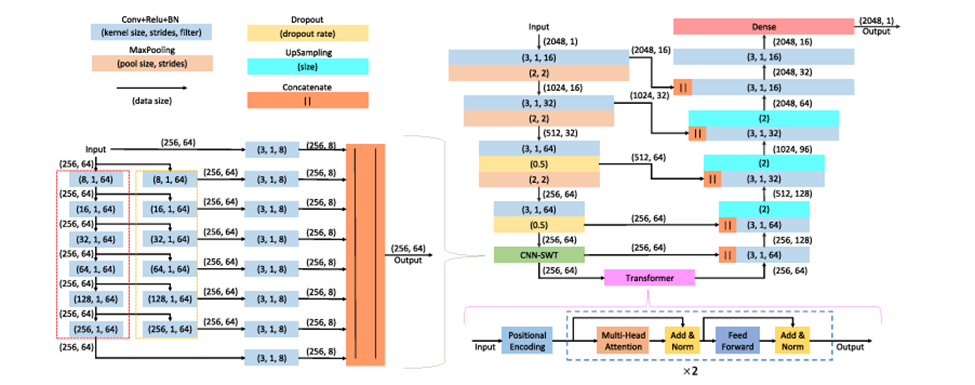

## Model 1.1: CAE (Conv,Relu,BN) (3 layer)

In [19]:
class SimpleCAE(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(SimpleCAE, self).__init__()

        # Helper function for a standard convolutional block
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv1d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm1d(out_c),
                nn.ReLU() # to avoid overriding it for correct skip connections
            )

        # input layer (2048,1)

        # --- Encoder Path ---
        # Level 1: Input (2048, 1) -> (2048, 16) -> (1024, 16)
        self.enc1 = conv_block(in_channels, 16)
        self.pool1 = nn.MaxPool1d(2)

        # Level 2: (1024, 16) -> (1024, 32) -> (512, 32)
        self.enc2 = conv_block(16, 32)
        self.pool2 = nn.MaxPool1d(2)

        # Level 3: (512, 32) -> (512, 64) -> (256, 64)
        self.enc3 = conv_block(32, 64)
        self.pool3 = nn.MaxPool1d(2)


        # # level 4: (256, 64) -> (128, 64)
        # self.enc4 = conv_block(64, 64)
        # self.pool4 = nn.MaxPool1d(2)

        # # --- Decoder Path ---
        # # Level 4': Upsample
        # # Level 4': (128, 64) -> (256, 64) -> (256, 64)
        # # self.up4 = nn.Upsample(scale_factor=2, mode='nearest')
        # self.up4 = nn.ConvTranspose1d(64,64,kernel_size=2,stride=2)
        # self.dec4 = conv_block(64, 64)

        # # --- Decoder Path ---
        # Level 3': Upsample
        # Level 3': (256, 64) -> (512, 64) -> (512, 32)
        # self.up3 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up3 = nn.ConvTranspose1d(64,64,kernel_size=2,stride=2)
        self.dec3 = conv_block(64, 32)

        # Level 2': Upsample
        # Level 2': (512, 32) -> (1024, 32) -> (1024, 16)
        # self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up2 = nn.ConvTranspose1d(32,32,kernel_size=2,stride=2)
        self.dec2 = conv_block(32, 16)

        # Level 1': Upsample
        # Level 1': (1024, 16) -> (2048, 16) -> (2048, 1)
        # self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up1 = nn.ConvTranspose1d(16,16,kernel_size=2,stride=2)

        # self.dec1 = conv_block(16, 1)   # fatal mistake
        self.dec1 = nn.Conv1d(16,1,kernel_size=3,padding=1)

        # Final Output Layer (tanh)
        self.final = nn.Tanh()

    def encoder(self,x):
      # Encoder path
      e1 = self.enc1(x)
      p1 = self.pool1(e1)

      e2 = self.enc2(p1)
      p2 = self.pool2(e2)

      e3 = self.enc3(p2)
      p3 = self.pool3(e3)

      bottleneck = p3
      return bottleneck

    def decoder(self,bottleneck):
      # Decoder path
      p3 = bottleneck
      u3 = self.up3(p3)
      d3 = self.dec3(u3)

      u2 = self.up2(d3)
      d2 = self.dec2(u2)

      u1 = self.up1(d2)
      d1 = self.dec1(u1)

      return self.final(d1)

    def forward(self, x):
        # Encoder
        bottleneck = self.encoder(x)

        # Decoder
        output = self.decoder(bottleneck)
        return output

In [ ]:
# Test with dummy data [Batch, Channels, Length]
model = SimpleCAE()
input_data = torch.randn(64, 1, 2048)
output = model(input_data)
print(f"Output shape: {output.shape}")

Output shape: torch.Size([64, 1, 2048])


In [ ]:
summary(model, input_size=(1, 1, 2048)) # (Batch, Channels, Length)

Layer (type:depth-idx)                   Output Shape              Param #
SimpleCAE                                [1, 1, 2048]              --
├─Sequential: 1-1                        [1, 16, 2048]             --
│    └─Conv1d: 2-1                       [1, 16, 2048]             64
│    └─BatchNorm1d: 2-2                  [1, 16, 2048]             32
│    └─ReLU: 2-3                         [1, 16, 2048]             --
├─MaxPool1d: 1-2                         [1, 16, 1024]             --
├─Sequential: 1-3                        [1, 32, 1024]             --
│    └─Conv1d: 2-4                       [1, 32, 1024]             1,568
│    └─BatchNorm1d: 2-5                  [1, 32, 1024]             64
│    └─ReLU: 2-6                         [1, 32, 1024]             --
├─MaxPool1d: 1-4                         [1, 32, 512]              --
├─Sequential: 1-5                        [1, 64, 512]              --
│    └─Conv1d: 2-7                       [1, 64, 512]              6,208
│    └─Ba

## Model 1.2: CAE (Conv,Relu,Conv,Relu,BN)

In [20]:
class StackCAE(nn.Module): #VGG-Based CAE
    def __init__(self, in_channels=1, out_channels=1):
        super(StackCAE, self).__init__()

        # Helper function for a VGG like convolutional block
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv1d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm1d(out_c),
                nn.ReLU(),
                nn.Conv1d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm1d(out_c),
                nn.ReLU() # to avoid overriding it for correct skip connections
            )

        # input layer (2048,1)

        # --- Encoder Path ---
        # Level 1: Input (2048, 1) -> (2048, 16) -> (1024, 16)
        self.enc1 = conv_block(in_channels, 16)
        self.pool1 = nn.MaxPool1d(2)

        # Level 2: (1024, 16) -> (1024, 32) -> (512, 32)
        self.enc2 = conv_block(16, 32)
        self.pool2 = nn.MaxPool1d(2)

        # Level 3: (512, 32) -> (512, 64) -> (256, 64)
        self.enc3 = conv_block(32, 64)
        self.pool3 = nn.MaxPool1d(2)


        # # level 4: (256, 64) -> (128, 64)
        # self.enc4 = conv_block(64, 64)
        # self.pool4 = nn.MaxPool1d(2)

        # # --- Decoder Path ---
        # # Level 4': Upsample
        # # Level 4': (128, 64) -> (256, 64) -> (256, 64)
        # # self.up4 = nn.Upsample(scale_factor=2, mode='nearest')
        # self.up4 = nn.ConvTranspose1d(64,64,kernel_size=2,stride=2)
        # self.dec4 = conv_block(64, 64)

        # # --- Decoder Path ---
        # Level 3': Upsample
        # Level 3': (256, 64) -> (512, 64) -> (512, 32)
        # self.up3 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up3 = nn.ConvTranspose1d(64,64,kernel_size=2,stride=2)
        self.dec3 = conv_block(64, 32)

        # Level 2': Upsample
        # Level 2': (512, 32) -> (1024, 32) -> (1024, 16)
        # self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up2 = nn.ConvTranspose1d(32,32,kernel_size=2,stride=2)
        self.dec2 = conv_block(32, 16)

        # Level 1': Upsample
        # Level 1': (1024, 16) -> (2048, 16) -> (2048, 1)
        # self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up1 = nn.ConvTranspose1d(16,16,kernel_size=2,stride=2)

        # self.dec1 = conv_block(16, 1)   # fatal mistake
        self.dec1 = nn.Conv1d(16,1,kernel_size=3,padding=1)

        # Final Output Layer (tanh)
        self.final = nn.Tanh()

    def encoder(self,x):
      # Encoder path
      e1 = self.enc1(x)
      p1 = self.pool1(e1)

      e2 = self.enc2(p1)
      p2 = self.pool2(e2)

      e3 = self.enc3(p2)
      p3 = self.pool3(e3)

      bottleneck = p3
      return bottleneck

    def decoder(self,bottleneck):
      # Decoder path
      p3 = bottleneck
      u3 = self.up3(p3)
      d3 = self.dec3(u3)

      u2 = self.up2(d3)
      d2 = self.dec2(u2)

      u1 = self.up1(d2)
      d1 = self.dec1(u1)

      return self.final(d1)

    def forward(self, x):
        # Encoder
        bottleneck = self.encoder(x)

        # Decoder
        output = self.decoder(bottleneck)
        return output

In [ ]:
# Test with dummy data [Batch, Channels, Length]
model = StackCAE()
input_data = torch.randn(64, 1, 2048)
output = model(input_data)
print(f"Output shape: {output.shape}")

Output shape: torch.Size([64, 1, 2048])


In [ ]:
summary(model, input_size=(1, 1, 2048)) # (Batch, Channels, Length)

Layer (type:depth-idx)                   Output Shape              Param #
StackCAE                                 [1, 1, 2048]              --
├─Sequential: 1-1                        [1, 16, 2048]             --
│    └─Conv1d: 2-1                       [1, 16, 2048]             64
│    └─BatchNorm1d: 2-2                  [1, 16, 2048]             32
│    └─ReLU: 2-3                         [1, 16, 2048]             --
│    └─Conv1d: 2-4                       [1, 16, 2048]             784
│    └─BatchNorm1d: 2-5                  [1, 16, 2048]             32
│    └─ReLU: 2-6                         [1, 16, 2048]             --
├─MaxPool1d: 1-2                         [1, 16, 1024]             --
├─Sequential: 1-3                        [1, 32, 1024]             --
│    └─Conv1d: 2-7                       [1, 32, 1024]             1,568
│    └─BatchNorm1d: 2-8                  [1, 32, 1024]             64
│    └─ReLU: 2-9                         [1, 32, 1024]             --
│    └─Conv

## Model 2: CAE (Conv, Relu, BN, Dropout)

In [21]:
class DropOutStackCAE(nn.Module): #VGG-Based CAE with Dropout at bottleneck with contolable p=0.1 (default value)
    def __init__(self, in_channels=1, out_channels=1, dropout_p=0.1):
        super(DropOutStackCAE, self).__init__()

        # Helper function for a VGG like convolutional block
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv1d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm1d(out_c),
                nn.ReLU(),
                nn.Conv1d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm1d(out_c),
                nn.ReLU() # to avoid overriding it for correct skip connections
            )

        # input layer (2048,1)

        # --- Encoder Path ---
        # Level 1: Input (2048, 1) -> (2048, 16) -> (1024, 16)
        self.enc1 = conv_block(in_channels, 16)
        self.pool1 = nn.MaxPool1d(2)

        # Level 2: (1024, 16) -> (1024, 32) -> (512, 32)
        self.enc2 = conv_block(16, 32)
        self.pool2 = nn.MaxPool1d(2)

        # Level 3: (512, 32) -> (512, 64) -> (256, 64)
        self.enc3 = conv_block(32, 64)
        self.dropout = nn.Dropout1d(p=dropout_p)
        self.pool3 = nn.MaxPool1d(2)


        # # level 4: (256, 64) -> (128, 64)
        # self.enc4 = conv_block(64, 64)
        # self.pool4 = nn.MaxPool1d(2)

        # # --- Decoder Path ---
        # # Level 4': Upsample
        # # Level 4': (128, 64) -> (256, 64) -> (256, 64)
        # # self.up4 = nn.Upsample(scale_factor=2, mode='nearest')
        # self.up4 = nn.ConvTranspose1d(64,64,kernel_size=2,stride=2)
        # self.dec4 = conv_block(64, 64)

        # # --- Decoder Path ---
        # Level 3': Upsample
        # Level 3': (256, 64) -> (512, 64) -> (512, 32)
        # self.up3 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up3 = nn.ConvTranspose1d(64,64,kernel_size=2,stride=2)
        self.dec3 = conv_block(64, 32)

        # Level 2': Upsample
        # Level 2': (512, 32) -> (1024, 32) -> (1024, 16)
        # self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up2 = nn.ConvTranspose1d(32,32,kernel_size=2,stride=2)
        self.dec2 = conv_block(32, 16)

        # Level 1': Upsample
        # Level 1': (1024, 16) -> (2048, 16) -> (2048, 1)
        # self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up1 = nn.ConvTranspose1d(16,16,kernel_size=2,stride=2)

        # self.dec1 = conv_block(16, 1)   # fatal mistake
        self.dec1 = nn.Conv1d(16,1,kernel_size=3,padding=1)

        # Final Output Layer (tanh)
        self.final = nn.Tanh()

    def encoder(self,x):
      # Encoder path
      e1 = self.enc1(x)
      p1 = self.pool1(e1)

      e2 = self.enc2(p1)
      p2 = self.pool2(e2)

      e3 = self.enc3(p2)

      # Dropout near bottleneck
      e3_dropout = self.dropout(e3)

      p3 = self.pool3(e3_dropout)

      bottleneck = p3
      return bottleneck

    def decoder(self,bottleneck):
      # Decoder path
      p3 = bottleneck
      u3 = self.up3(p3)
      d3 = self.dec3(u3)

      u2 = self.up2(d3)
      d2 = self.dec2(u2)

      u1 = self.up1(d2)
      d1 = self.dec1(u1)

      return self.final(d1)

    def forward(self, x):
        # Encoder
        bottleneck = self.encoder(x)

        # Decoder
        output = self.decoder(bottleneck)
        return output

In [ ]:
# Test with dummy data [Batch, Channels, Length]
model = DropOutStackCAE(dropout_p=0.3)
input_data = torch.randn(64, 1, 2048)
output = model(input_data)
print(f"Output shape: {output.shape}")

Output shape: torch.Size([64, 1, 2048])


In [ ]:
summary(model, input_size=(1, 1, 2048)) # (Batch, Channels, Length)

Layer (type:depth-idx)                   Output Shape              Param #
DropOutStackCAE                          [1, 1, 2048]              --
├─Sequential: 1-1                        [1, 16, 2048]             --
│    └─Conv1d: 2-1                       [1, 16, 2048]             64
│    └─BatchNorm1d: 2-2                  [1, 16, 2048]             32
│    └─ReLU: 2-3                         [1, 16, 2048]             --
│    └─Conv1d: 2-4                       [1, 16, 2048]             784
│    └─BatchNorm1d: 2-5                  [1, 16, 2048]             32
│    └─ReLU: 2-6                         [1, 16, 2048]             --
├─MaxPool1d: 1-2                         [1, 16, 1024]             --
├─Sequential: 1-3                        [1, 32, 1024]             --
│    └─Conv1d: 2-7                       [1, 32, 1024]             1,568
│    └─BatchNorm1d: 2-8                  [1, 32, 1024]             64
│    └─ReLU: 2-9                         [1, 32, 1024]             --
│    └─Conv

## Model 3: CAE (Conv, Relu, BN, Dropout, Skip Connections)

In [11]:
# ============================================================
# CONV BLOCK
# ============================================================

def conv_block(in_c, out_c):

    return nn.Sequential(

        nn.Conv1d(
            in_c,
            out_c,
            kernel_size=3,
            padding=1
        ),

        nn.BatchNorm1d(out_c),

        nn.ReLU(),

        nn.Conv1d(
            out_c,
            out_c,
            kernel_size=3,
            padding=1
        ),

        nn.BatchNorm1d(out_c),

        nn.ReLU()
    )


# ============================================================
# ENCODER
# ============================================================

class ResStackEncoder(nn.Module):

    def __init__(self,
                 in_channels=1,
                 dropout_p=0.1):

        super().__init__()

        # ----------------------------------------------------
        # Encoder
        # ----------------------------------------------------

        self.enc1 = conv_block(in_channels, 16)
        self.pool1 = nn.MaxPool1d(2)

        self.enc2 = conv_block(16, 32)
        self.pool2 = nn.MaxPool1d(2)

        self.enc3 = conv_block(32, 64)
        self.pool3 = nn.MaxPool1d(2)

        self.enc4 = conv_block(64, 64)

        self.dropout = nn.Dropout1d(
            p=dropout_p
        )

        self.enc5 = conv_block(64, 64)


    def forward(self, x):

        # ----------------------------------------------------
        # Level 1
        # ----------------------------------------------------
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        # ----------------------------------------------------
        # Level 2
        # ----------------------------------------------------
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        # ----------------------------------------------------
        # Level 3
        # ----------------------------------------------------
        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        # ----------------------------------------------------
        # Bottleneck
        # ----------------------------------------------------
        e4 = self.enc4(p3)
        e4 = self.dropout(e4)
        e5 = self.enc5(e4)
        self.bottleneck = e5

        return p1, p2, p3, e4, e5

In [12]:
# ============================================================
# DECODER
# ============================================================

class ResStackDecoder(nn.Module):

    def __init__(self,
                 out_channels=1):

        super().__init__()

        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        self.dec5 = conv_block(64, 64)
        self.dec4 = conv_block(128, 64)

        self.up4 = nn.ConvTranspose1d(
            128,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = conv_block(128, 64)
        self.up3 = nn.ConvTranspose1d(
            96,
            96,
            kernel_size=2,
            stride=2
        )

        self.dec2 = conv_block(96,48)
        self.up2 = nn.ConvTranspose1d(
            64,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = conv_block(64, 32)
        self.dec0 = conv_block(32, 16)

        self.dense = nn.Conv1d(
            16,
            1,
            kernel_size=3,
            padding=1
        )

        self.final = nn.Tanh()

    def forward(self,
                e1,
                e2,
                e3,
                e4,
                e5):

        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        d5 = self.dec5(e5)
        concat5 = torch.cat(
            [d5, e4],
            dim=1
        )

        d4 = self.dec4(concat5)
        concat4 = torch.cat(
            [d4, e3],
            dim=1
        )
        u4 = self.up4(concat4)

        d3 = self.dec3(u4)
        concat3 = torch.cat(
            [d3, e2],
            dim=1
        )
        u3 = self.up3(concat3)

        d2 = self.dec2(u3)
        concat2 = torch.cat(
            [d2, e1],
            dim=1
        )
        u2 = self.up2(concat2)

        d1 = self.dec1(u2)
        d0 = self.dec0(d1)

        dense = self.dense(d0)
        return self.final(dense)

In [13]:
# ============================================================
# FULL CAE
# ============================================================

class ResStackCAE(nn.Module):

    def __init__(self,
                 in_channels=1,
                 out_channels=1,
                 dropout_p=0.1):

        super().__init__()

        self.encoder = ResStackEncoder(
            in_channels=in_channels,
            dropout_p=dropout_p
        )

        self.decoder = ResStackDecoder(
            out_channels=out_channels
        )

    def forward(self, x):

        encoder_outputs = self.encoder(x)

        output = self.decoder(
            *encoder_outputs
        )

        return output

In [ ]:
# class ResStackCAE (nn.Module): # VGG-Based CAE with Res-Net Shortcuts/Skip connections with Dropout at bottleneck with p=0.1 default
#     def __init__(self, in_channels=1, out_channels=1, dropout_p=0.1):
#         super(ResStackCAE, self).__init__()

#         # Helper function for a VGG like convolutional block
#         def conv_block(in_c, out_c):
#             return nn.Sequential(
#                 nn.Conv1d(in_c, out_c, kernel_size=3, padding=1),
#                 nn.BatchNorm1d(out_c),
#                 nn.ReLU(),
#                 nn.Conv1d(out_c, out_c, kernel_size=3, padding=1),
#                 nn.BatchNorm1d(out_c),
#                 nn.ReLU()
#                 # ,
#                 # nn.Conv1d(out_c, out_c, kernel_size=3, padding=1),
#                 # nn.BatchNorm1d(out_c),
#                 # nn.ReLU() # to avoid overriding it for correct skip connections
#             )

#         # input layer (2048,1)

#         # --- Encoder Path ---
#         # Level 1: Input (2048, 1) -> (2048, 16) -> (1024, 16)
#         self.enc1 = conv_block(in_channels, 16)
#         self.pool1 = nn.MaxPool1d(2)

#         # Level 2: (1024, 16) -> (1024, 32) -> (512, 32)
#         self.enc2 = conv_block(16, 32)
#         self.pool2 = nn.MaxPool1d(2)

#         # Level 3: (512, 32) -> (512, 64) -> (256, 64)
#         self.enc3 = conv_block(32, 64)
#         self.dropout = nn.Dropout1d(p=dropout_p)
#         self.pool3 = nn.MaxPool1d(2)

#         # Bottleneck: (256, 64) -> (256, 64)
#         self.enc4 = conv_block(64, 64)
#         self.enc5 = conv_block(64, 64)
#         self.enc6 = conv_block(64, 64)

#         # # --- Decoder Path ---
#         self.dec5 = conv_block(64, 64) # (256,64) -> (256,64)
#         # concat step5 + :  (256,64) + (256,64) = (256,128)
#         self.dec4 = conv_block(128, 64) # (256,128) -> (256,64)
#         # concat step4 + :  (256,64) + (256,64) = (256,128)
#         self.up4 = nn.ConvTranspose1d(128,128,kernel_size=2,stride=2) # (256,128) -> (512,128)
#         self.dec3 = conv_block(128, 64) # (512,128) -> (512,64)
#         # concat step3 + :  (512,64) + (512,32) = (512,96)
#         self.up3 = nn.ConvTranspose1d(96,96,kernel_size=2,stride=2) # (512,96) -> (1024,96)
#         self.dec2 = nn.Conv1d(96,48,kernel_size=3,padding=1) # (1024,96) -> (1024,48)
#         # concat step2 + :  (1024,48) + (1024,16) = (1024,64)
#         self.up2 = nn.ConvTranspose1d(64,64,kernel_size=2,stride=2) # (1024,64) -> (2048,64)
#         self.dec1 = conv_block(64, 32) # (2048,64) -> (2048,32)
#         self.dec0 = conv_block(32, 16) # (2048,32) -> (2048,16)

#         # self.dense = conv_block(16, 1)   # fatal mistake, must not contain relu, no need for BN to avoid smoothing, only needs conv
#         self.dense = nn.Conv1d(16,1,kernel_size=3,padding=1) # (2048,16) -> (2048,1)

#         # Final Output Layer (tanh)
#         self.final = nn.Tanh()

#     def encoder(self,x):
#       # Encoder path
#       e1 = self.enc1(x)
#       p1 = self.pool1(e1)

#       e2 = self.enc2(p1)
#       p2 = self.pool2(e2)

#       e3 = self.enc3(p2)
#       p3 = self.pool3(e3)

#       e4 = self.enc4(p3)
#       # Dropout near bottleneck
#       e4_dropout = self.dropout(e4)
#       e5 = self.enc5(e4_dropout) #bottleneck

#       self.bottleneck = e5

#       return p1, p2, p3, e4, e5

#     def decoder(self,e1, e2, e3, e4, e5):
#       # Decoder path
#       d5 = self.dec5(e5) # (256,64) -> (256,64)
#       concat5 = torch.cat([d5, e4], dim=1) # (256,64) + (256,64) = (256,128)


#       d4 = self.dec4(concat5)# (256,128) -> (256,64)
#       concat4 = torch.cat([d4, e3], dim=1) # (256,64) + (256,64) = (256,128)
#       u4= self.up4(concat4)# (256,128) -> (512,128)

#       d3 = self.dec3(u4)# (512,128) -> (512,64)
#       concat3 = torch.cat([d3, e2], dim=1) # (512,64) + (512,32) = (512,96)
#       u3= self.up3(concat3)# (512,96) -> (1024,96)


#       d2 = self.dec2(u3)# (1024,96) -> (1024,48)
#       concat2 = torch.cat([d2, e1], dim=1) # (1024,48) + (1024,16) = (1024,64)
#       u2= self.up2(concat2)# (1024,64) -> (2048,64)


#       d1 = self.dec1(u2) # (2048,64) -> (2048,32)
#       d0 = self.dec0(d1) # (2048,32) -> (2048,16)

#       dense = self.dense(d0) # (2048,16) -> (2048,1)
#       return self.final(dense)

#     def forward(self, x):
#         # Encoder
#         e1, e2, e3, e4, e5 = self.encoder(x)

#         # Decoder
#         output = self.decoder(e1, e2, e3, e4, e5)
#         return output

In [14]:
# Test with dummy data [Batch, Channels, Length]
model_test = ResStackCAE(dropout_p=0.3)
input_data = torch.randn(64, 1, 2048)
output = model_test(input_data)
print(f"Output shape: {output.shape}")

Output shape: torch.Size([64, 1, 2048])


In [ ]:
summary(model_test, input_size=(1, 1, 2048)) # (Batch, Channels, Length)

Layer (type:depth-idx)                   Output Shape              Param #
ResStackCAE                              [1, 1, 2048]              --
├─ResStackEncoder: 1-1                   [1, 16, 1024]             --
│    └─Sequential: 2-1                   [1, 16, 2048]             --
│    │    └─Conv1d: 3-1                  [1, 16, 2048]             64
│    │    └─BatchNorm1d: 3-2             [1, 16, 2048]             32
│    │    └─ReLU: 3-3                    [1, 16, 2048]             --
│    │    └─Conv1d: 3-4                  [1, 16, 2048]             784
│    │    └─BatchNorm1d: 3-5             [1, 16, 2048]             32
│    │    └─ReLU: 3-6                    [1, 16, 2048]             --
│    └─MaxPool1d: 2-2                    [1, 16, 1024]             --
│    └─Sequential: 2-3                   [1, 32, 1024]             --
│    │    └─Conv1d: 3-7                  [1, 32, 1024]             1,568
│    │    └─BatchNorm1d: 3-8             [1, 32, 1024]             64
│    │    └

## Model 4: CAE (Conv, Relu, BN, Dropout, Skip Connections), smaller bottleneck

## Model 5: CAE (Conv, Relu, BN, Dropout, Skip Connections), larger bottleneck

## Model 6: CAE (Conv, Relu, BN, Dropout, Skip Connections), Dialted Convolution

In [22]:
# ============================================================
# CONV BLOCK
# ============================================================

def conv_block(in_c, out_c, dilation=1):
    return nn.Sequential(
        nn.Conv1d(
            in_c,
            out_c,
            kernel_size=3,
            padding=dilation, # Matches dilation to keep size same
            dilation=dilation
        ),
        nn.BatchNorm1d(out_c),
        nn.ReLU(),
        nn.Conv1d(
            out_c,
            out_c,
            kernel_size=3,
            padding=dilation, # Matches dilation to keep size same
            dilation=dilation
        ),
        nn.BatchNorm1d(out_c),
        nn.ReLU()
    )


# ============================================================
# ENCODER
# ============================================================

class DilatedResStackEncoder(nn.Module):

    def __init__(self,
                 in_channels=1,
                 dropout_p=0.1):

        super().__init__()

        # ----------------------------------------------------
        # Encoder
        # ----------------------------------------------------

        self.enc1 = conv_block(in_channels, 16, dilation=1)
        self.pool1 = nn.MaxPool1d(2)

        self.enc2 = conv_block(16, 32, dilation=2)
        self.pool2 = nn.MaxPool1d(2)

        self.enc3 = conv_block(32, 64, dilation=2)
        self.pool3 = nn.MaxPool1d(2)

        self.enc4 = conv_block(64, 64, dilation=4)

        self.dropout = nn.Dropout1d(
            p=dropout_p
        )

        self.enc5 = conv_block(64, 64, dilation=4)


    def forward(self, x):

        # ----------------------------------------------------
        # Level 1
        # ----------------------------------------------------
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        # ----------------------------------------------------
        # Level 2
        # ----------------------------------------------------
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        # ----------------------------------------------------
        # Level 3
        # ----------------------------------------------------
        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        # ----------------------------------------------------
        # Bottleneck
        # ----------------------------------------------------
        e4 = self.enc4(p3)
        e4 = self.dropout(e4)
        e5 = self.enc5(e4)
        self.bottleneck = e5

        return p1, p2, p3, e4, e5

In [23]:
# ============================================================
# DECODER
# ============================================================

class DilatedResStackDecoder(nn.Module):

    def __init__(self,
                 out_channels=1):

        super().__init__()

        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        self.dec5 = conv_block(64, 64)
        self.dec4 = conv_block(128, 64)

        self.up4 = nn.ConvTranspose1d(
            128,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = conv_block(128, 64)
        self.up3 = nn.ConvTranspose1d(
            96,
            96,
            kernel_size=2,
            stride=2
        )

        self.dec2 = conv_block(96,48)
        self.up2 = nn.ConvTranspose1d(
            64,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = conv_block(64, 32)
        self.dec0 = conv_block(32, 16)

        self.dense = nn.Conv1d(
            16,
            1,
            kernel_size=3,
            padding=1
        )

        self.final = nn.Tanh()

    def forward(self,
                e1,
                e2,
                e3,
                e4,
                e5):

        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        d5 = self.dec5(e5)
        concat5 = torch.cat(
            [d5, e4],
            dim=1
        )

        d4 = self.dec4(concat5)
        concat4 = torch.cat(
            [d4, e3],
            dim=1
        )
        u4 = self.up4(concat4)

        d3 = self.dec3(u4)
        concat3 = torch.cat(
            [d3, e2],
            dim=1
        )
        u3 = self.up3(concat3)

        d2 = self.dec2(u3)
        concat2 = torch.cat(
            [d2, e1],
            dim=1
        )
        u2 = self.up2(concat2)

        d1 = self.dec1(u2)
        d0 = self.dec0(d1)

        dense = self.dense(d0)
        return self.final(dense)

In [24]:
# ============================================================
# Dilated CAE
# ============================================================

class DilatedResStackCAE(nn.Module):

    def __init__(self,
                 in_channels=1,
                 out_channels=1,
                 dropout_p=0.1):

        super().__init__()

        self.encoder = DilatedResStackEncoder(
            in_channels=in_channels,
            dropout_p=dropout_p
        )

        self.decoder = DilatedResStackDecoder(
            out_channels=out_channels
        )

    def forward(self, x):

        encoder_outputs = self.encoder(x)

        output = self.decoder(
            *encoder_outputs
        )

        return output

In [ ]:
# Test with dummy data [Batch, Channels, Length]
model_test = DilatedResStackCAE()
input_data = torch.randn(64, 1, 2048)
output = model_test(input_data)
print(f"Output shape: {output.shape}")

Output shape: torch.Size([64, 1, 2048])


In [ ]:
summary(model_test, input_size=(1, 1, 2048)) # (Batch, Channels, Length)

Layer (type:depth-idx)                   Output Shape              Param #
DilatedResStackCAE                       [1, 1, 2048]              --
├─DilatedResStackEncoder: 1-1            [1, 16, 1024]             --
│    └─Sequential: 2-1                   [1, 16, 2048]             --
│    │    └─Conv1d: 3-1                  [1, 16, 2048]             64
│    │    └─BatchNorm1d: 3-2             [1, 16, 2048]             32
│    │    └─ReLU: 3-3                    [1, 16, 2048]             --
│    │    └─Conv1d: 3-4                  [1, 16, 2048]             784
│    │    └─BatchNorm1d: 3-5             [1, 16, 2048]             32
│    │    └─ReLU: 3-6                    [1, 16, 2048]             --
│    └─MaxPool1d: 2-2                    [1, 16, 1024]             --
│    └─Sequential: 2-3                   [1, 32, 1024]             --
│    │    └─Conv1d: 3-7                  [1, 32, 1024]             1,568
│    │    └─BatchNorm1d: 3-8             [1, 32, 1024]             64
│    │    └

# Training Loop

In [15]:
# =========================
# Denoising Loss Function
# =========================

class PeakWeightedLoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, clean, denoised):

        # ----------------------------------------------------
        # Peak coefficient:
        # Cp = 1 + abs(Xc - median(Xc))
        # ----------------------------------------------------

        median = torch.median(clean, dim=2, keepdim=True)[0] ##test
        Cp = 1 + torch.abs(clean - median)

        # ----------------------------------------------------
        # Improved weighted MSE
        # ----------------------------------------------------

        loss = ((clean - denoised) ** 2) * Cp
        return torch.mean(loss)

In [16]:
def save_checkpoint(model, filepath):
    # print("Saving checkpoint .........")
    # checkpoint = {"state_dict": model.state_dict(),"optimizer": optimizer.state_dict()}
    torch.save(model.state_dict(),filepath)

In [17]:
def train_model(model, name, train_loader, valid_loader, criterion =None,epochs=EPOCHS, lr=LR):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # ==========================================
    # Default Criterion
    # ==========================================
    if criterion is None:
        criterion = PeakWeightedLoss()

    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=7, factor=0.5) #if drop_out, patience must be > 7

    history = {'train': [], 'valid': []}

    # =========================================
    # Model Path
    # =========================================
    checkpoint_directory = os.path.join(CHECKPOINT_DIR,str(name))
    os.makedirs(checkpoint_directory, exist_ok=True) # Creates the directory if it doesn't exist
    checkpoint_path = os.path.join(checkpoint_directory,'best_model.pth')

    # model.train()
    best_valid = float('inf')
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        snr_improvement =0.0
        for noisy, clean in train_loader:

            noisy = noisy.to(device)
            clean = clean.to(device)

            # ---------------------------------------------
            # Forward
            # ---------------------------------------------

            denoised = model(noisy)
            loss = criterion(clean, denoised)

            # ---------------------------------------------
            # Backprop
            # ---------------------------------------------

            optimizer.zero_grad()

            loss.backward()

            # Gradient clipping
            # torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
            optimizer.step()

            # ---------------------------------------------
            # Accumulate
            # ---------------------------------------------

            train_loss += (loss.item() * noisy.size(0))

        # =================================================
        # VALIDATION
        # =================================================

        model.eval()
        valid_loss = 0.0

        with torch.no_grad():
            for noisy, clean in valid_loader:
                noisy = noisy.to(device)
                clean = clean.to(device)
                denoised = model(noisy)
                loss = criterion(denoised,clean)
                valid_loss += (loss.item() * noisy.size(0))
                # ------------------------------
                # Noisy SNR
                # ------------------------------

                snr_noisy = compute_snr(clean,noisy)

                # ------------------------------
                # Denoised SNR
                # ------------------------------

                snr_denoised = compute_snr(clean,denoised)

                # ------------------------------
                # Improvement
                # ------------------------------

                snr_improvement += (snr_denoised - snr_noisy)

        # =================================================
        # Epoch Metrics
        # =================================================

        epoch_train = train_loss / len(train_loader.dataset)
        epoch_valid = valid_loss / len(valid_loader.dataset)
        epoch_snr_improvement = snr_improvement/ len(valid_loader.dataset)

        # =================================================
        # Early Stopping
        # =================================================
        # add later

        # saving the best model based on the validation loss
        if epoch_valid < best_valid:
          best_valid = epoch_valid

          save_checkpoint(model, checkpoint_path)

          # print("Best model saved.")

        # Update the scheduler step using the validation loss
        scheduler.step(epoch_valid)
        current_lr = optimizer.param_groups[0]['lr']

        history['train'].append(epoch_train)
        history['valid'].append(epoch_valid)

        # print(f"Epoch {epoch+1}/{epochs} - Train: {epoch_train:.6f} | Val: {epoch_valid:.6f}")
        print(f"Epoch {epoch+1}/{epochs} "f"- Train: {epoch_train:.6f} "f"- Val: {epoch_valid:.6f} "f"- SNR_Improvement: {epoch_snr_improvement:.6f} "f"- LR: {current_lr:.2e}")

    return history


In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
simple_CAE_model = SimpleCAE().to(device)
stack_CAE_model = StackCAE().to(device)
dropoutstack_CAE_model = DropOutStackCAE(dropout_p=0.2).to(device)
resstack_CAE_model = ResStackCAE(dropout_p=0.2).to(device)
dilatedresstack_CAE_model = DilatedResStackCAE(dropout_p=0.2).to(device)
models_to_test = {
    "SimpleCAE": simple_CAE_model,
    "StackCAE" : stack_CAE_model,
    "DropOutStackCAE": dropoutstack_CAE_model,
    "ResStackCAE": resstack_CAE_model,
    "DilatedResStackCAE":dilatedresstack_CAE_model
}
criterion = PeakWeightedLoss()
history = { "SimpleCAE":[], "StackCAE":[], "DropOutStackCAE":[], "ResStackCAE": [], "DilatedResStackCAE" : []}

In [ ]:
# training SimpleCAE model
name = "SimpleCAE"
print(f"Training {name} model...")
history[name] = train_model(models_to_test[name], name, train_loader, valid_loader,criterion)

Training SimpleCAE model...
Epoch 1/5 - Train: 0.007159 | Val: 0.005150
Epoch 2/5 - Train: 0.004630 | Val: 0.004754
Epoch 3/5 - Train: 0.004385 | Val: 0.004598
Epoch 4/5 - Train: 0.004259 | Val: 0.004446
Epoch 5/5 - Train: 0.004180 | Val: 0.004360


In [ ]:
# Training SimpleCAE model...
# Epoch 1/5 - Train: 0.007159 | Val: 0.005150
# Epoch 2/5 - Train: 0.004630 | Val: 0.004754
# Epoch 3/5 - Train: 0.004385 | Val: 0.004598
# Epoch 4/5 - Train: 0.004259 | Val: 0.004446
# Epoch 5/5 - Train: 0.004180 | Val: 0.004360

In [ ]:
# training StackCAE model
name = "StackCAE"
print(f"Training {name} model...")
history[name] = train_model(models_to_test[name], name, train_loader, valid_loader,criterion)

Training StackCAE model...
Epoch 1/5 - Train: 0.008866 | Val: 0.004615
Epoch 2/5 - Train: 0.004146 | Val: 0.004152
Epoch 3/5 - Train: 0.003856 | Val: 0.003940
Epoch 4/5 - Train: 0.003718 | Val: 0.003827
Epoch 5/5 - Train: 0.003618 | Val: 0.003839


In [ ]:
# Training StackCAE model...
# Epoch 1/5 - Train: 0.008866 | Val: 0.004615
# Epoch 2/5 - Train: 0.004146 | Val: 0.004152
# Epoch 3/5 - Train: 0.003856 | Val: 0.003940
# Epoch 4/5 - Train: 0.003718 | Val: 0.003827
# Epoch 5/5 - Train: 0.003618 | Val: 0.003839

In [ ]:
# training DropOutStackCAE model p=0.3
name = "DropOutStackCAE"
print(f"Training {name} model...")
history[name] = train_model(models_to_test[name], name, train_loader, valid_loader,criterion)


Training DropOutStackCAE model...
Saving checkpoint .........
Best model saved.
Epoch 1/5 - Train: 0.009804 - Val: 0.005385 - SNR_Improvement: 0.074829 - LR: 1.00e-04
Saving checkpoint .........
Best model saved.
Epoch 2/5 - Train: 0.005264 - Val: 0.004682 - SNR_Improvement: 0.087095 - LR: 1.00e-04
Saving checkpoint .........
Best model saved.
Epoch 3/5 - Train: 0.004770 - Val: 0.004429 - SNR_Improvement: 0.091871 - LR: 1.00e-04
Saving checkpoint .........
Best model saved.
Epoch 4/5 - Train: 0.004552 - Val: 0.004344 - SNR_Improvement: 0.093338 - LR: 1.00e-04
Saving checkpoint .........
Best model saved.
Epoch 5/5 - Train: 0.004405 - Val: 0.004250 - SNR_Improvement: 0.094586 - LR: 1.00e-04


In [ ]:
# Training DropOutStackCAE model...
# Epoch 1/5 - Train: 0.007823 | Val: 0.004552
# Epoch 2/5 - Train: 0.004351 | Val: 0.004083
# Epoch 3/5 - Train: 0.004031 | Val: 0.003892
# Epoch 4/5 - Train: 0.003867 | Val: 0.003859
# Epoch 5/5 - Train: 0.003752 | Val: 0.003676

In [28]:
# training ResStackCAE model p=0.3
name = "ResStackCAE"
print(f"Training {name} model...")
history[name] = train_model(models_to_test[name], name, train_loader, valid_loader,criterion)


Training ResStackCAE model...
Epoch 1/5 - Train: 0.003803 - Val: 0.003199 - SNR_Improvement: 0.112916 - LR: 1.00e-04
Epoch 2/5 - Train: 0.003406 - Val: 0.002823 - SNR_Improvement: 0.122489 - LR: 1.00e-04
Epoch 3/5 - Train: 0.003265 - Val: 0.002957 - SNR_Improvement: 0.119822 - LR: 1.00e-04
Epoch 4/5 - Train: 0.003185 - Val: 0.002802 - SNR_Improvement: 0.123130 - LR: 1.00e-04
Epoch 5/5 - Train: 0.003119 - Val: 0.002682 - SNR_Improvement: 0.125744 - LR: 1.00e-04


In [ ]:
# training SimpleCAE model
name = "DilatedResStackCAE"
print(f"Training {name} model...")
history[name] = train_model(models_to_test[name], name, train_loader, valid_loader,criterion)

Training DilatedResStackCAE model...
Epoch 1/5 - Train: 0.009798 - Val: 0.003783 - SNR_Improvement: 0.099654 - LR: 1.00e-04
Epoch 2/5 - Train: 0.003652 - Val: 0.002957 - SNR_Improvement: 0.116133 - LR: 1.00e-04
Epoch 3/5 - Train: 0.003324 - Val: 0.002747 - SNR_Improvement: 0.120852 - LR: 1.00e-04
Epoch 4/5 - Train: 0.003169 - Val: 0.002654 - SNR_Improvement: 0.124355 - LR: 1.00e-04
Epoch 5/5 - Train: 0.003073 - Val: 0.002644 - SNR_Improvement: 0.123844 - LR: 1.00e-04


In [ ]:
# for name, values in models_to_test.items():
#   print(name)

SimpleCAE
StackCAE
StackDropOutCAE


In [ ]:
# del models_to_test ['DropOutStackCAE']

### saving model weights

In [ ]:
# SAVE_MODEL_DIR = "/content/drive/MyDrive/CSE672_Neural_Nets/Project/Saved_Models"
# LOAD_MODEL_DIR = "/content/drive/MyDrive/CSE672_Neural_Nets/Project/Saved_Models"

In [29]:
def save_model_weights(name, model):

  os.makedirs(SAVE_MODEL_DIR, exist_ok=True) # Creates the directory if it doesn't exist

  # Set the file path
  model_path = str(name)+".pth"
  model_save_path = os.path.join(SAVE_MODEL_DIR, model_path)
  # Save only the weights (state_dict)
  torch.save(model.state_dict(), model_save_path)
  print(f"model: {name} weights are saved successfully to: {model_save_path}")

In [ ]:
save_model_weights('SimpleCAE', models_to_test['SimpleCAE'])
save_model_weights('StackCAE', models_to_test['StackCAE'])

model: SimpleCAE weights are saved successfully to: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Models/Paper/SimpleCAE.pth
model: StackCAE weights are saved successfully to: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Models/Paper/StackCAE.pth


In [ ]:
save_model_weights('DropOutStackCAE(p=0.2)', models_to_test['DropOutStackCAE'])

model: DropOutStackCAE(p=0.2).pth weights are saved successfully to: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Models/Paper/DropOutStackCAE(p=0.2).pth.pth


In [ ]:
# save_model_weights('ResStackCAE(p=0.2)', models_to_test['ResStackCAE'])

model: ResStackCAE(p=0.2) weights are saved successfully to: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Models/Paper/ResStackCAE(p=0.2).pth


In [30]:
save_model_weights('ResStackCAE', models_to_test['ResStackCAE'])

model: ResStackCAE weights are saved successfully to: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Saved_Models/ResStackCAE.pth


In [ ]:
save_model_weights('DilatedResStackCAE', models_to_test['DilatedResStackCAE'])

model: DilatedResStackCAE weights are saved successfully to: /content/drive/MyDrive/CSE672_Neural_Nets/Project/Saved_Models/DilatedResStackCAE.pth


### loading model weights

In [ ]:
def load_model_weights(name):
  # Define the device
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  # Set the file path
  model_path = str(name)+".pth"
  model_load_path = os.path.join(LOAD_MODEL_DIR, model_path)

  # Load the saved dictionary and map it to your target device
  state_dict = torch.load(model_load_path, map_location=device)

  return state_dict

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate a fresh, untrained instance of your model structure
model_name ="DilatedResStackCAE"
loaded_model = DilatedResStackCAE(dropout_p=0.2)
state_dict = load_model_weights(model_name)

# Load the weights into the model structure and push to device
loaded_model.load_state_dict(state_dict)
loaded_model.to(device)

# 5. CRITICAL STEP: Put the model in evaluation mode
# This turns off BatchNorm updating so the model acts as a fixed predictor
loaded_model.eval()

print("Model successfully loaded and ready for inference!")


Model successfully loaded and ready for inference!


## training, validation loss with epochs

In [ ]:
def train_valid_loss_plt(history):
  plt.figure(figsize=(12, 6))

  for name, val_list in history.items():
      plt.plot(val_list, label=f'{name} Loss')

  plt.title('Model Comparison: Training VS Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Peak Weighted MSE Loss')
  plt.yscale('log') # Useful if losses vary greatly
  plt.legend()
  plt.grid(True)
  plt.show()


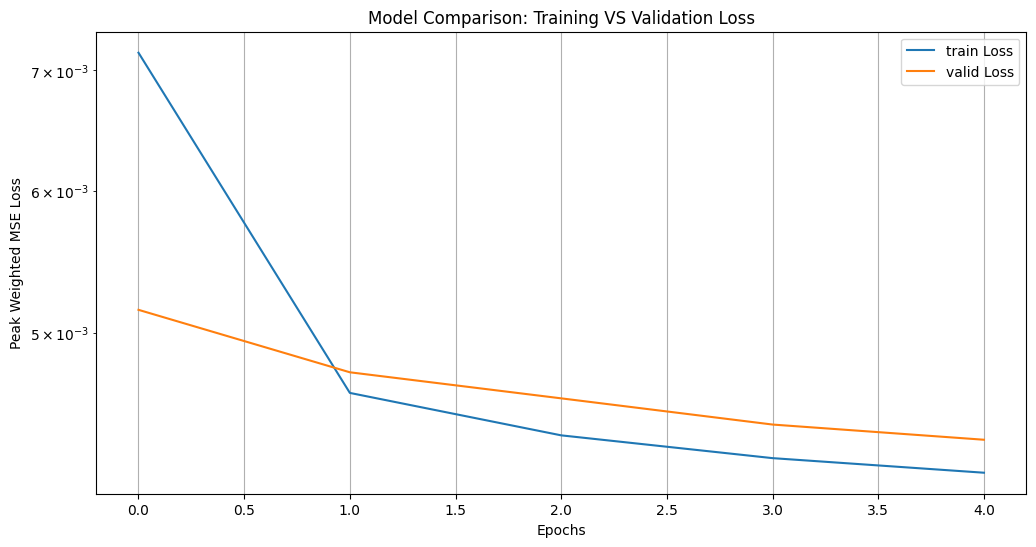

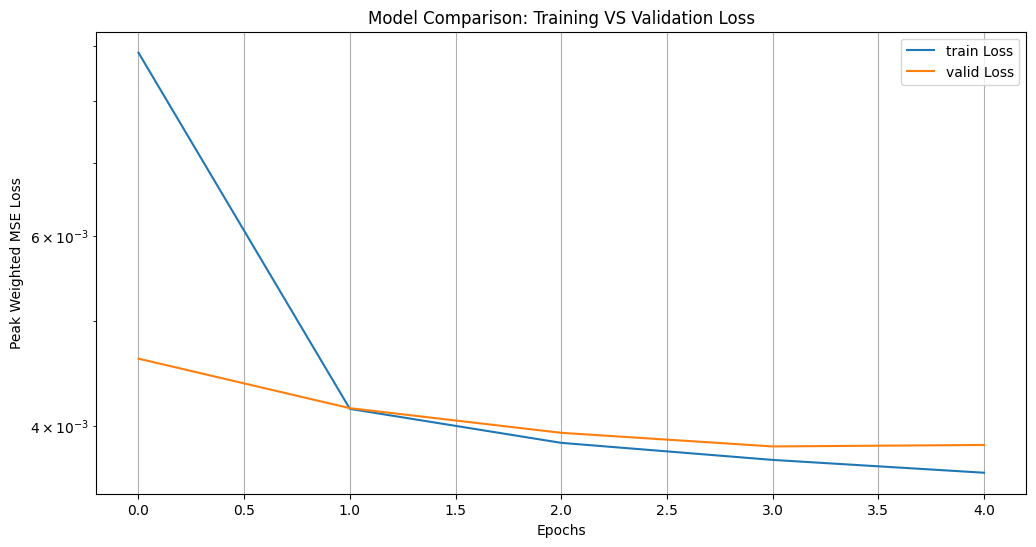

In [ ]:
train_valid_loss_plt(history['SimpleCAE'])
train_valid_loss_plt(history['StackCAE'])

# Evaluation

In [31]:
def compute_snr(clean, denoised):

    # ==========================================
    # Convert tensors to numpy
    # ==========================================

    if isinstance(clean, torch.Tensor):
        clean = clean.detach().cpu().numpy()

    if isinstance(denoised, torch.Tensor):
        denoised = (denoised.detach().cpu().numpy())

    # ==========================================
    # Noise
    # ==========================================

    noise = clean - denoised
    # print(f"clean: {clean}, denoised: {denoised}, noise:{noise}")


    # ==========================================
    # Power
    # ==========================================

    signal_power = np.mean(clean ** 2)
    noise_power = np.mean(noise ** 2)

    # print(f"signal power: {signal_power}, denoised power :{np.mean(denoised ** 2)}, noise power: {noise_power}")

    # ==========================================
    # Prevent division by zero
    # ==========================================

    if noise_power < 1e-12:
        return float('inf')

    # ==========================================
    # SNR
    # ==========================================

    snr = 10 * np.log10(signal_power / noise_power)
    return snr

In [36]:
# # =========================================================
# # SNR
# # =========================================================

# def compute_snr(clean, signal):

#     if hasattr(clean, 'detach'):
#         clean = clean.detach().cpu().numpy()

#     if hasattr(signal, 'detach'):
#         signal = signal.detach().cpu().numpy()

#     noise = clean - signal

#     signal_power = np.sum(clean ** 2)
#     noise_power = np.sum(noise ** 2)

#     if noise_power == 0:
#         return np.inf

#     return 10 * np.log10(signal_power / noise_power)


# =========================================================
# PRD
# =========================================================

def compute_prd(clean, signal):

    if hasattr(clean, 'detach'):
        clean = clean.detach().cpu().numpy()

    if hasattr(signal, 'detach'):
        signal = signal.detach().cpu().numpy()

    numerator = np.sum((clean - signal) ** 2)
    denominator = np.sum(clean ** 2)

    prd = np.sqrt(numerator / denominator) * 100

    return prd


# =========================================================
# MSE
# =========================================================

def compute_mse(clean, signal):

    if hasattr(clean, 'detach'):
        clean = clean.detach().cpu().numpy()

    if hasattr(signal, 'detach'):
        signal = signal.detach().cpu().numpy()

    return mean_squared_error(
        clean.flatten(),
        signal.flatten()
    )

In [37]:
def evaluate_model(model,test_loader, criterion=None):

    # ==========================================
    # Device
    # ==========================================

    device = torch.device("cuda" if torch.cuda.is_available()else "cpu")
    model = model.to(device)

    # ==========================================
    # Default Criterion
    # ==========================================

    if criterion is None:
        criterion = PeakWeightedLoss()

    model.eval()

    # ==========================================
    # Metrics
    # ==========================================

    total_loss = 0.0
    snr_noisy_list = []
    snr_denoised_list = []
    snr_improvement_list = []

    # ==========================================
    # Evaluation
    # ==========================================

    with torch.no_grad():

        for noisy, clean in test_loader:

            noisy = noisy.to(device)
            clean = clean.to(device)

            # ----------------------------------
            # Forward
            # ----------------------------------

            denoised = model(noisy)

            # ----------------------------------
            # Loss
            # ----------------------------------

            loss = criterion(denoised,clean)

            total_loss += (loss.item() * noisy.size(0))

            # ----------------------------------
            # Batch SNR
            # ----------------------------------

            for i in range(noisy.size(0)):

                clean_i = clean[i]
                noisy_i = noisy[i]
                denoised_i = denoised[i]

                # ------------------------------
                # Noisy SNR
                # ------------------------------

                snr_noisy = compute_snr(clean_i,noisy_i)

                # ------------------------------
                # Denoised SNR
                # ------------------------------

                snr_denoised = compute_snr(clean_i,denoised_i)

                # ------------------------------
                # Improvement
                # ------------------------------

                improvement = (snr_denoised - snr_noisy)
                snr_noisy_list.append(snr_noisy)
                snr_denoised_list.append(snr_denoised)
                snr_improvement_list.append(improvement)

    # ==========================================
    # Final Metrics
    # ==========================================

    avg_loss = (total_loss / len(test_loader.dataset))
    avg_snr_noisy = np.mean(snr_noisy_list)
    avg_snr_denoised = np.mean(snr_denoised_list)
    avg_improvement = np.mean(snr_improvement_list)

    # ==========================================
    # Print Results
    # ==========================================

    print("=" * 60)
    print(f"Test Loss           : {avg_loss:.6f}")
    print(f"Average Noisy SNR   : {avg_snr_noisy:.2f} dB")
    print(f"Average Denoised SNR: {avg_snr_denoised:.2f} dB")
    print(f"SNR Improvement     : {avg_improvement:.2f} dB")
    print("=" * 60)

    return {
        "loss": avg_loss,
        "snr_noisy": avg_snr_noisy,
        "snr_denoised": avg_snr_denoised,
        "snr_improvement": avg_improvement
    }

In [ ]:
name ='SimpleCAE'
print(f"Testing {name} model...")
models_to_test[name].eval()
results = evaluate_model(models_to_test[name],test_loader,criterion)

Testing SimpleCAE model...
Test Loss           : 0.003877
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 7.20 dB
SNR Improvement     : 5.13 dB


In [ ]:
name ='StackCAE'
print(f"Testing {name} model...")
models_to_test[name].eval()
results = evaluate_model(models_to_test[name],test_loader,criterion)

Testing StackCAE model...
Test Loss           : 0.003762
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 7.68 dB
SNR Improvement     : 5.61 dB


In [ ]:
name = "DropOutStackCAE"
print(f"Testing {name} model...")
models_to_test[name].eval()
results = evaluate_model(models_to_test[name],test_loader,criterion)

Testing DropOutStackCAE model...
Test Loss           : 0.004038
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 7.62 dB
SNR Improvement     : 5.56 dB


In [ ]:
# Testing DropOutStackCAE model...
# ============================================================
# Test Loss           : 0.003690
# Average Noisy SNR   : 2.07 dB
# Average Denoised SNR: 7.79 dB
# SNR Improvement     : 5.73 dB
# ============================================================

In [38]:
name = "ResStackCAE"
print(f"Testing {name} model...")
models_to_test[name].eval()
results = evaluate_model(models_to_test[name],test_loader,criterion)

Testing ResStackCAE model...
Test Loss           : 0.003432
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 8.99 dB
SNR Improvement     : 6.92 dB


In [ ]:
# Testing ResStackCAE model...
# ============================================================
# Test Loss           : 0.003503
# Average Noisy SNR   : 2.07 dB
# Average Denoised SNR: 8.73 dB
# SNR Improvement     : 6.66 dB
# ============================================================

In [ ]:
name = "DilatedResStackCAE"
print(f"Testing {name} model...")
models_to_test[name].eval()
results = evaluate_model(models_to_test[name],test_loader,criterion)

Testing DilatedResStackCAE model...
Test Loss           : 0.003473
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 8.78 dB
SNR Improvement     : 6.72 dB


# Visualization

In [39]:
# ============================================================
# VISUALIZE ECG SIGNALS
# ============================================================

def visualize_ecg_signals(noisy,
                          denoised,
                          clean,
                          fs=360,
                          start_sec=None,
                          end_sec=None,
                          title="ECG Denoising"):

    """
    Plot noisy, denoised, and clean ECG signals.

    Parameters
    ----------
    noisy : np.ndarray or torch.Tensor
    denoised : np.ndarray or torch.Tensor
    clean : np.ndarray or torch.Tensor

    fs : int
        Sampling frequency (360 Hz for MIT-BIH)

    start_sec : float
        Start time in seconds

    end_sec : float
        End time in seconds

    title : str
        Figure title
    """

    # ========================================================
    # Convert tensors to numpy
    # ========================================================

    if hasattr(noisy, "detach"):
        noisy = noisy.detach().cpu().numpy()

    if hasattr(denoised, "detach"):
        denoised = denoised.detach().cpu().numpy()

    if hasattr(clean, "detach"):
        clean = clean.detach().cpu().numpy()

    # ========================================================
    # Remove extra dimensions
    # ========================================================

    noisy = np.squeeze(noisy)

    denoised = np.squeeze(denoised)

    clean = np.squeeze(clean)

    # ========================================================
    # Time Axis
    # ========================================================

    n_samples = len(clean)

    time = np.arange(n_samples) / fs

    # ========================================================
    # Optional Cropping
    # ========================================================

    if start_sec is not None and end_sec is not None:

        start_idx = int(start_sec * fs)

        end_idx = int(end_sec * fs)

        noisy = noisy[start_idx:end_idx]

        denoised = denoised[start_idx:end_idx]

        clean = clean[start_idx:end_idx]

        time = time[start_idx:end_idx]

    # ========================================================
    # Plot
    # ========================================================

    plt.figure(figsize=(18,6))

    plt.plot(
        time,
        noisy,
        label="Noisy ECG",
        alpha=0.7
    )

    plt.plot(
        time,
        denoised,
        label="Denoised ECG",
        linewidth=2
    )

    plt.plot(
        time,
        clean,
        label="Clean ECG",
        linewidth=1.5
    )

    plt.xlabel("Time (seconds)")

    plt.ylabel("Amplitude")

    plt.title(title)

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()

### plotting different segments

In [40]:
def plot_multiple_segments(name,indice):
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  for idx in indices:

    # get individual segments and ensure they are squeezed to 1D arrays/tensors
    # Using .squeeze() drops the batch/channel dimensions so the math maps perfectly
    noisy_segment = x_test[idx].squeeze().to(device)
    clean_segment = y_test[idx].squeeze().to(device)

    models_to_test[name].eval()
    with torch.no_grad():
        # Unsqueeze to add batch dimension for the model inference pass (1, 1, 2048)
        noisy_input = x_test[idx:idx+1].to(device)
        denoised_output = models_to_test[name](noisy_input)

        # Squeeze the model output back to a 1D format for SNR math
        denoised_segment = denoised_output.squeeze()

    # Run the metrics using distinct, explicit functions
    snr_noisy = compute_snr(clean_segment, noisy_segment)
    snr_denoised = compute_snr(clean_segment, denoised_segment)

    print(f"for segment {idx}:")
    print(f"  - snr_noisy= {snr_noisy:.4f} dB")
    print(f"  - snr_denoised= {snr_denoised:.4f} dB")
    print(f"  - snr_improvement= {snr_denoised - snr_noisy:.4f} dB")

    visualize_ecg_signals(
      noisy=x_test[idx:idx+1],
      denoised=denoised_segment,
      clean=clean_segment,
      fs=360
  )


In [103]:
# Finding segment idx for each SNR value yo visualize later
snr_unique_values = extract_unique_snr_values(train_metadata)
indices = find_segments_idx(test_metadata,snr_unique_values)

Unique target_snr_db values: [0, 1.25, 5]
Found segment having snr =0 db, at index = 11
{'record': '219', 'segment_idx': 11, 'start': 11264, 'end': 13312, 'target_snr_db': 0, 'actual_snr_db': np.float64(0.0), 'noise_type': 'MA'}
Found segment having snr =1.25 db, at index = 2
{'record': '219', 'segment_idx': 2, 'start': 2048, 'end': 4096, 'target_snr_db': 1.25, 'actual_snr_db': np.float64(1.2499999999999976), 'noise_type': 'BW'}
Found segment having snr =5 db, at index = 0
{'record': '219', 'segment_idx': 0, 'start': 0, 'end': 2048, 'target_snr_db': 5, 'actual_snr_db': np.float64(5.000000000000001), 'noise_type': 'MA'}


for segment 11:
  - snr_noisy= -0.0000 dB
  - snr_denoised= 8.4332 dB
  - snr_improvement= 8.4332 dB


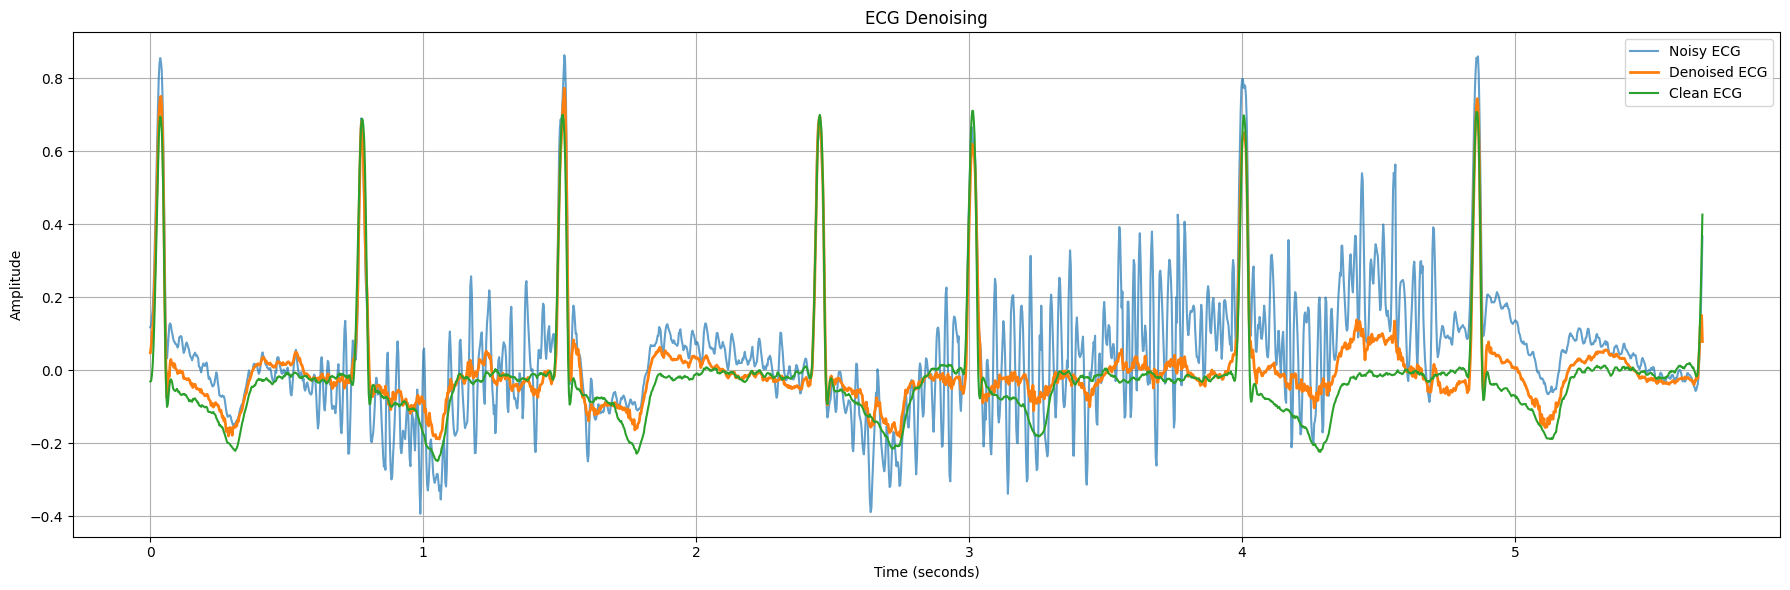

for segment 2:
  - snr_noisy= 1.2500 dB
  - snr_denoised= 14.0459 dB
  - snr_improvement= 12.7959 dB


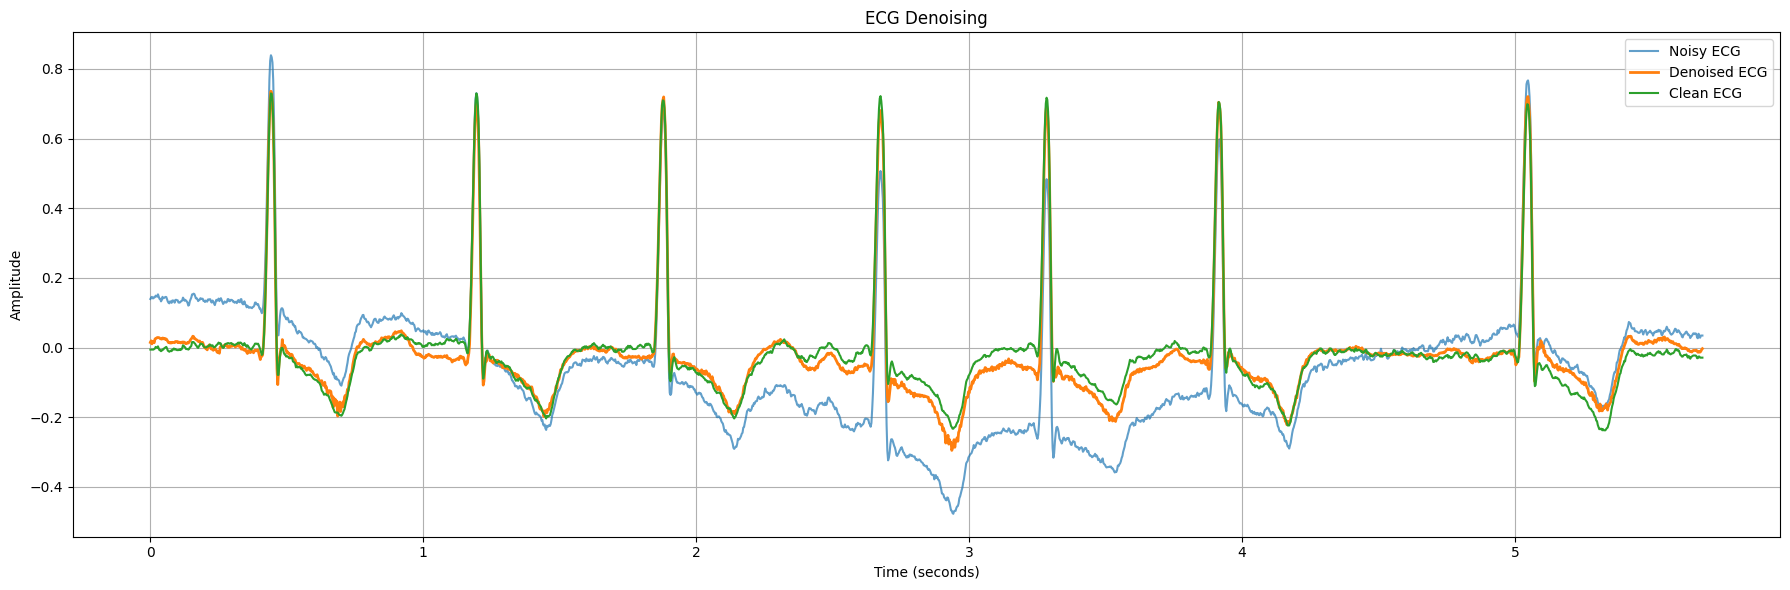

for segment 0:
  - snr_noisy= 5.0000 dB
  - snr_denoised= 14.0596 dB
  - snr_improvement= 9.0596 dB


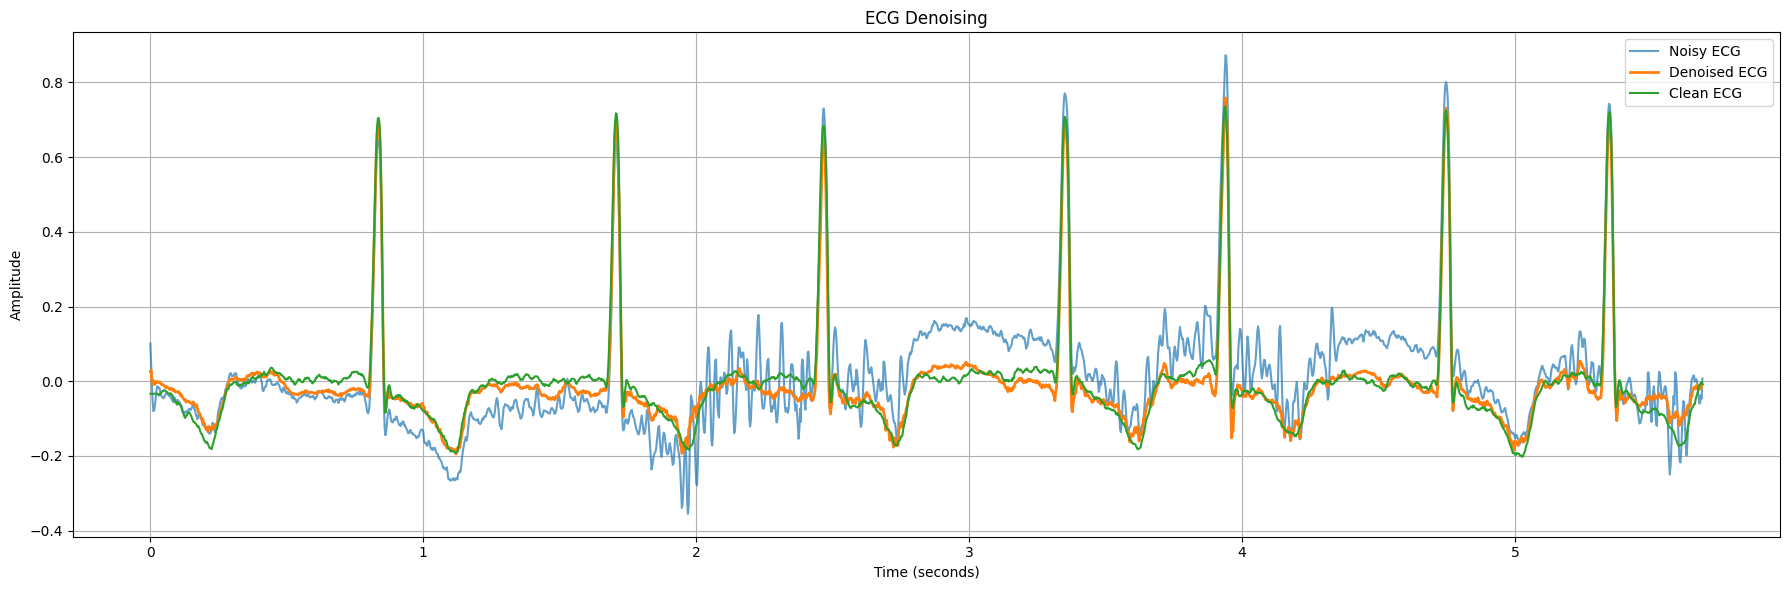

In [104]:
name ='ResStackCAE'
plot_multiple_segments(name,indices)


for segment 11:
  - snr_noisy= -0.0000 dB
  - snr_denoised= 6.0732 dB
  - snr_improvement= 6.0732 dB


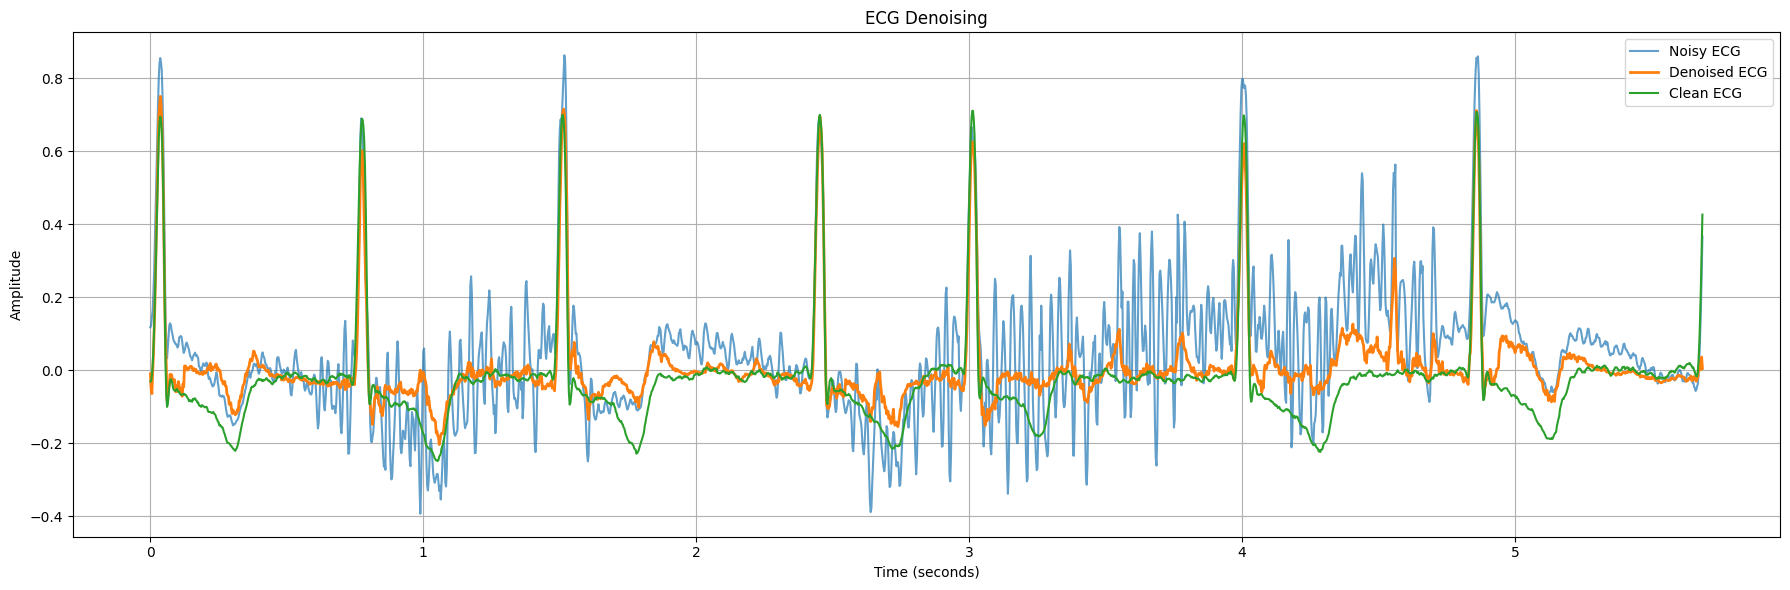

for segment 2:
  - snr_noisy= 1.2500 dB
  - snr_denoised= 9.7276 dB
  - snr_improvement= 8.4776 dB


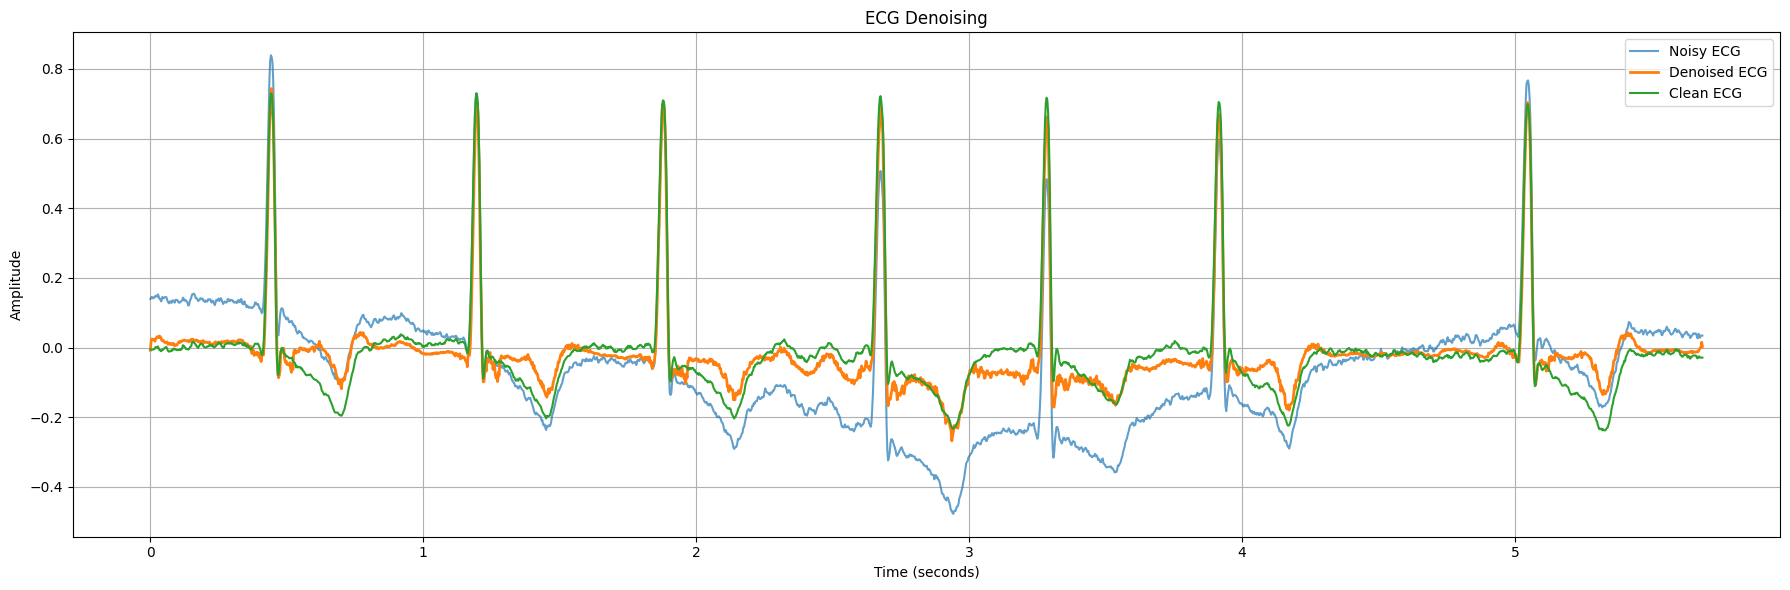

for segment 0:
  - snr_noisy= 5.0000 dB
  - snr_denoised= 9.5312 dB
  - snr_improvement= 4.5312 dB


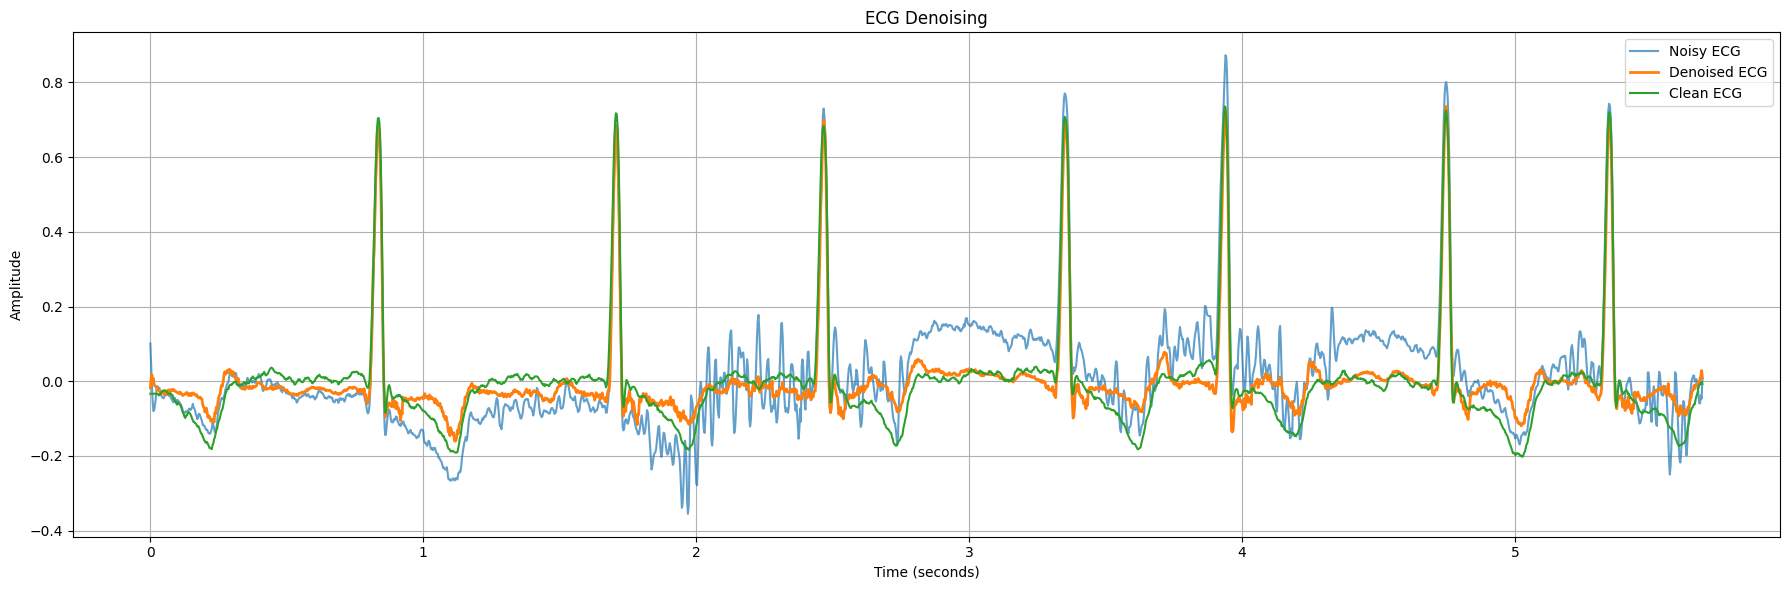

In [ ]:
name ='StackMoreDropOutCAE'
plot_multiple_segments(name,indices)

In [41]:
def plot_segment(data,
                 metadata,
                 segment_index,
                 title="ECG Segment"):

    """
    Plot a specific ECG segment and print its metadata.

    Parameters
    ----------
    data : np.ndarray
        Shape: (N, 1, 2048)

    metadata : list
        Metadata list corresponding to segments

    segment_index : int
        Index of segment to visualize

    title : str
        Plot title
    """

    # Get segment
    segment = data[segment_index, 0]

    # Get metadata
    meta = metadata[segment_index]

    # =========================
    # Print Metadata
    # =========================

    print("=" * 50)

    print(f"Segment Index : {segment_index}")

    print(f"Patient Record: {meta['record']}")

    print(f"Segment ID    : {meta['segment_idx']}")

    print(f"Start Sample  : {meta['start']}")

    print(f"End Sample    : {meta['end']}")

    if 'noise_type' in meta:
        print(f"Noise Type    : {meta['noise_type']}")

    if 'target_snr_db' in meta:
        print(f"Target SNR    : {meta['target_snr_db']} dB")

    if 'actual_snr_db' in meta:
        print(f"Actual SNR    : {meta['actual_snr_db']:.2f} dB")

    print("=" * 50)

    # =========================
    # Plot
    # =========================

    plt.figure(figsize=(15,4))

    plt.plot(segment)

    plt.title(title)

    plt.xlabel("Samples")

    plt.ylabel("Amplitude")

    plt.grid(True)

    plt.show()


def compare_segment(clean_data,
                    noisy_data,
                    metadata,
                    segment_index):

    clean = clean_data[segment_index, 0]

    noisy = noisy_data[segment_index, 0]

    meta = metadata[segment_index]

    print("=" * 50)

    print(f"Patient Record: {meta['record']}")

    print(f"Noise Type   : {meta['noise_type']}")

    print(f"Target SNR   : {meta['target_snr_db']} dB")

    print(f"Actual SNR   : {meta['actual_snr_db']:.2f} dB")

    print("=" * 50)

    plt.figure(figsize=(18,5))

    plt.plot(clean,
             label='Clean',
             linewidth=2)

    plt.plot(noisy,
             label='Noisy',
             alpha=0.7)

    plt.title(
        f"Segment {segment_index}"
    )

    plt.xlabel("Samples")

    plt.ylabel("Amplitude")

    plt.legend()

    plt.grid(True)

    plt.show()

Patient Record: 100
Noise Type   : MA
Target SNR   : 1.25 dB
Actual SNR   : 1.25 dB


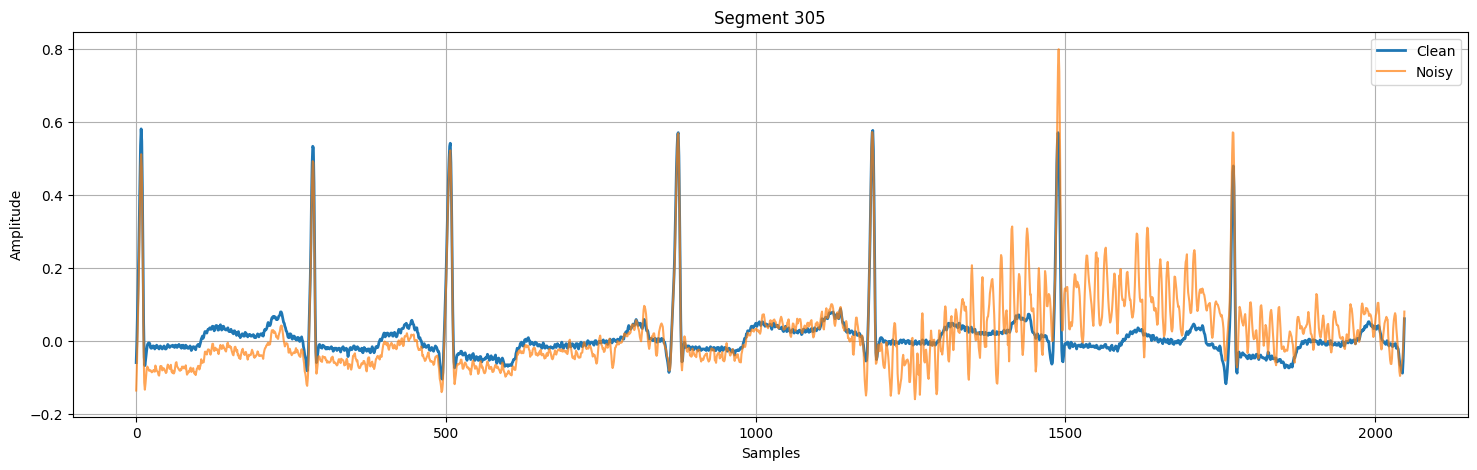

In [ ]:
compare_segment(
    y_train,
    x_train,
    train_metadata,
    segment_index=305
)

# Enhanced Visualization

In [42]:
# =========================================================
# GENERATE DENOISED SEGMENTS
# =========================================================

def generate_denoised_segments(
        model,
        noisy_segments,
        batch_size=64,
        device=None
):

    # -----------------------------------------------------
    # Device
    # -----------------------------------------------------

    if device is None:

        device = torch.device(
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        )

    model = model.to(device)

    model.eval()

    # -----------------------------------------------------
    # Dataloader
    # -----------------------------------------------------

    loader = DataLoader(

        TensorDataset(noisy_segments),

        batch_size=batch_size,

        shuffle=False
    )

    denoised_segments = []

    # -----------------------------------------------------
    # Inference
    # -----------------------------------------------------

    with torch.no_grad():

        for batch in loader:

            noisy = batch[0].to(device)

            denoised = model(noisy)

            denoised_segments.append(

                denoised.cpu()
            )

    # -----------------------------------------------------
    # Concatenate
    # -----------------------------------------------------

    denoised_segments = torch.cat(
        denoised_segments,
        dim=0
    )

    return denoised_segments

In [43]:
# =========================================================
# SINGLE PLOT FUNCTION
# =========================================================

def plot_ecg_signals(
        clean=None,
        noisy=None,
        denoised=None,
        fs=360,
        title="ECG Signals"
):

    plt.figure(figsize=(16,5))

    # -----------------------------------------------------
    # Time axis
    # -----------------------------------------------------

    signal_length = None

    if clean is not None:
        signal_length = len(clean)

    elif noisy is not None:
        signal_length = len(noisy)

    elif denoised is not None:
        signal_length = len(denoised)

    time = np.arange(signal_length) / fs

    # -----------------------------------------------------
    # Plot signals
    # -----------------------------------------------------

    if clean is not None:

        plt.plot(
            time,
            clean,
            label='Clean ECG',
            linewidth=2
        )

    if noisy is not None:

        noisy_snr = compute_snr(clean, noisy)

        plt.plot(
            time,
            noisy,
            label=f'Noisy ECG | SNR={noisy_snr:.2f} dB',
            alpha=0.7
        )

    if denoised is not None:

        denoised_snr = compute_snr(clean, denoised)

        improvement = denoised_snr - noisy_snr

        plt.plot(
            time,
            denoised,
            label=(
                f'Denoised ECG | '
                f'SNR={denoised_snr:.2f} dB | '
                f'Improvement={improvement:.2f} dB'
            ),
            linewidth=2
        )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")

    plt.title(title)

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()

In [44]:
def plot_ecg_subplots(
        clean,
        noisy,
        denoised,
        fs=360,
        title="ECG Comparison"
):

    time = np.arange(len(clean)) / fs

    noisy_snr = compute_snr(clean, noisy)

    denoised_snr = compute_snr(clean, denoised)

    snr_improvement = denoised_snr - noisy_snr

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(20,5)
    )

    # -----------------------------------------------------
    # Clean
    # -----------------------------------------------------

    axes[0].plot(time, clean)

    axes[0].set_title("Clean ECG")

    axes[0].set_xlabel("Time (s)")

    axes[0].grid(True)

    # -----------------------------------------------------
    # Noisy
    # -----------------------------------------------------

    axes[1].plot(time, noisy)

    axes[1].set_title(
        f"Noisy ECG\nSNR = {noisy_snr:.2f} dB"
    )

    axes[1].set_xlabel("Time (s)")

    axes[1].grid(True)

    # -----------------------------------------------------
    # Denoised
    # -----------------------------------------------------

    axes[2].plot(time, denoised)

    axes[2].set_title(
        f"Denoised ECG\n"
        f"SNR = {denoised_snr:.2f} dB\n"
        f"Improvement = {snr_improvement:.2f} dB"
    )

    axes[2].set_xlabel("Time (s)")

    axes[2].grid(True)

    plt.suptitle(title)

    plt.tight_layout()

    plt.show()

In [45]:
def plot_multiple_segments_enhanced(name,indice):
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  for idx in indices:

    # get individual segments and ensure they are squeezed to 1D arrays/tensors
    # Using .squeeze() drops the batch/channel dimensions so the math maps perfectly
    noisy_segment = x_test[idx].squeeze().to(device)
    clean_segment = y_test[idx].squeeze().to(device)

    models_to_test[name].eval()
    with torch.no_grad():
        # Unsqueeze to add batch dimension for the model inference pass (1, 1, 2048)
        noisy_input = x_test[idx:idx+1].to(device)
        denoised_output = models_to_test[name](noisy_input)

        # Squeeze the model output back to a 1D format for SNR math
        denoised_segment = denoised_output.squeeze()

    # Run the metrics using distinct, explicit functions
    snr_noisy = compute_snr(clean_segment, noisy_segment)
    snr_denoised = compute_snr(clean_segment, denoised_segment)

    print(f"for segment {idx}:")
    print(f"  - snr_noisy= {snr_noisy:.4f} dB")
    print(f"  - snr_denoised= {snr_denoised:.4f} dB")
    print(f"  - snr_improvement= {snr_denoised - snr_noisy:.4f} dB")

  #   visualize_ecg_signals(
  #     noisy=x_test[idx:idx+1],
  #     denoised=denoised_segment,
  #     clean=clean_segment,
  #     fs=360
  # )
  plot_ecg_signals(
        clean=clean_segment,
        noisy=x_test[idx:idx+1],
        denoised=denoised_segment,
        fs=360,
        title=f"ECG Signals (test segment {idx})"
)


In [46]:
def plot_multiple_segments_subplots(name,indice):
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  for idx in indices:

    # get individual segments and ensure they are squeezed to 1D arrays/tensors
    # Using .squeeze() drops the batch/channel dimensions so the math maps perfectly
    noisy_segment = x_test[idx].squeeze().to(device)
    clean_segment = y_test[idx].squeeze().to(device)

    models_to_test[name].eval()
    with torch.no_grad():
        # Unsqueeze to add batch dimension for the model inference pass (1, 1, 2048)
        noisy_input = x_test[idx:idx+1].to(device)
        denoised_output = models_to_test[name](noisy_input)

        # Squeeze the model output back to a 1D format for SNR math
        denoised_segment = denoised_output.squeeze()

    # Run the metrics using distinct, explicit functions
    snr_noisy = compute_snr(clean_segment, noisy_segment)
    snr_denoised = compute_snr(clean_segment, denoised_segment)

    print(f"for segment {idx}:")
    print(f"  - snr_noisy= {snr_noisy:.4f} dB")
    print(f"  - snr_denoised= {snr_denoised:.4f} dB")
    print(f"  - snr_improvement= {snr_denoised - snr_noisy:.4f} dB")

  #   visualize_ecg_signals(
  #     noisy=x_test[idx:idx+1],
  #     denoised=denoised_segment,
  #     clean=clean_segment,
  #     fs=360
  # )

  # plot_ecg_signals(
  #       clean=clean_segment,
  #       noisy=x_test[idx:idx+1],
  #       denoised=denoised_segment,
  #       fs=360,
  #       title=f"ECG Signals (test segment {idx})"
# )

    plot_ecg_subplots(
        clean=clean_segment,
        noisy=x_test[idx:idx+1],
        denoised=denoised_segment,
        fs=360,
        title="ECG Comparison"
)



In [47]:
# =========================
# TEST LOADER
# =========================

x_test = np.load(os.path.join(LOAD_DIR, "x_test.npy"))
y_test = np.load(os.path.join(LOAD_DIR, "y_test.npy"))
test_metadata = load_metadata(os.path.join(LOAD_DIR, "test_metadata.pkl"))

print("\nReload testing successfully")
print(x_test.shape)
print(y_test.shape)
print(len(test_metadata))


x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


Reload testing successfully
(3165, 1, 2048)
(3165, 1, 2048)
3165


In [48]:
denoised_segments = generate_denoised_segments(
    model=models_to_test['ResStackCAE'],
    noisy_segments=x_test,
    batch_size=64
)

In [105]:
idx = 11
clean_segment = y_test[idx][0].numpy()
noisy_segment = x_test[idx][0].numpy()
denoised_segment = denoised_segments[idx][0].numpy()

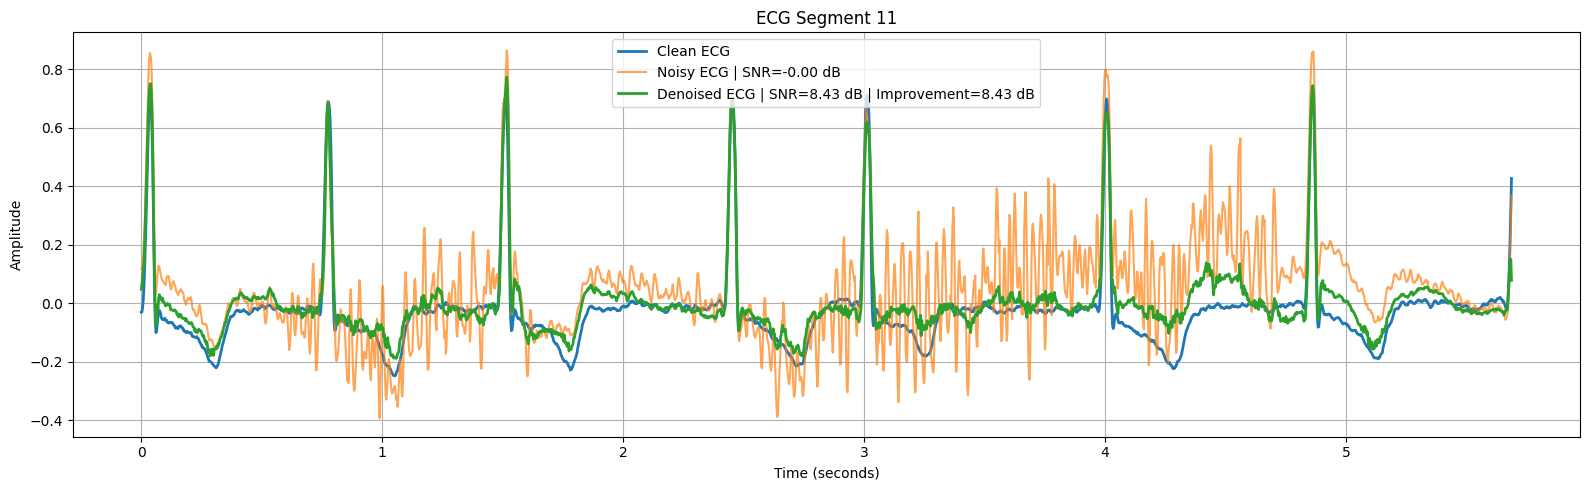

In [106]:
plot_ecg_signals(
    clean=clean_segment,
    noisy=noisy_segment,
    denoised=denoised_segment,
    title=f"ECG Segment {idx}"
)

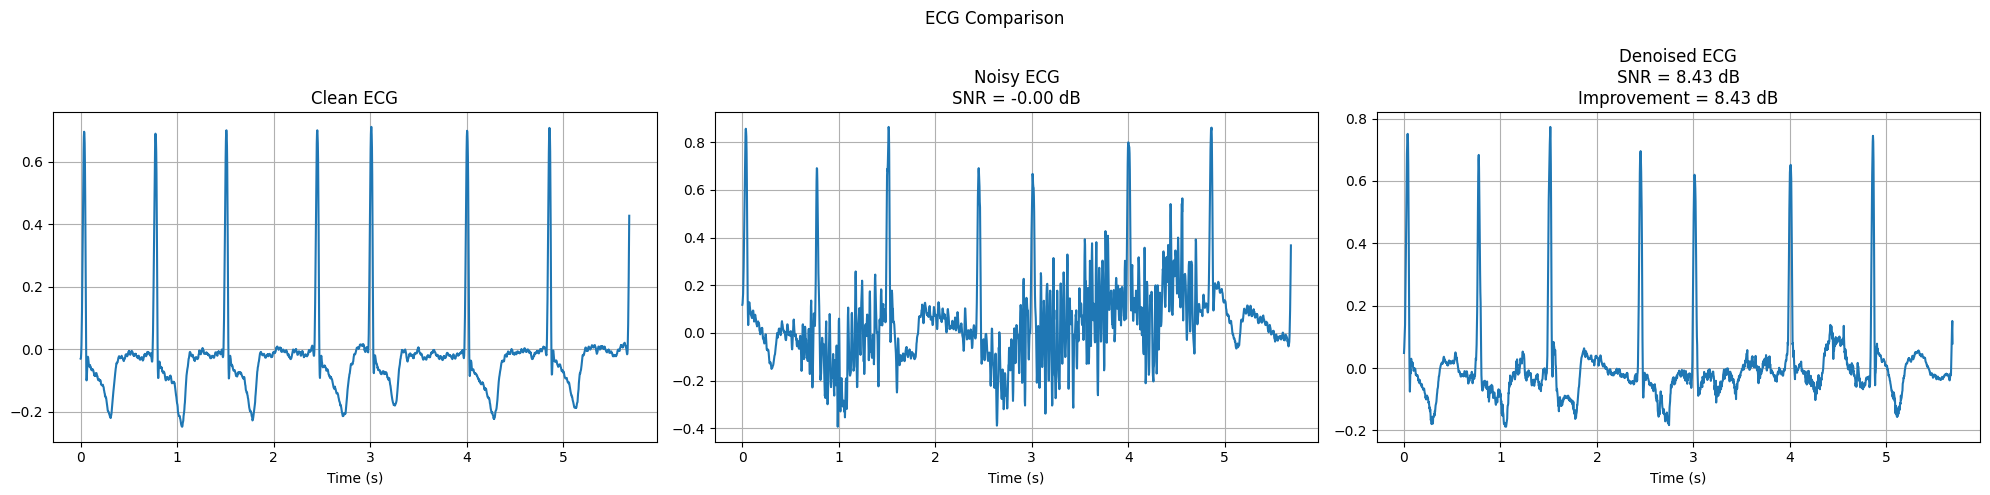

In [107]:
plot_ecg_subplots(
    clean_segment,
    noisy_segment,
    denoised_segment
)

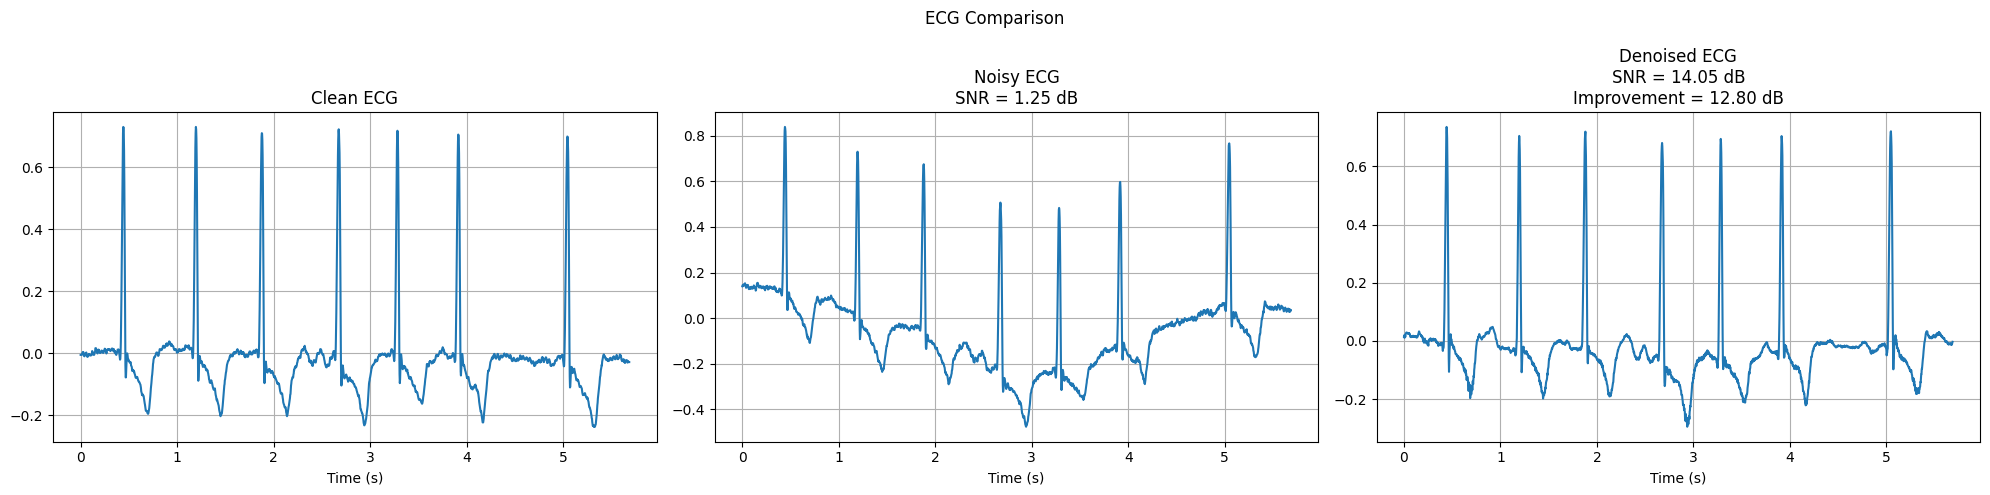

In [108]:
idx = 2
clean_segment = y_test[idx][0].numpy()
noisy_segment = x_test[idx][0].numpy()
denoised_segment = denoised_segments[idx][0].numpy()

plot_ecg_subplots(
    clean_segment,
    noisy_segment,
    denoised_segment
)

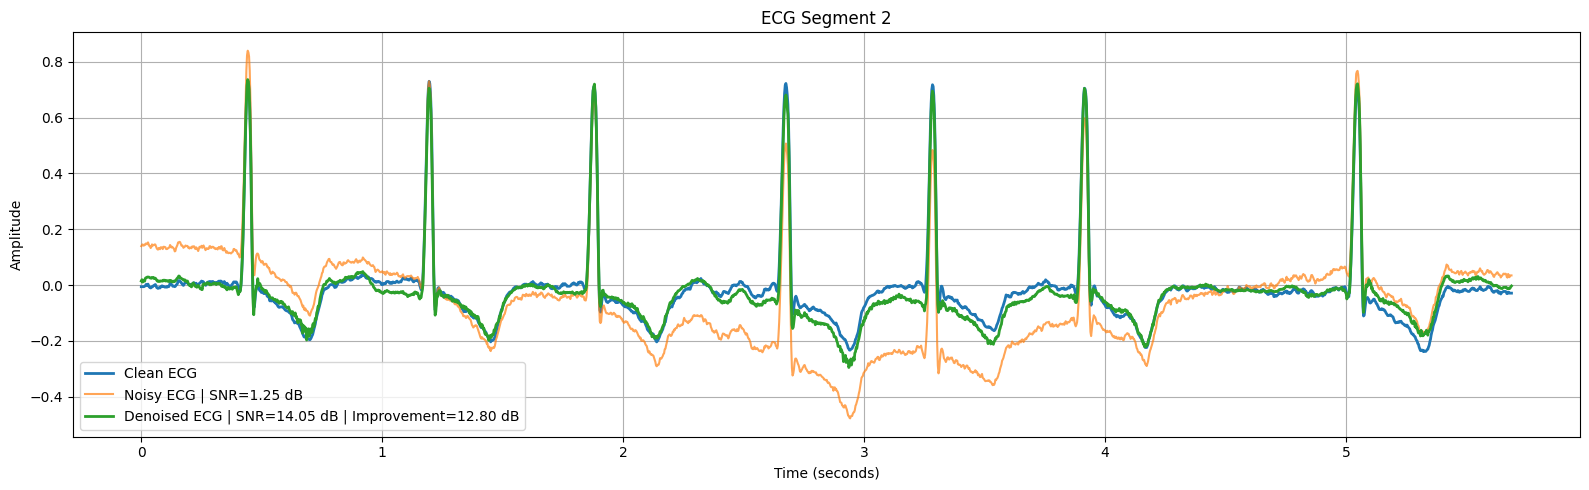

In [113]:
idx = 2
clean_segment = y_test[idx][0].numpy()
noisy_segment = x_test[idx][0].numpy()
denoised_segment = denoised_segments[idx][0].numpy()

plot_ecg_signals(
    clean=clean_segment,
    noisy=noisy_segment,
    denoised=denoised_segment,
    title=f"ECG Segment {idx}"
)

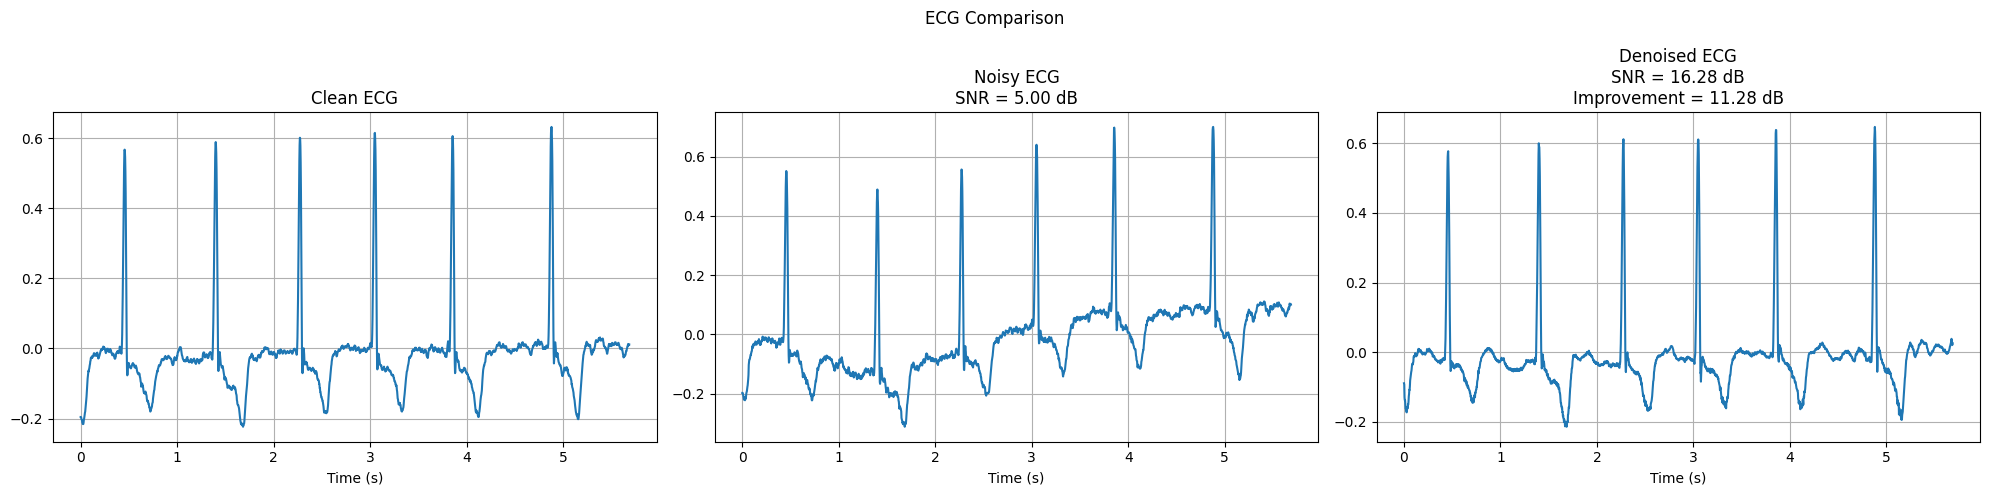

In [111]:
idx = 50
clean_segment = y_test[idx][0].numpy()
noisy_segment = x_test[idx][0].numpy()
denoised_segment = denoised_segments[idx][0].numpy()

plot_ecg_subplots(
    clean_segment,
    noisy_segment,
    denoised_segment
)

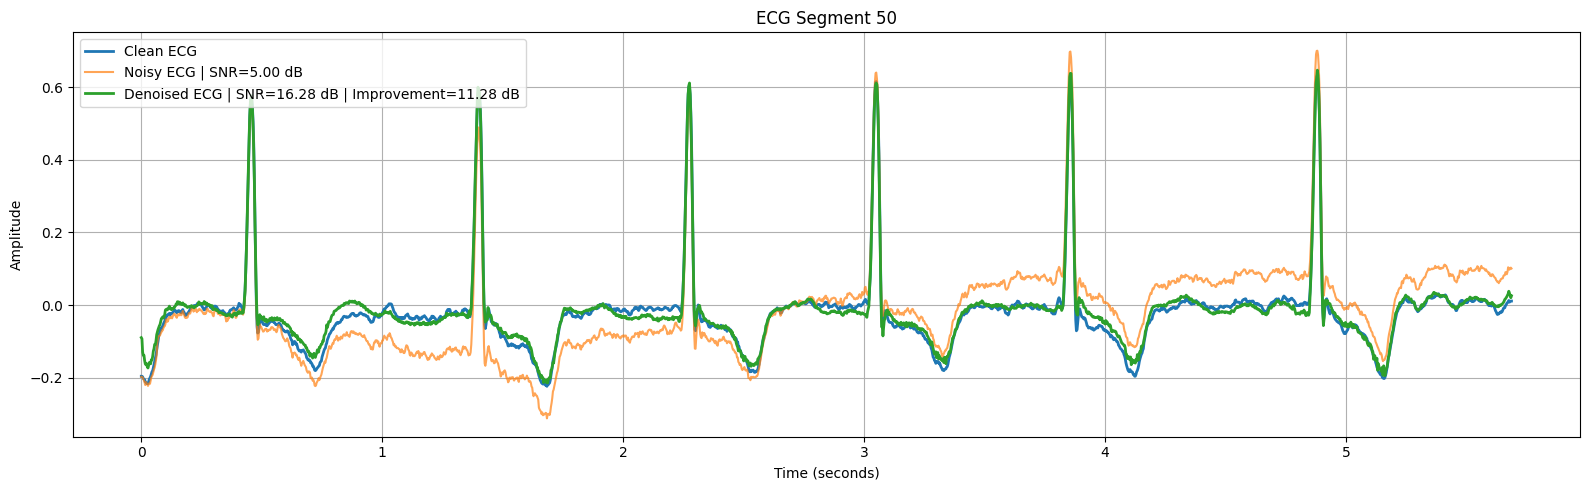

In [112]:
plot_ecg_signals(
    clean=clean_segment,
    noisy=noisy_segment,
    denoised=denoised_segment,
    title=f"ECG Segment {idx}"
)

In [73]:
# # Finding segment idx for each SNR value yo visualize later
# snr_unique_values = extract_unique_snr_values(train_metadata)
# indices = find_segments_idx(test_metadata,snr_unique_values)

# name ='ResStackCAE'
# plot_multiple_segments_enhanced(name,indices)
# plot_multiple_segments_subplots(name,indices)

# Analysis

In [62]:
metadata = test_metadata[idx]
print(metadata)

{'record': '202', 'segment_idx': 167, 'start': 171008, 'end': 173056, 'target_snr_db': 0, 'actual_snr_db': np.float64(-4.821637332766436e-16), 'noise_type': 'MA'}


In [67]:
def analyze_denoising_performance(
        clean_segments,
        noisy_segments,
        denoised_segments,
        metadata
):

    # -----------------------------------------------------
    # Loop over segments
    # -----------------------------------------------------

    results = []

    for i in range(len(clean_segments)):

        clean = clean_segments[i][0]
        noisy = noisy_segments[i][0]
        denoised = denoised_segments[i][0]

        # -------------------------------------------------
        # Metrics
        # -------------------------------------------------

        noisy_snr = compute_snr(clean, noisy)

        denoised_snr = compute_snr(clean, denoised)

        snr_improvement = (
            denoised_snr - noisy_snr
        )

        noisy_prd = compute_prd(clean, noisy)

        denoised_prd = compute_prd(clean, denoised)

        noisy_mse = compute_mse(clean, noisy)

        denoised_mse = compute_mse(clean, denoised)

        # -------------------------------------------------
        # Metadata
        # -------------------------------------------------

        snr_level = metadata[i]['target_snr_db']

        noise_type = metadata[i]['noise_type']

        results.append({

            'snr_level': snr_level,

            'noise_type': noise_type,

            'noisy_snr': noisy_snr,

            'denoised_snr': denoised_snr,

            'snr_improvement': snr_improvement,

            'noisy_prd': noisy_prd,

            'denoised_prd': denoised_prd,

            'noisy_mse': noisy_mse,

            'denoised_mse': denoised_mse
        })

    return results

In [64]:
def summarize_denoising_results(results):

    df = pd.DataFrame(results)

    summary = df.groupby(
        ['noise_type', 'snr_level']
    ).agg({

        'snr_improvement': 'mean',

        'denoised_snr': 'mean',

        'noisy_prd': 'mean',

        'denoised_prd': 'mean',

        'noisy_mse': 'mean',

        'denoised_mse': 'mean'

    }).reset_index()

    return summary

In [65]:
def analyze_failure_points(summary_df):

    print("\n" + "="*70)
    print("DENOISING FAILURE ANALYSIS")
    print("="*70)

    for _, row in summary_df.iterrows():

        noise_type = row['noise_type']

        snr_level = row['snr_level']

        improvement = row['snr_improvement']

        prd = row['denoised_prd']

        mse = row['denoised_mse']

        print("\n----------------------------------------")

        print(f"Noise Type : {noise_type}")

        print(f"Input SNR  : {snr_level} dB")

        print(f"SNR Gain   : {improvement:.2f} dB")

        print(f"PRD        : {prd:.2f}")

        print(f"MSE        : {mse:.6f}")

        # -------------------------------------------------
        # Failure Detection
        # -------------------------------------------------

        if improvement < 1:

            print(
                "WARNING: Very small denoising improvement."
            )

        if prd > 20:

            print(
                "WARNING: High waveform distortion."
            )

        if mse > 0.02:

            print(
                "WARNING: Large reconstruction error."
            )

        # -------------------------------------------------
        # Interpretation
        # -------------------------------------------------

        if snr_level == 0:

            print(
                "Very low SNR is difficult because "
                "important ECG morphology is buried in noise."
            )

        if noise_type == 'MA':

            print(
                "Muscle artifact (MA) is harder because "
                "its frequency overlaps ECG components."
            )

        if noise_type == 'BW':

            print(
                "Baseline wander (BW) is easier because "
                "it is low-frequency and smoother."
            )

    print("\n" + "="*70)

In [68]:
results = analyze_denoising_performance(
    clean_segments=y_test.numpy(),
    noisy_segments=x_test.numpy(),
    denoised_segments=denoised_segments,
    metadata=test_metadata
)

In [69]:
summary_df = summarize_denoising_results(results)
print(summary_df)

  noise_type  snr_level  snr_improvement  denoised_snr   noisy_prd  \
0         BW       0.00         8.684632      8.684632  100.000000   
1         BW       1.25         8.096424      9.346424   86.596428   
2         BW       5.00         5.201556     10.201556   56.234131   
3         MA       0.00         7.530568      7.530568  100.000000   
4         MA       1.25         7.246993      8.496993   86.596428   
5         MA       5.00         4.786621      9.786622   56.234135   

   denoised_prd  noisy_mse  denoised_mse  
0     39.361187   0.015667      0.004480  
1     36.860104   0.010274      0.002741  
2     33.986290   0.004179      0.002122  
3     44.461735   0.014069      0.003842  
4     40.017731   0.011167      0.003354  
5     35.125786   0.004498      0.002415  


In [71]:
summary_df.to_csv("denoising_comparison.csv",index=False)

In [70]:
analyze_failure_points(summary_df)


DENOISING FAILURE ANALYSIS

----------------------------------------
Noise Type : BW
Input SNR  : 0.0 dB
SNR Gain   : 8.68 dB
PRD        : 39.36
MSE        : 0.004480
Very low SNR is difficult because important ECG morphology is buried in noise.
Baseline wander (BW) is easier because it is low-frequency and smoother.

----------------------------------------
Noise Type : BW
Input SNR  : 1.25 dB
SNR Gain   : 8.10 dB
PRD        : 36.86
MSE        : 0.002741
Baseline wander (BW) is easier because it is low-frequency and smoother.

----------------------------------------
Noise Type : BW
Input SNR  : 5.0 dB
SNR Gain   : 5.20 dB
PRD        : 33.99
MSE        : 0.002122
Baseline wander (BW) is easier because it is low-frequency and smoother.

----------------------------------------
Noise Type : MA
Input SNR  : 0.0 dB
SNR Gain   : 7.53 dB
PRD        : 44.46
MSE        : 0.003842
Very low SNR is difficult because important ECG morphology is buried in noise.
Muscle artifact (MA) is harder bec

# Downstream Classification

## Inference Dataset & Model

actual signal length = 650000, reconstructed signal length = 649216 (due to ignoring the last segment (which is less than 2048)

In [ ]:
# # inference_model = models_to_test['ResStackCAE']
# inference_model = loaded_model

## Dataset Generation

### Generate Denoised Segments

In [74]:
# ============================================================
# GENERATE DENOISED SEGMENTS
# ============================================================

def generate_denoised_segments(model, dataloader, device):

    # ==========================================
    # Device
    # ==========================================

    device = torch.device("cuda" if torch.cuda.is_available()else "cpu")
    model = model.to(device)

    model.eval()
    denoised_segments = []
    with torch.no_grad():
      for batch in tqdm(dataloader):
        # ------------------------------------------------
        # TensorDataset(noisy_inference)
        # returns tuple with one element
        # ------------------------------------------------

        noisy_batch = batch[0].to(device)
        denoised_batch = model(noisy_batch)

        denoised_batch = (denoised_batch.cpu().numpy())

        denoised_segments.append(denoised_batch)

    denoised_segments = np.concatenate(denoised_segments,axis=0)
    return denoised_segments

### Reconstruct Signal from segments
from segments --> full signal

In [ ]:
# # ============================================================
# # RECONSTRUCT FULL ECG FROM OVERLAPPING SEGMENTS
# # ============================================================

# def reconstruct_signal(segments,window=WINDOW_SIZE,step=STEP_SIZE):
#     n_segments = len(segments)
#     total_length = (step * (n_segments - 1)+ window)
#     reconstructed = np.zeros(total_length)
#     counts = np.zeros(total_length)
#     for i, seg in enumerate(segments):
#         start = i * step
#         end = start + window
#         reconstructed[start:end] += seg
#         counts[start:end] += 1
#     reconstructed = reconstructed / counts
#     return reconstructed

# # ============================================================
# # GET ALL SEGMENTS OF SPECIFIC PATIENT
# # ============================================================

# def get_patient_segments(data,metadata,patient_id):
#     patient_segments = []
#     for i, meta in enumerate(metadata):
#         if meta['record'] == patient_id:
#             # print(f"record: {i}, patient id: {meta['record']} ")
#             patient_segments.append(data[i,0])
#     return np.array(patient_segments)

# # ============================================================
# # RECONSTRUCT FULL PATIENT ECG
# # ============================================================

# def reconstruct_patient_signal(data,metadata,patient_id):
#     patient_segments = get_patient_segments(data,metadata,patient_id)
#     full_signal = reconstruct_signal(patient_segments)
#     return full_signal

# # ============================================================
# # VISUALIZE ECG
# # ============================================================

# def plot_ecg(clean=None,noisy=None,denoised=None,start=0,end=5000):
#     plt.figure(figsize=(18,5))

#     if clean is not None:
#       plt.plot(clean[start:end],label='clean',linewidth=2)

#     if noisy is not None:
#         plt.plot(noisy[start:end],label='Noisy',alpha=0.7)

#     if denoised is not None:
#         plt.plot(denoised[start:end],label='Denoised',alpha=0.8)

#     plt.xlabel("Samples")
#     plt.ylabel("Amplitude")
#     plt.title("ECG Signal")
#     plt.legend()
#     plt.grid(True)
#     plt.show()

In [ ]:
# x_valid = torch.tensor(x_valid, dtype=torch.float32)
# get_patient_segments(x_valid,valid_metadata,'103')

In [ ]:
# def reconstruct_signal(segments,window=WINDOW_SIZE,step=STEP_SIZE):
#     n_segments = len(segments)
#     total_length = (step * (n_segments - 1)+ window)
#     reconstructed = np.zeros(total_length)
#     counts = np.zeros(total_length)
#     for i, seg in enumerate(segments):
#         start = i * step
#         end = start + window
#         reconstructed[start:end] += seg
#         counts[start:end] += 1
#     reconstructed = reconstructed / counts
#     return reconstructed

In [ ]:
train_metadata[4]

{'record': '100',
 'segment_idx': 4,
 'start': 4096,
 'end': 6144,
 'target_snr_db': 0,
 'actual_snr_db': np.float64(-1.446491199829931e-15),
 'noise_type': 'BW'}

In [75]:
def reconstruct_signal_from_segments(segments, metadata, record_id, signal_length, window=2048):

    reconstructed = np.zeros(signal_length)
    overlap_counter = np.zeros(signal_length)

    for seg, meta in zip(segments, metadata):

        # ----------------------------------------------------
        # Keep only current record segments
        # ----------------------------------------------------

        if str(meta['record']) != str(record_id):
            continue

        start = meta['start']
        end = start + window

        # ----------------------------------------------------
        # Skip invalid last segment
        # (because no zero padding used)
        # ----------------------------------------------------

        if end > signal_length:
            continue

        # ----------------------------------------------------
        # Remove channel dimension
        # shape:
        # (1,2048) -> (2048,)
        # ----------------------------------------------------

        if len(seg.shape) == 2:
            seg = seg[0]

        # ----------------------------------------------------
        # Overlap-add reconstruction
        # ----------------------------------------------------

        reconstructed[start:end] += seg
        overlap_counter[start:end] += 1

    # --------------------------------------------------------
    # Avoid division by zero
    # --------------------------------------------------------

    valid = overlap_counter > 0
    reconstructed[valid] = (reconstructed[valid]/ overlap_counter[valid])

    return reconstructed

### Reconstruct inference data from dataset type

In [76]:
def get_inference_data(datasetType, inference_model): # datasetType : train, test, valid

  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  inference_model = inference_model.to(device)

  noisy_file_name = "x_"+datasetType+ ".npy"
  clean_file_name = "y_"+datasetType+ ".npy"
  metadata_file_name =    datasetType +"_metadata.pkl"

  noisy_inference = np.load(os.path.join(LOAD_DATASET_DIR, noisy_file_name))     #(22155, 1, 2048)
  noisy_inference = torch.tensor(noisy_inference, dtype=torch.float32) #torch.Size([22155, 1, 2048])

  clean_inference = np.load(os.path.join(LOAD_DATASET_DIR, clean_file_name))
  clean_inference = torch.tensor(clean_inference, dtype=torch.float32)

  inference_metadata = load_metadata(os.path.join(LOAD_DATASET_DIR, metadata_file_name))

  noisy_inference_loader = DataLoader(TensorDataset(noisy_inference),batch_size=64,shuffle=False)
  # clean_inference_loader = DataLoader(TensorDataset(clean_inference),batch_size=64,shuffle=False)
  denoised_inference = generate_denoised_segments(inference_model, noisy_inference_loader, device)

  return clean_inference, noisy_inference, denoised_inference, inference_metadata

In [ ]:
# datasetType = 'train'
# clean_train_inference, noisy_train_inference, denoised_train_inference, inference_train_metadata = get_inference_data('train',inference_model )

### R-Centered Peak Segmentation

In [77]:
# beat cycle of length 256
# beat cycle of length 360


# def extract_r_peak_beats(signal, r_peaks, labels, before=99, after=157):

# def extract_r_centered_peak_beats(signal, r_peaks, labels, before=128, after=128):
def extract_r_centered_peak_beats(signal, r_peaks, labels, before=180, after=180):

    beats = []
    beat_labels = []
    beat_locations = []
    beat_size = before + after

    for r_peak, label in zip(r_peaks, labels):
        start = r_peak - before
        end = r_peak + after

        # ----------------------------------------------------
        # Boundary check
        # ----------------------------------------------------

        if start < 0:
            continue

        if end > len(signal):
            continue

        beat = signal[start:end]

        if len(beat) != beat_size:
            continue

        beats.append(beat)
        beat_labels.append(label)
        beat_locations.append(r_peak)

    return (np.array(beats), np.array(beat_labels), np.array(beat_locations))

### Extract Beats from Full Signal

In [78]:
def extract_beats_from_segments(RECORDS, clean_inference, noisy_inference, denoised_inference, inference_metadata):

  # --------------------------------------------------------
  # Reconstructing full signal
  # --------------------------------------------------------

  # reconstructed_clean = {}
  # reconstructed_noisy = {}
  # reconstructed_denoised = {}

  # --------------------------------------------------------
  # Datasets
  # --------------------------------------------------------
  X_clean_beats = []
  X_noisy_beats = []
  X_denoised_beats = []
  Y_labels = []
  beat_record_ids = []

  for record_id in RECORDS:
      print(f"Reconstructing Record {record_id}")

      # --------------------------------------------------------
      # Original record length
      # --------------------------------------------------------

      record = wfdb.rdrecord(str(record_id),pn_dir='mitdb')

      original_signal = record.p_signal[:,0]
      signal_length = len(original_signal)

      # --------------------------------------------------------
      # CLEAN
      # --------------------------------------------------------

      clean_signal = reconstruct_signal_from_segments(clean_inference.numpy(),inference_metadata,str(record_id),signal_length)

      # --------------------------------------------------------
      # NOISY
      # --------------------------------------------------------

      noisy_signal = reconstruct_signal_from_segments(noisy_inference.numpy(),inference_metadata,str(record_id),signal_length)

      # --------------------------------------------------------
      # DENOISED
      # --------------------------------------------------------

      denoised_signal = reconstruct_signal_from_segments(denoised_inference,inference_metadata,str(record_id),signal_length)
      # reconstructed_clean[str(record_id)] = clean_signal
      # reconstructed_noisy[str(record_id)] = noisy_signal
      # reconstructed_denoised[str(record_id)] = denoised_signal


      # --------------------------------------------------------
      # Load annotations of record
      # --------------------------------------------------------

      ann = wfdb.rdann(str(record_id),'atr', pn_dir='mitdb')
      r_peaks = ann.sample # detection of R-Peaks
      labels = ann.symbol

      # --------------------------------------------------------
      # Signals
      # --------------------------------------------------------

      # clean_signal = reconstructed_clean[str(record_id)]
      # noisy_signal = reconstructed_noisy[str(record_id)]
      # denoised_signal = reconstructed_denoised[str(record_id)]

      # --------------------------------------------------------
      # Beat Extraction
      # --------------------------------------------------------

      clean_beats, beat_labels, _ = extract_r_centered_peak_beats(clean_signal, r_peaks, labels)
      noisy_beats, _, _ = extract_r_centered_peak_beats(noisy_signal, r_peaks, labels)
      denoised_beats, _, _ = extract_r_centered_peak_beats(denoised_signal, r_peaks, labels)

      # --------------------------------------------------------
      # Store
      # --------------------------------------------------------

      X_clean_beats.append(clean_beats)
      X_noisy_beats.append(noisy_beats)
      X_denoised_beats.append(denoised_beats)
      Y_labels.append(beat_labels)

      beat_record_ids.extend([record_id] * len(beat_labels))  # should be returned if map beat to its record is needed

  print("Number of patient record in dataset .......")
  print(f"len((X_clean_beats)) = {len(X_clean_beats)}")
  print(f"len((X_noisy_beats)) = {len(X_noisy_beats)}")
  print(f"len((X_denoised_beats)) = {len(X_denoised_beats)}")
  print(f"len((Y_labels)) = {len(Y_labels)}")

  print("**************************************************")

  print("Number of Beats in each patient record .......")
  print(f"len((X_clean_beats[0])) = {len(X_clean_beats[0])}")
  print(f"len((X_noisy_beats[1])) = {len(X_noisy_beats[1])}")
  print(f"len((X_denoised_beats[2])) = {len(X_denoised_beats[2])}")
  print(f"len((Y_labels[3])) = {len(Y_labels[3])}")

  print("**************************************************")

  X_clean_beats = np.concatenate(X_clean_beats,axis=0)
  X_noisy_beats = np.concatenate(X_noisy_beats,axis=0)
  X_denoised_beats = np.concatenate(X_denoised_beats,axis=0)
  Y_labels = np.concatenate(Y_labels,axis=0)

  print("Shape of beats datasets after concatenation ......")
  print(f"X_clean_beats.shape ={X_clean_beats.shape}")
  print(f"X_noisy_beats.shape ={X_noisy_beats.shape}")
  print(f"X_denoised_beats.shape ={X_denoised_beats.shape}")
  print(f"Y_labels.shape ={Y_labels.shape}")

  print("**************************************************")

  X_clean_beats = np.expand_dims(X_clean_beats,axis=1)
  X_noisy_beats = np.expand_dims(X_noisy_beats,axis=1)
  X_denoised_beats = np.expand_dims(X_denoised_beats,axis=1)

  print("Shape of beats datasets after concatenation and modifying dimensions......")
  print(f"X_clean_beats.shape ={X_clean_beats.shape}")
  print(f"X_noisy_beats.shape ={X_noisy_beats.shape}")
  print(f"X_denoised_beats.shape ={X_denoised_beats.shape}")
  print(f"Y_labels.shape ={Y_labels.shape}")

  return X_clean_beats,X_noisy_beats, X_denoised_beats, Y_labels

In [ ]:
# DATASET_RECORDS = TRAIN_RECORDS
# X_clean_train_beats,X_noisy_train_beats, X_denoised_train_beats, Y_train_labels = extract_beats_from_segments(DATASET_RECORDS, clean_train_inference, noisy_train_inference, denoised_train_inference, inference_train_metadata)

In [ ]:
# reconstructed_denoised['100'].shape

(650000,)

### Save beats of constructed full signal

In [ ]:
# SAVE_BEATS_DIR = "/content/drive/MyDrive/CSE672_Neural_Nets/Project/Saved_beats"

In [79]:
def save_beats(dicts_to_save):
  os.makedirs(SAVE_BEATS_DIR, exist_ok=True)
  print("Save Beats directory:", SAVE_BEATS_DIR)
  for filename, data in dicts_to_save.items():
      with open(os.path.join(SAVE_BEATS_DIR, filename),"wb") as f:
          pickle.dump(data, f)
  print("Saved successfully")

### Load beats of constructed full signal



In [80]:
def load_beats(dicts_to_load):
  print("Load Beats directory:", SAVE_BEATS_DIR)
  for name, _ in dicts_to_load.items():
    with open(os.path.join(SAVE_BEATS_DIR, name),"rb") as f:
        dicts_to_load[name] = pickle.load(f)

### Extract Unique Labels

In [81]:
def get_uniques_labels(Y_labels):

  # Find unique values
  unique_values = np.unique(Y_labels)

  # Print results
  print("Unique Values:", unique_values)
  print("Count of Unique Values:", len(unique_values))

### AAMI 5-Class Mapping

In [ ]:
# N: Normal, S: Supraventricular, V: Ventricular, F: Fusion, Q: Unknown

In [82]:
AAMI_MAP = {

    # ----------------------------------------
    # N
    # ----------------------------------------
    'N': 'N',
    'L': 'N',
    'R': 'N',
    'e': 'N',
    'j': 'N',

    # ----------------------------------------
    # S
    # ----------------------------------------
    'A': 'S',
    'a': 'S',
    'J': 'S',
    'S': 'S',

    # ----------------------------------------
    # V
    # ----------------------------------------
    'V': 'V',
    'E': 'V',

    # ----------------------------------------
    # F
    # ----------------------------------------
    'F': 'F',

    # ----------------------------------------
    # Q
    # ----------------------------------------
    '/': 'Q',
    'Q': 'Q'
}

### inference beats filtering



In [83]:
def filter_inference_beats(X_clean_beats,X_noisy_beats, X_denoised_beats, Y_labels):
  valid_indices = []
  for i, label in enumerate(Y_labels):
      if label in AAMI_MAP:
          valid_indices.append(i)
  len(valid_indices) # original (83343), ignored = 83343 - 81064 of size 256
                   #  (83333) of size 360, ignored = 83333 -81054
  # set(valid_indices)
  X_clean_beats_filtered = X_clean_beats[valid_indices]
  X_noisy_beats_filtered = X_noisy_beats[valid_indices]
  X_denoised_beats_filtered = X_denoised_beats[valid_indices]

  Y_aami = np.array([AAMI_MAP[Y_labels[i]]for i in valid_indices])

  print("Shape of beats datasets after filtering ......")
  print(f"X_clean_beats_filtered.shape ={X_clean_beats_filtered.shape}")
  print(f"X_noisy_beats_filtered.shape ={X_noisy_beats_filtered.shape}")
  print(f"X_denoised_beats_filtered.shape ={X_denoised_beats_filtered.shape}")
  print(f"Y_aami.shape ={Y_aami.shape}")

  Y_filtered = Y_aami
  return X_clean_beats_filtered, X_noisy_beats_filtered, X_denoised_beats_filtered, Y_filtered

In [ ]:
# X_clean_train_beats_filtered, X_noisy_train_beats_filtered, X_denoised_train_beats_filtered, Y_train_filtered = filter_inference_beats(X_clean_train_beats,X_noisy_train_beats, X_denoised_train_beats, Y_train_labelss)

### Labels Encoding

In [84]:
# Mapping for encoding to model
AAMI_TO_INT = {
    'N': 0,
    'S': 1,
    'V': 2,
    'F': 3,
    'Q': 4
}
# Mapping for confusion matrix
INT_TO_AAMI = {
    0: 'N',
    1: 'S',
    2: 'V',
    3: 'F',
    4: 'Q'
}

def encode_labels(Y_filtered):
  Y_encoded = np.array([ AAMI_TO_INT[label]for label in Y_filtered])
  # print(Y_encoded.shape)
  # print(np.unique(Y_encoded))
  return Y_encoded

### CREATE 3-BEAT CONTEXT DATASET

In [85]:
def create_context_dataset(
        beats,
        labels
    ):

    X = []
    Y = []

    for i in range(1, len(beats)-1):

        # ----------------------------------------
        # Previous beat
        # ----------------------------------------

        prev_beat = beats[i-1]

        # ----------------------------------------
        # Current beat
        # ----------------------------------------

        current_beat = beats[i]

        # ----------------------------------------
        # Next beat
        # ----------------------------------------

        next_beat = beats[i+1]

        # ----------------------------------------
        # Concatenate
        # ----------------------------------------

        context = np.concatenate(
            [
                prev_beat,
                current_beat,
                next_beat
            ],
            axis=-1
        )

        # shape:
        # (1,1080)

        X.append(context)

        # middle beat label
        Y.append(labels[i])

    X = np.array(X)
    Y = np.array(Y)

    return X, Y

### Save Context Dataset (X,Y)

In [ ]:
# SAVE_CONTEXT_DIR = "/content/drive/MyDrive/CSE672_Neural_Nets/Project/Context_dataset"

In [86]:
def save_context_dataset(dicts_to_save):
  os.makedirs(SAVE_CONTEXT_DIR, exist_ok=True)
  print("Save Context dataset directory:", SAVE_CONTEXT_DIR)
  for filename, data in dicts_to_save.items():
      with open(os.path.join(SAVE_CONTEXT_DIR, filename),"wb") as f:
          pickle.dump(data, f)
  print("Saved successfully")

### Load Context Dataset (X,Y)

In [87]:
def load_context_dataset(dicts_to_load):
  print("Load context dataset directory:", SAVE_CONTEXT_DIR)
  for name, _ in dicts_to_load.items():
    with open(os.path.join(SAVE_CONTEXT_DIR, name),"rb") as f:
        dicts_to_load[name] = pickle.load(f)

## Class Imbalance

#### Histogram Plotting

In [88]:
def plot_histogram(Y_filtered):

  # check class counts
  unique, counts = np.unique(Y_filtered,return_counts=True)
  total = Y_filtered.shape[0]
  for u, c in zip(unique, counts):
    percentage = c/total
    print(u, c,f"   {percentage*100}%" )

  counter = Counter(Y_aami)
  classes = ['N', 'S', 'V', 'F', 'Q']
  counts = [counter.get(c, 0)for c in classes]

  plt.figure(figsize=(8,5))
  plt.bar(classes, counts)
  plt.xlabel("AAMI Class")
  plt.ylabel("Number of Beats")
  plt.title("AAMI 5-Class Distribution")
  for i, count in enumerate(counts):plt.text(i,count,str(count),ha='center')
  plt.show()

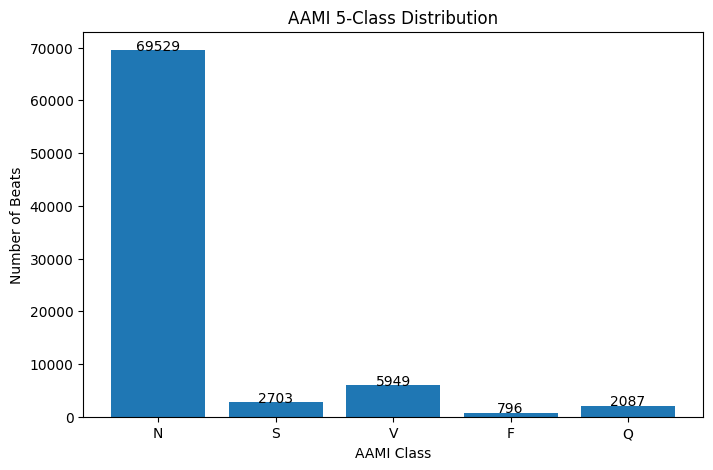

In [ ]:
plot_histogram(Y_train_filtered)

## Loss Function (handles unbalance without synthesis data)

#### Alpha Calculation

In [89]:
def calculate_alpha(Y_context):
  class_counts = np.bincount(Y_context)
  alpha = 1.0 / class_counts
  alpha = alpha / alpha.sum()
  return alpha

In [90]:
def calculate_class_weights(Y_context):
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  classes = np.unique(Y_context)
  weights = compute_class_weight(class_weight='balanced',classes=classes,y=Y_context)
  class_weights = torch.tensor(weights,dtype=torch.float32).to(device)
  return class_weights

### FocalLoss Function Definition

In [91]:
class FocalLoss(nn.Module):
    def __init__(self,alpha=None,gamma=2):

        super().__init__()

        self.alpha = alpha
        self.gamma = gamma

    def forward(self,logits,targets):

        # ----------------------------------------
        # Cross entropy
        # ----------------------------------------

        ce_loss = F.cross_entropy(logits,targets,reduction='none')

        # ----------------------------------------
        # pt
        # ----------------------------------------

        pt = torch.exp(-ce_loss)

        # ----------------------------------------
        # alpha weights
        # ----------------------------------------

        if self.alpha is not None:
            at = self.alpha[targets]
            loss = at * ( (1 - pt) ** self.gamma) * ce_loss

        else:
            loss = ((1 - pt) ** self.gamma) * ce_loss

        return loss.mean()

## Classifier

In [ ]:
# encoder input  (N,1,1080) (3 beats of size 360 each)
# encoder output (N,64,135) features = 135 x 64 = 8640

In [92]:
class ECGClassifier(nn.Module):

    def __init__(
            self,
            encoder,
            num_classes=5,
            freeze_encoder=False
        ):

        super().__init__()

        # CAE encoder
        self.encoder = encoder # (N,1,1080) --> (N,64,135)

        # ----------------------------------------
        # Freeze encoder
        # ----------------------------------------

        if freeze_encoder:

            for param in self.encoder.parameters():

                param.requires_grad = False

        # ----------------------------------------
        # Global pooling
        # ----------------------------------------

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # ----------------------------------------
        # Classifier
        # ----------------------------------------

        # Classification head
        self.classifier = nn.Sequential(

            nn.Linear(64, 128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        _, _, _, _, e5 = self.encoder(x)

        # e5:
        # (N,64,L)

        x = self.global_pool(e5)

        # (N,64,1)

        x = x.squeeze(-1)

        # (N,64)

        logits = self.classifier(x)

        return logits

In [ ]:
encoder = ResStackEncoder()
summary(encoder)

Layer (type:depth-idx)                   Param #
ResStackEncoder                          --
├─Sequential: 1-1                        --
│    └─Conv1d: 2-1                       64
│    └─BatchNorm1d: 2-2                  32
│    └─ReLU: 2-3                         --
│    └─Conv1d: 2-4                       784
│    └─BatchNorm1d: 2-5                  32
│    └─ReLU: 2-6                         --
├─MaxPool1d: 1-2                         --
├─Sequential: 1-3                        --
│    └─Conv1d: 2-7                       1,568
│    └─BatchNorm1d: 2-8                  64
│    └─ReLU: 2-9                         --
│    └─Conv1d: 2-10                      3,104
│    └─BatchNorm1d: 2-11                 64
│    └─ReLU: 2-12                        --
├─MaxPool1d: 1-4                         --
├─Sequential: 1-5                        --
│    └─Conv1d: 2-13                      6,208
│    └─BatchNorm1d: 2-14                 128
│    └─ReLU: 2-15                        --
│    └─Conv1d: 2

## Training Loop

In [93]:
def train_classifier(model, train_loader, valid_loader, criterion, optimizer, epochs=EPOCHS):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    history = {
        'train_loss': [],
        'valid_loss': [],
        'train_acc': [],
        'valid_acc': []
    }

    for epoch in range(epochs):

        # ==========================================
        # TRAIN
        # ==========================================

        model.train()

        total_loss = 0
        correct = 0
        total = 0

        for x, y in train_loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)

            preds = torch.argmax(logits,dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        train_loss = total_loss / total
        train_acc = correct / total

        # ==========================================
        # VALIDATION
        # ==========================================

        model.eval()

        valid_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for x, y in valid_loader:

                x = x.to(device)
                y = y.to(device)

                logits = model(x)
                loss = criterion(logits, y)
                valid_loss += (loss.item() * x.size(0))
                preds = torch.argmax(logits,dim=1)

                correct += (preds == y).sum().item()
                total += y.size(0)

        valid_loss /= total
        valid_acc = correct / total

        history['train_loss'].append(train_loss)
        history['valid_loss'].append(valid_loss)

        history['train_acc'].append(train_acc)
        history['valid_acc'].append(valid_acc)

        print(
            f"Epoch {epoch+1} | "
            f"Train Loss={train_loss:.4f} | "
            f"Val Loss={valid_loss:.4f} | "
            f"Train Acc={train_acc:.4f} | "
            f"Val Acc={valid_acc:.4f}"
        )

    return history

## Evaluation

In [ ]:
# def evaluate_classifier(model,test_loader):

#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     model.eval()
#     model.to(device)

#     all_preds = []
#     all_labels = []

#     with torch.no_grad():

#         for x, y in test_loader:

#             x = x.to(device)
#             logits = model(x)
#             preds = torch.argmax(logits,dim=1)
#             all_preds.extend(preds.cpu().numpy())
#             all_labels.extend(y.numpy())

#     print(
#         classification_report(all_labels,all_preds,
#             target_names=[
#                 'N',
#                 'S',
#                 'V',
#                 'F',
#                 'Q'
#             ]
#         )
#     )

#     cm = confusion_matrix(
#         all_labels,
#         all_preds
#     )

#     return cm

In [ ]:
# def evaluate_model(model,dataloader):

#   device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#   model.eval()
#   all_preds = []
#   all_probs = []
#   all_labels = []

#   with torch.no_grad():
#       for x, y in dataloader:

#           x = x.to(device)
#           logits = model(x)

#           probs = torch.softmax(logits,dim=1)

#           preds = torch.argmax(probs,dim=1)

#           all_preds.extend(preds.cpu().numpy())

#           all_probs.extend(probs.cpu().numpy())

#           all_labels.extend(y.numpy())

#   # ==========================================
#   # Metrics
#   # ==========================================

#   acc = accuracy_score(
#       all_labels,
#       all_preds
#   )

#   precision = precision_score(
#       all_labels,
#       all_preds,
#       average='macro'
#   )

#   sensitivity = recall_score(
#       all_labels,
#       all_preds,
#       average='macro'
#   )

#   f1 = f1_score(
#       all_labels,
#       all_preds,
#       average='macro'
#   )

#   cm = confusion_matrix(
#       all_labels,
#       all_preds
#   )

#   print("\nClassification Report\n")

#   print(
#       classification_report(
#           all_labels,
#           all_preds,
#           target_names=[
#               'N',
#               'S',
#               'V',
#               'F',
#               'Q'
#           ]
#       )
#   )

#   print(f"Accuracy    : {acc:.4f}")
#   print(f"Precision   : {precision:.4f}")
#   print(f"Sensitivity : {sensitivity:.4f}")
#   print(f"F1-score    : {f1:.4f}")

#   return {
#       'accuracy': acc,
#       'precision': precision,
#       'sensitivity': sensitivity,
#       'f1_score': f1,
#       'confusion_matrix': cm,
#       'labels': np.array(all_labels),
#       'probs': np.array(all_probs)
#   }

In [94]:
# =========================================================
# EVALUATION FUNCTION
# =========================================================

def evaluate_model(
        model,
        dataloader,
        num_classes=5,
        device=None
):

    # -----------------------------------------------------
    # Device
    # -----------------------------------------------------

    if device is None:
        device = torch.device(
            "cuda" if torch.cuda.is_available()
            else "cpu"
        )

    model = model.to(device)
    model.eval()

    # -----------------------------------------------------
    # Storage
    # -----------------------------------------------------

    all_labels = []
    all_preds = []
    all_probs = []

    # -----------------------------------------------------
    # Inference
    # -----------------------------------------------------

    with torch.no_grad():

        for x, y in dataloader:

            x = x.to(device)
            y = y.to(device)

            logits = model(x)

            probs = torch.softmax(
                logits,
                dim=1
            )

            preds = torch.argmax(
                probs,
                dim=1
            )

            # ---------------------------------------------
            # Store
            # ---------------------------------------------

            all_labels.extend(
                y.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

    # -----------------------------------------------------
    # Convert to numpy
    # -----------------------------------------------------

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )

    sensitivity = recall_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )

    # -----------------------------------------------------
    # Per-class metrics
    # -----------------------------------------------------

    f1_per_class = f1_score(
        all_labels,
        all_preds,
        average=None,
        zero_division=0
    )

    sensitivity_per_class = recall_score(
        all_labels,
        all_preds,
        average=None,
        zero_division=0
    )

    # -----------------------------------------------------
    # Confusion matrix
    # -----------------------------------------------------

    cm = confusion_matrix(
        all_labels,
        all_preds
    )

    # -----------------------------------------------------
    # ROC-AUC
    # -----------------------------------------------------

    labels_bin = label_binarize(
        all_labels,
        classes=np.arange(num_classes)
    )

    auc_per_class = []

    for i in range(num_classes):

        try:

            auc = roc_auc_score(
                labels_bin[:, i],
                all_probs[:, i]
            )

        except:
            auc = 0.0

        auc_per_class.append(auc)

    # -----------------------------------------------------
    # Return dictionary
    # -----------------------------------------------------

    results = {

        'accuracy': accuracy,

        'precision': precision,

        'sensitivity': sensitivity,

        'f1_score': f1,

        'f1_per_class': f1_per_class,

        'sensitivity_per_class': sensitivity_per_class,

        'auc_per_class': auc_per_class,

        'confusion_matrix': cm,

        'labels': all_labels,

        'predictions': all_preds,

        'probs': all_probs
    }

    return results

## Confusion Matrix

In [95]:
def plot_confusion_matrix(cm):
    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['N','S','V','F','Q'],
        yticklabels=['N','S','V','F','Q']
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

## ROC Curve (AUC)


*   since dataset is composed of 5 classes, using One-vs-Rest to determine the True class vs the rest

*   each classifier will output 5 curves for 5 One-vs-Rest Curve



In [96]:

def plot_multiclass_roc(labels,probs,title="ROC Curve"):

    n_classes = 5
    labels_bin = label_binarize(labels,classes=[0,1,2,3,4])

    plt.figure(figsize=(8,6))
    auc_scores = {}

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(
            labels_bin[:, i],
            probs[:, i]
        )

        roc_auc = auc(fpr, tpr)

        auc_scores[i] = roc_auc

        plt.plot(
            fpr,
            tpr,
            label=f'Class {i} AUC={roc_auc:.4f}'
        )

    plt.plot(
        [0,1],
        [0,1],
        linestyle='--'
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(title)

    plt.legend()

    plt.grid()

    plt.show()

    return auc_scores

## Main Logic

### Data Preparation

In [97]:
inference_model = models_to_test['ResStackCAE']
# inference_model = loaded_model

In [ ]:
# datasetType = 'train'
# clean_train_inference, noisy_train_inference, denoised_train_inference, inference_train_metadata = get_inference_data('train',inference_model )

100%|██████████| 347/347 [00:04<00:00, 70.72it/s]


In [ ]:
# DATASET_RECORDS = TRAIN_RECORDS
# X_clean_train_beats,X_noisy_train_beats, X_denoised_train_beats, Y_train_labels = extract_beats_from_segments(DATASET_RECORDS, clean_train_inference, noisy_train_inference, denoised_train_inference, inference_train_metadata)

Reconstructing Record 100
Reconstructing Record 101
Reconstructing Record 106
Reconstructing Record 107
Reconstructing Record 108
Reconstructing Record 109
Reconstructing Record 111
Reconstructing Record 112
Reconstructing Record 113
Reconstructing Record 115
Reconstructing Record 117
Reconstructing Record 118
Reconstructing Record 122
Reconstructing Record 123
Reconstructing Record 124
Reconstructing Record 200
Reconstructing Record 201
Reconstructing Record 203
Reconstructing Record 205
Reconstructing Record 207
Reconstructing Record 208
Reconstructing Record 209
Reconstructing Record 210
Reconstructing Record 212
Reconstructing Record 213
Reconstructing Record 214
Reconstructing Record 215
Reconstructing Record 220
Reconstructing Record 222
Reconstructing Record 223
Reconstructing Record 228
Reconstructing Record 231
Reconstructing Record 232
Reconstructing Record 233
Reconstructing Record 234
Number of patient record in dataset .......
len((X_clean_beats)) = 35
len((X_noisy_beats))

In [ ]:
# X_clean_train_beats_filtered, X_noisy_train_beats_filtered, X_denoised_train_beats_filtered, Y_train_filtered = filter_inference_beats(X_clean_train_beats,X_noisy_train_beats, X_denoised_train_beats, Y_train_labels)

Shape of beats datasets after filtering ......
X_clean_beats_filtered.shape =(81054, 1, 360)
X_noisy_beats_filtered.shape =(81054, 1, 360)
X_denoised_beats_filtered.shape =(81054, 1, 360)
Y_aami.shape =(81054,)


In [ ]:
# train_dict_to_save = {
#       "X_clean_train_beats_filtered.pkl": X_clean_train_beats_filtered,
#       "X_noisy_train_beats_filtered.pkl": X_noisy_train_beats_filtered,
#       "X_denoised_train_beats_filtered.pkl": X_denoised_train_beats_filtered
# }
# save_beats(train_dict_to_save)

Save Beats directory: /content/drive/MyDrive/CSE672_Neural_Nets/Project/Saved_beats
Saved successfully


In [ ]:
# len(np.unique(Y_train_filtered))
# Y_train_encoded = encode_labels(Y_train_filtered)
# len(np.unique(Y_train_encoded))

(5,)
[0 1 2 3 4]


5

In [ ]:
# #using inference model encoder with filtered train beats

# idx = np.random.randint(len(X_clean_train_beats_filtered))
# sample = X_clean_train_beats_filtered[idx:idx+1]

# print(sample.shape)
# sample = torch.tensor(sample,dtype=torch.float32).to(device)

# with torch.no_grad():
#     out = inference_model.encoder(sample)
# # len(out)
# # out

(1, 1, 360)


In [ ]:
# datasetType = 'valid'
# clean_valid_inference, noisy_valid_inference, denoised_valid_inference, inference_valid_metadata = get_inference_data('valid',inference_model )

# DATASET_RECORDS = VALID_RECORDS
# X_clean_valid_beats,X_noisy_valid_beats, X_denoised_valid_beats, Y_valid_labels = extract_beats_from_segments(DATASET_RECORDS, clean_valid_inference, noisy_valid_inference, denoised_valid_inference, inference_valid_metadata)
# X_clean_valid_beats_filtered, X_noisy_valid_beats_filtered, X_denoised_valid_beats_filtered, Y_valid_filtered = filter_inference_beats(X_clean_valid_beats,X_noisy_valid_beats, X_denoised_valid_beats, Y_valid_labels)

100%|██████████| 50/50 [00:00<00:00, 65.78it/s]


Reconstructing Record 119
Reconstructing Record 105
Reconstructing Record 103
Reconstructing Record 221
Reconstructing Record 217
Number of patient record in dataset .......
len((X_clean_beats)) = 5
len((X_noisy_beats)) = 5
len((X_denoised_beats)) = 5
len((Y_labels)) = 5
**************************************************
Number of Beats in each patient record .......
len((X_clean_beats[0])) = 2093
len((X_noisy_beats[1])) = 2690
len((X_denoised_beats[2])) = 2089
len((Y_labels[3])) = 2461
**************************************************
Shape of beats datasets after concatenation ......
X_clean_beats.shape =(11612, 360)
X_noisy_beats.shape =(11612, 360)
X_denoised_beats.shape =(11612, 360)
Y_labels.shape =(11612,)
**************************************************
Shape of beats datasets after concatenation and modifying dimensions......
X_clean_beats.shape =(11612, 1, 360)
X_noisy_beats.shape =(11612, 1, 360)
X_denoised_beats.shape =(11612, 1, 360)
Y_labels.shape =(11612,)
Shape of be

In [ ]:
# valid_dict_to_save = {
#       "X_clean_valid_beats_filtered.pkl": X_clean_valid_beats_filtered,
#       "X_noisy_valid_beats_filtered.pkl": X_noisy_valid_beats_filtered,
#       "X_denoised_valid_beats_filtered.pkl": X_denoised_valid_beats_filtered
# }
# save_beats(valid_dict_to_save)

Save Beats directory: /content/drive/MyDrive/CSE672_Neural_Nets/Project/Saved_beats
Saved successfully


In [ ]:
# datasetType = 'test'
# clean_test_inference, noisy_test_inference, denoised_test_inference, inference_test_metadata = get_inference_data('test',inference_model )

# DATASET_RECORDS = TEST_RECORDS
# X_clean_test_beats,X_noisy_test_beats, X_denoised_test_beats, Y_test_labels = extract_beats_from_segments(DATASET_RECORDS, clean_test_inference, noisy_test_inference, denoised_test_inference, inference_test_metadata)
# X_clean_test_beats_filtered, X_noisy_test_beats_filtered, X_denoised_test_beats_filtered, Y_test_filtered = filter_inference_beats(X_clean_test_beats,X_noisy_test_beats, X_denoised_test_beats, Y_test_labels)

100%|██████████| 50/50 [00:00<00:00, 66.35it/s]


Reconstructing Record 219
Reconstructing Record 202
Reconstructing Record 116
Reconstructing Record 121
Reconstructing Record 230
Number of patient record in dataset .......
len((X_clean_beats)) = 5
len((X_noisy_beats)) = 5
len((X_denoised_beats)) = 5
len((Y_labels)) = 5
**************************************************
Number of Beats in each patient record .......
len((X_clean_beats[0])) = 2312
len((X_noisy_beats[1])) = 2145
len((X_denoised_beats[2])) = 2419
len((Y_labels[3])) = 1873
**************************************************
Shape of beats datasets after concatenation ......
X_clean_beats.shape =(11213, 360)
X_noisy_beats.shape =(11213, 360)
X_denoised_beats.shape =(11213, 360)
Y_labels.shape =(11213,)
**************************************************
Shape of beats datasets after concatenation and modifying dimensions......
X_clean_beats.shape =(11213, 1, 360)
X_noisy_beats.shape =(11213, 1, 360)
X_denoised_beats.shape =(11213, 1, 360)
Y_labels.shape =(11213,)
Shape of be

In [ ]:
# test_dict_to_save = {
#       "X_clean_test_beats_filtered.pkl": X_clean_test_beats_filtered,
#       "X_noisy_test_beats_filtered.pkl": X_noisy_test_beats_filtered,
#       "X_denoised_test_beats_filtered.pkl": X_denoised_test_beats_filtered
# }
# save_beats(test_dict_to_save)

Save Beats directory: /content/drive/MyDrive/CSE672_Neural_Nets/Project/Saved_beats
Saved successfully


In [ ]:
# # encoding labels
# Y_train_encoded = encode_labels(Y_train_filtered)
# Y_valid_encoded = encode_labels(Y_valid_filtered)
# Y_test_encoded = encode_labels(Y_test_filtered)

In [ ]:
# Y_valid_filtered.shape

(11017,)

### DataSet Generation (3 beats and classify the middle)

In [ ]:
# X_clean_train_beats_filtered
# X_noisy_train_beats_filtered
# X_denoised_train_beats_filtered
# Y_train_encoded

In [ ]:
# X_denoised_train_beats_360 = X_denoised_train_beats_filtered
# X_noisy_train_beats_360 = X_noisy_train_beats_filtered
# X_clean_train_beats_360 = X_clean_train_beats_filtered
# Y_train_encoded = Y_train_encoded

In [ ]:
# X_denoised_train_beats_360.shape

(81054, 1, 360)

In [ ]:
# X_denoised_valid_beats_360 = X_denoised_valid_beats_filtered
# X_noisy_valid_beats_360 = X_noisy_valid_beats_filtered
# X_clean_valid_beats_360 = X_clean_valid_beats_filtered
# Y_valid_encoded = Y_valid_encoded

In [ ]:
# Y_valid_encoded.shape

(11017,)

In [ ]:
# X_denoised_test_beats_360 = X_denoised_test_beats_filtered
# X_noisy_test_beats_360 = X_noisy_test_beats_filtered
# X_clean_test_beats_360 = X_clean_test_beats_filtered
# Y_test_encoded = Y_test_encoded

In [ ]:
# X_clean_test_beats_360.shape

(10816, 1, 360)

In [ ]:
# ################################
# # dataset 1 (denoised vs label)
# ################################

# ##########
# # TRAIN  #
# ##########
# X_train_denoised_context, Y_train_denoised_context = create_context_dataset(
#     X_denoised_train_beats_360,
#     Y_train_encoded
# )

# ###############
# # VALIDATION  #
# ###############
# X_valid_denoised_context, Y_valid_denoised_context = create_context_dataset(
#     X_denoised_valid_beats_360,
#     Y_valid_encoded
# )


# #########
# # TEST  #
# #########
# X_test_denoised_context, Y_test_denoised_context = create_context_dataset(
#     X_denoised_test_beats_360,
#     Y_test_encoded
# )

In [ ]:
# X_test_denoised_context.shape

(10814, 1, 1080)

In [ ]:
# Y_test_denoised_context.shape

(10814,)

In [ ]:
# denoised_dict_to_save = {
#       "X_train_denoised_context.pkl": X_train_denoised_context,
#       "Y_train_denoised_context.pkl": Y_train_denoised_context,
#       "X_valid_denoised_context.pkl": X_valid_denoised_context,
#       "Y_valid_denoised_context.pkl": Y_valid_denoised_context,
#       "X_test_denoised_context.pkl": X_test_denoised_context,
#       "Y_test_denoised_context.pkl": Y_test_denoised_context
# }
# save_context_dataset(denoised_dict_to_save)

Save Context dataset directory: /content/drive/MyDrive/CSE672_Neural_Nets/Project/Context_dataset
Saved successfully


In [ ]:
# ################################
# # dataset 2 (noised vs label)
# ################################

# ##########
# # TRAIN  #
# ##########
# X_train_noisy_context, Y_train_noisy_context = create_context_dataset(
#     X_noisy_train_beats_360,
#     Y_train_encoded
# )

# ###############
# # VALIDATION  #
# ###############
# X_valid_noisy_context, Y_valid_noisy_context = create_context_dataset(
#     X_noisy_valid_beats_360,
#     Y_valid_encoded
# )


# #########
# # TEST  #
# #########
# X_test_noisy_context, Y_test_noisy_context = create_context_dataset(
#     X_noisy_test_beats_360,
#     Y_test_encoded
# )

In [ ]:
# noisy_dict_to_save = {
#       "X_train_noisy_context.pkl": X_train_noisy_context,
#       "Y_train_noisy_context.pkl": Y_train_noisy_context,
#       "X_valid_noisy_context.pkl": X_valid_noisy_context,
#       "Y_valid_noisy_context.pkl": Y_valid_noisy_context,
#       "X_test_noisy_context.pkl": X_test_noisy_context,
#       "Y_test_noisy_context.pkl": Y_test_noisy_context
# }
# save_context_dataset(noisy_dict_to_save)

Save Context dataset directory: /content/drive/MyDrive/CSE672_Neural_Nets/Project/Context_dataset
Saved successfully


In [ ]:
# X_train_clean_context, Y_train_context = create_context_dataset(
#     X_clean_train_beats_360,
#     Y_train_encoded
# )

In [ ]:
# Y_train_denoised_context.shape

(81052,)

In [ ]:
# X_train_noisy_context.shape

(81052, 1, 1080)

### DataLoader

#### denoised dataset loader (train, valid, test)





In [114]:
denoised_dict_to_load_keys = [
      "X_train_denoised_context.pkl",
      "Y_train_denoised_context.pkl",
      "X_valid_denoised_context.pkl",
      "Y_valid_denoised_context.pkl",
      "X_test_denoised_context.pkl",
      "Y_test_denoised_context.pkl"
]
denoised_dict_to_load = dict.fromkeys(denoised_dict_to_load_keys)
load_context_dataset(denoised_dict_to_load)

Load context dataset directory: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Context_dataset


In [115]:
X_train_denoised_context = denoised_dict_to_load["X_train_denoised_context.pkl"]
Y_train_denoised_context = denoised_dict_to_load["Y_train_denoised_context.pkl"]

X_valid_denoised_context = denoised_dict_to_load["X_valid_denoised_context.pkl"]
Y_valid_denoised_context = denoised_dict_to_load["Y_valid_denoised_context.pkl"]

X_test_denoised_context  = denoised_dict_to_load["X_test_denoised_context.pkl"]
Y_test_denoised_context  = denoised_dict_to_load["Y_test_denoised_context.pkl"]

In [116]:
X_train_denoised_context = torch.tensor(X_train_denoised_context,dtype=torch.float32)
Y_train_denoised_context = torch.tensor(Y_train_denoised_context,dtype=torch.long)

X_valid_denoised_context = torch.tensor(X_valid_denoised_context,dtype=torch.float32)
Y_valid_denoised_context = torch.tensor(Y_valid_denoised_context,dtype=torch.long)

X_test_denoised_context = torch.tensor(X_test_denoised_context,dtype=torch.float32)
Y_test_denoised_context = torch.tensor(Y_test_denoised_context,dtype=torch.long)

In [117]:
train_dataset_denoised = TensorDataset(X_train_denoised_context,Y_train_denoised_context)
valid_dataset_denoised = TensorDataset(X_valid_denoised_context,Y_valid_denoised_context)
test_dataset_denoised = TensorDataset(X_test_denoised_context,Y_test_denoised_context)

In [118]:
BATCH_SIZE = 64
train_loader_denoised = DataLoader(train_dataset_denoised,batch_size=BATCH_SIZE,shuffle=True)
valid_loader_denoised = DataLoader(valid_dataset_denoised,batch_size=BATCH_SIZE,shuffle=False)
test_loader_denoised = DataLoader(test_dataset_denoised,batch_size=BATCH_SIZE,shuffle=False)

#### noisy dataset loader (train, valid, test)





In [119]:
noisy_dict_to_load_keys = [
      "X_train_noisy_context.pkl",
      "Y_train_noisy_context.pkl",
      "X_valid_noisy_context.pkl",
      "Y_valid_noisy_context.pkl",
      "X_test_noisy_context.pkl",
      "Y_test_noisy_context.pkl",
]
noisy_dict_to_load = dict.fromkeys(noisy_dict_to_load_keys)
load_context_dataset(noisy_dict_to_load)

Load context dataset directory: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Context_dataset


In [120]:
X_train_noisy_context = noisy_dict_to_load["X_train_noisy_context.pkl"]
Y_train_noisy_context = noisy_dict_to_load["Y_train_noisy_context.pkl"]

X_valid_noisy_context = noisy_dict_to_load["X_valid_noisy_context.pkl"]
Y_valid_noisy_context = noisy_dict_to_load["Y_valid_noisy_context.pkl"]

X_test_noisy_context  = noisy_dict_to_load["X_test_noisy_context.pkl"]
Y_test_noisy_context  = noisy_dict_to_load["Y_test_noisy_context.pkl"]

In [121]:
X_train_noisy_context = torch.tensor(X_train_noisy_context,dtype=torch.float32)
Y_train_noisy_context = torch.tensor(Y_train_noisy_context,dtype=torch.long)

X_valid_noisy_context = torch.tensor(X_valid_noisy_context,dtype=torch.float32)
Y_valid_noisy_context = torch.tensor(Y_valid_noisy_context,dtype=torch.long)

X_test_noisy_context = torch.tensor(X_test_noisy_context,dtype=torch.float32)
Y_test_noisy_context = torch.tensor(Y_test_noisy_context,dtype=torch.long)

In [132]:
np.unique(Y_test_denoised_context)

array([0, 1, 2, 3])

In [122]:
train_dataset_noisy = TensorDataset(X_train_noisy_context,Y_train_noisy_context)
valid_dataset_noisy = TensorDataset(X_valid_noisy_context,Y_valid_noisy_context)
test_dataset_noisy = TensorDataset(X_test_noisy_context,Y_test_noisy_context)

In [123]:
BATCH_SIZE = 64
train_loader_noisy = DataLoader(train_dataset_noisy,batch_size=BATCH_SIZE,shuffle=True)
valid_loader_noisy = DataLoader(valid_dataset_noisy,batch_size=BATCH_SIZE,shuffle=False)
test_loader_noisy = DataLoader(test_dataset_noisy,batch_size=BATCH_SIZE,shuffle=False)

### Training the classifiers

In [157]:
encoder_model = inference_model.encoder
classifier_denoised = ECGClassifier(encoder=encoder_model)
classifier_noisy = ECGClassifier(encoder=encoder_model)

In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# N = 8
# x = torch.randn(N,1,1080)
# # encoder = inference_model.encoder
# model = ECGClassifier(encoder)
# model = model.to(device)
# x = torch.randn(N,1,1080).to(device)
# model.eval()
# with torch.no_grad():
#     output = model(x)
# print(output.shape)

torch.Size([8, 5])


#### Alpha calculation for Focal Loss Fuction

In [159]:
# denoised dataset alpha calculation
alpha_denoised = calculate_alpha(Y_train_denoised_context)
alpha_denoised = torch.tensor(alpha_denoised,dtype=torch.float32).to(device)
criterion_denoised = FocalLoss(alpha=alpha_denoised,gamma=2)

In [160]:
alpha_denoised

tensor([0.0063, 0.1617, 0.0735, 0.5491, 0.2094], device='cuda:0')

In [127]:
# denoised_class_weights = calculate_class_weights(Y_train_denoised_context)
# criterion_denoised = FocalLoss(alpha=denoised_class_weights,gamma=2)

In [161]:
# noisy dataset alpha calculation
alpha_noisy = calculate_alpha(Y_train_noisy_context)
alpha_noisy = torch.tensor(alpha_noisy,dtype=torch.float32).to(device)
criterion_noisy = FocalLoss(alpha=alpha_noisy,gamma=2)

In [162]:
alpha_noisy

tensor([0.0063, 0.1617, 0.0735, 0.5491, 0.2094], device='cuda:0')

In [ ]:
# noisy_class_weights = calculate_class_weights(Y_train_noisy_context)
# criterion_noisy = FocalLoss(alpha=noisy_class_weights,gamma=2)

In [ ]:
# Class label | Class Counts | Alpha(%)       #
# ___________________________________________ #
#     F       |    69517     | 0.62874732     #
#     N       |    2703      | 16.17041335    #
#     Q       |    5949      | 7.34722261     #
#     S       |    796       | 54.9103358     #
#     V       |    2087      | 20.94328093    #

In [163]:
optimizer_noisy = torch.optim.Adam(classifier_noisy.parameters(),lr=1e-4)
optimizer_denoised = torch.optim.Adam(classifier_denoised.parameters(),lr=1e-4)

In [164]:
history_noisy = train_classifier(classifier_noisy, train_loader_noisy, valid_loader_noisy, criterion_noisy, optimizer_noisy, epochs= 5)
history_denoised = train_classifier(classifier_denoised, train_loader_denoised, valid_loader_denoised, criterion_denoised, optimizer_denoised,epochs=5)

Epoch 1 | Train Loss=0.0103 | Val Loss=0.0110 | Train Acc=0.6195 | Val Acc=0.8321
Epoch 2 | Train Loss=0.0067 | Val Loss=0.0108 | Train Acc=0.7345 | Val Acc=0.8110
Epoch 3 | Train Loss=0.0062 | Val Loss=0.0129 | Train Acc=0.7338 | Val Acc=0.7697
Epoch 4 | Train Loss=0.0058 | Val Loss=0.0089 | Train Acc=0.7325 | Val Acc=0.7873
Epoch 5 | Train Loss=0.0054 | Val Loss=0.0141 | Train Acc=0.7367 | Val Acc=0.7786
Epoch 1 | Train Loss=0.0090 | Val Loss=0.0099 | Train Acc=0.7263 | Val Acc=0.7493
Epoch 2 | Train Loss=0.0054 | Val Loss=0.0079 | Train Acc=0.7714 | Val Acc=0.7723
Epoch 3 | Train Loss=0.0051 | Val Loss=0.0181 | Train Acc=0.7647 | Val Acc=0.7299
Epoch 4 | Train Loss=0.0047 | Val Loss=0.0103 | Train Acc=0.7649 | Val Acc=0.7651
Epoch 5 | Train Loss=0.0045 | Val Loss=0.0091 | Train Acc=0.7600 | Val Acc=0.7719


In [130]:
history_noisy = train_classifier(classifier_noisy, train_loader_noisy, valid_loader_noisy, criterion_noisy, optimizer_noisy, epochs= 2)
history_denoised = train_classifier(classifier_denoised, train_loader_denoised, valid_loader_denoised, criterion_denoised, optimizer_denoised,epochs=2)

Epoch 1 | Train Loss=0.0139 | Val Loss=0.0129 | Train Acc=0.6544 | Val Acc=0.8246
Epoch 2 | Train Loss=0.0082 | Val Loss=0.0165 | Train Acc=0.6964 | Val Acc=0.7817
Epoch 1 | Train Loss=0.0104 | Val Loss=0.0102 | Train Acc=0.6000 | Val Acc=0.8143
Epoch 2 | Train Loss=0.0064 | Val Loss=0.0206 | Train Acc=0.7492 | Val Acc=0.7777


### Save Model Weights

In [145]:
SAVE_CLASSIFIER_DIR = "/content/drive/MyDrive/CSE672_Neural_Nets/Project/Saved_Classifiers"


In [146]:
def save_classifier_weights(name, model): # name : denoised, noisy

  os.makedirs(SAVE_CLASSIFIER_DIR, exist_ok=True) # Creates the directory if it doesn't exist

  # Set the file path
  model_path = str(name)+".pth"
  model_save_path = os.path.join(SAVE_CLASSIFIER_DIR, model_path)
  # Save only the weights (state_dict)
  torch.save(model.state_dict(), model_save_path)
  print(f"model: {name} weights are saved successfully to: {model_save_path}")

In [166]:
save_classifier_weights('classifier_noisy', classifier_noisy)
save_classifier_weights('classifier_denoised', classifier_denoised)

model: classifier_noisy weights are saved successfully to: /content/drive/MyDrive/CSE672_Neural_Nets/Project/Saved_Classifiers/classifier_noisy.pth
model: classifier_denoised weights are saved successfully to: /content/drive/MyDrive/CSE672_Neural_Nets/Project/Saved_Classifiers/classifier_denoised.pth


In [148]:
def load_classifier_weights(name):
  # Define the device
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  # Set the file path
  model_path = str(name)+".pth"
  model_load_path = os.path.join(SAVE_CLASSIFIER_DIR, model_path)

  # Load the saved dictionary and map it to your target device
  state_dict = torch.load(model_load_path, map_location=device)

  return state_dict

In [153]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder_model = inference_model.encoder
# Instantiate a fresh, untrained instance of your model structure
noisy_model_name ="classifier_noisy"
loaded_classifier_noisy = ECGClassifier(encoder_model)
classifier_noisy_state_dict = load_model_weights(noisy_model_name)

# Load the weights into the model structure and push to device
loaded_classifier_noisy.load_state_dict(classifier_noisy_state_dict)
loaded_classifier_noisy.to(device)

# 5. CRITICAL STEP: Put the model in evaluation mode
# This turns off BatchNorm updating so the model acts as a fixed predictor
loaded_classifier_noisy.eval()

print("Model successfully loaded and ready for inference!")


Model successfully loaded and ready for inference!


In [154]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder_model = inference_model.encoder
# Instantiate a fresh, untrained instance of your model structure
denoised_model_name ="classifier_denoised"
loaded_classifier_denoised = ECGClassifier(encoder_model)
classifier_denoised_state_dict = load_model_weights(denoised_model_name)

# Load the weights into the model structure and push to device
loaded_classifier_denoised.load_state_dict(classifier_denoised_state_dict)
loaded_classifier_denoised.to(device)

# 5. CRITICAL STEP: Put the model in evaluation mode
# This turns off BatchNorm updating so the model acts as a fixed predictor
loaded_classifier_denoised.eval()

print("Model successfully loaded and ready for inference!")

Model successfully loaded and ready for inference!


### Compare two Classifiers

In [ ]:
# encoder_model = inference_model.encoder
# classifier_denoised = ECGClassifier(encoder=encoder_model)
# classifier_noisy = ECGClassifier(encoder=encoder_model)

In [ ]:
# dataloaders

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


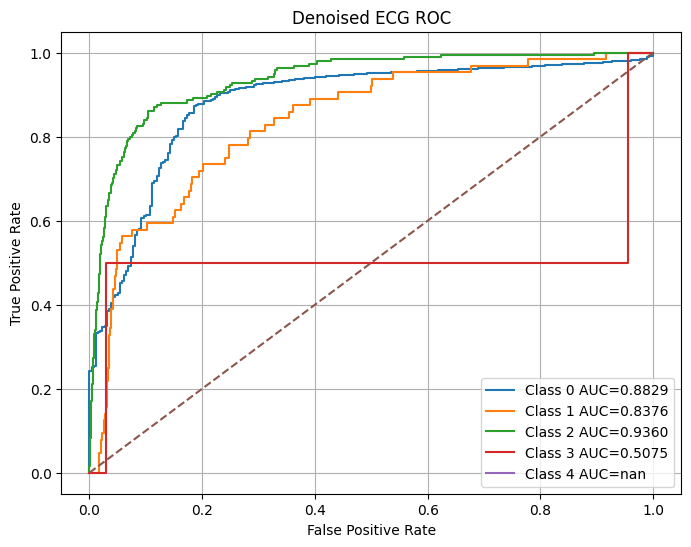

In [167]:
results_denoised = evaluate_model(classifier_denoised,test_loader_denoised)
auc_denoised = plot_multiclass_roc(results_denoised['labels'],results_denoised['probs'],title='Denoised ECG ROC')

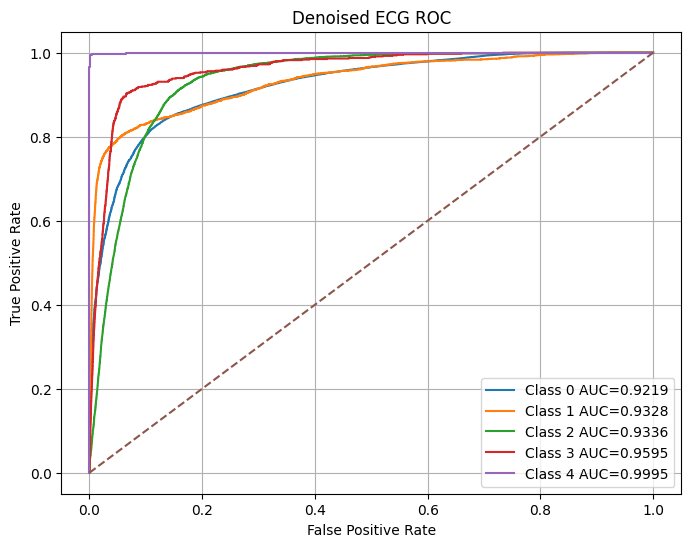

In [156]:
results_train_denoised = evaluate_model(classifier_denoised,train_loader_denoised)
auc_train_denoised = plot_multiclass_roc(results_train_denoised['labels'],results_train_denoised['probs'],title='Denoised ECG ROC')


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


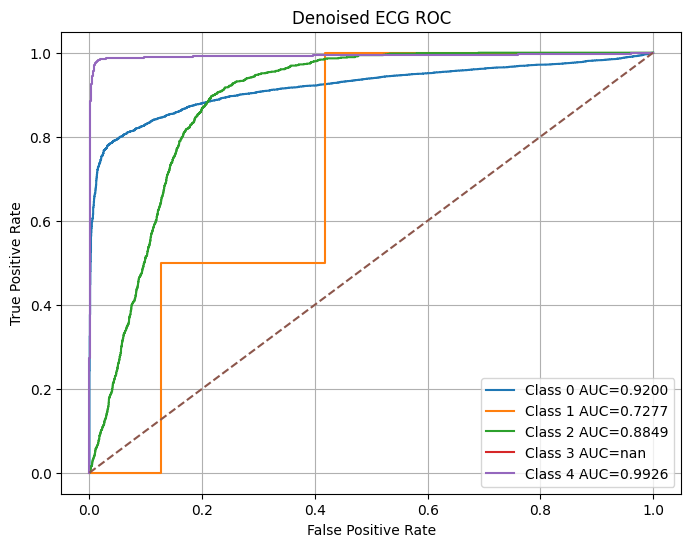

In [155]:
results_valid_denoised = evaluate_model(classifier_denoised,valid_loader_denoised)
auc_valid_denoised = plot_multiclass_roc(results_valid_denoised['labels'],results_valid_denoised['probs'],title='Denoised ECG ROC')


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


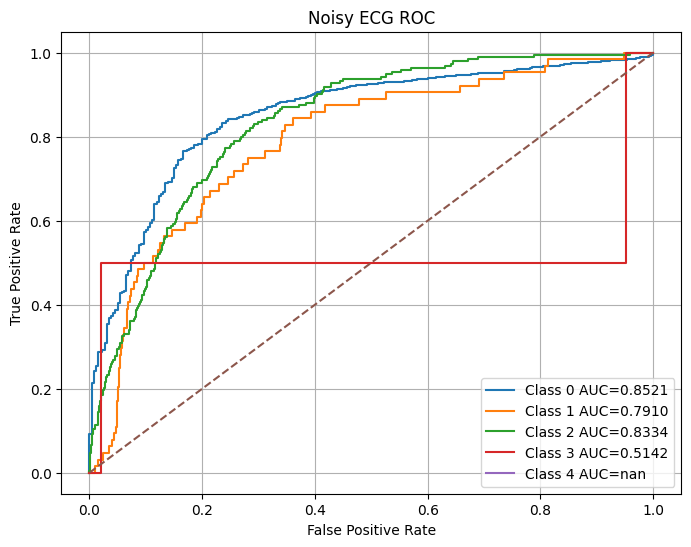

In [168]:
results_noisy = evaluate_model(classifier_noisy,test_loader_noisy)
auc_noisy = plot_multiclass_roc(results_noisy['labels'],results_noisy['probs'],title='Noisy ECG ROC')

In [169]:
comparison_df = pd.DataFrame({

    'Metric': [

        'Accuracy',
        'Precision',
        'Sensitivity',
        'F1-score',
        'Mean AUC'

    ],

    'Noisy ECG': [

        results_noisy['accuracy'],
        results_noisy['precision'],
        results_noisy['sensitivity'],
        results_noisy['f1_score'],
        np.mean(results_noisy['auc_per_class'])

    ],

    'Denoised ECG': [

        results_denoised['accuracy'],
        results_denoised['precision'],
        results_denoised['sensitivity'],
        results_denoised['f1_score'],
        np.mean(results_denoised['auc_per_class'])

    ]

})

In [170]:
comparison_df = comparison_df.round(4)
print(comparison_df)

        Metric  Noisy ECG  Denoised ECG
0     Accuracy     0.5524        0.7360
1    Precision     0.2149        0.2291
2  Sensitivity     0.4451        0.4250
3     F1-score     0.1708        0.2216
4     Mean AUC        NaN           NaN


In [171]:
comparison_df.to_csv("classification_comparison.csv",index=False)

In [172]:
class_names = ['N', 'S', 'V', 'F', 'Q']

classwise_df = pd.DataFrame({

    'Class': class_names,

    'F1 Noisy': results_noisy['f1_per_class'],
    'F1 Denoised': results_denoised['f1_per_class'],

    'Sensitivity Noisy': results_noisy['sensitivity_per_class'],
    'Sensitivity Denoised': results_denoised['sensitivity_per_class'],

    'AUC Noisy': results_noisy['auc_per_class'],
    'AUC Denoised': results_denoised['auc_per_class']
})

In [173]:
print(classwise_df.round(4))

  Class  F1 Noisy  F1 Denoised  Sensitivity Noisy  Sensitivity Denoised  \
0     N    0.7110       0.8468             0.5531                0.7367   
1     S    0.0298       0.0455             0.7031                0.6562   
2     V    0.1094       0.2158             0.4691                0.7320   
3     F    0.0040       0.0000             0.5000                0.0000   
4     Q    0.0000       0.0000             0.0000                0.0000   

   AUC Noisy  AUC Denoised  
0     0.8521        0.8829  
1     0.7910        0.8376  
2     0.8334        0.9360  
3     0.5142        0.5075  
4        NaN           NaN  


In [174]:
classwise_df.to_csv("classification_comparison_classwise.csv",index=False)

In [175]:
# =========================================================
# DISCUSS CLASSIFICATION RESULTS
# =========================================================

def discuss_results(
        noisy_results,
        denoised_results,
        class_names=['N', 'S', 'V', 'F', 'Q']
):

    print("\n" + "="*70)
    print("DOWNSTREAM ECG CLASSIFICATION ANALYSIS")
    print("="*70)

    # =====================================================
    # OVERALL PERFORMANCE
    # =====================================================

    print("\n[1] OVERALL PERFORMANCE")
    print("-"*70)

    print(f"Accuracy (Noisy ECG)    : {noisy_results['accuracy']:.4f}")
    print(f"Accuracy (Denoised ECG) : {denoised_results['accuracy']:.4f}")

    accuracy_diff = (
        denoised_results['accuracy']
        - noisy_results['accuracy']
    )

    print(f"Accuracy Improvement    : {accuracy_diff:.4f}")

    if accuracy_diff > 0:
        print(
            "\nDenoised ECG improved overall "
            "classification performance."
        )

    else:
        print(
            "\nDenoising did not improve "
            "overall classification performance."
        )

    # =====================================================
    # F1 SCORE COMPARISON
    # =====================================================

    print("\n[2] F1-SCORE COMPARISON")
    print("-"*70)

    for idx, cls in enumerate(class_names):

        noisy_f1 = noisy_results['f1_per_class'][idx]
        denoised_f1 = denoised_results['f1_per_class'][idx]

        diff = denoised_f1 - noisy_f1

        print(
            f"Class {cls} | "
            f"Noisy: {noisy_f1:.4f} | "
            f"Denoised: {denoised_f1:.4f} | "
            f"Improvement: {diff:+.4f}"
        )

    # =====================================================
    # MEDICALLY IMPORTANT CLASSES
    # =====================================================

    print("\n[3] MEDICALLY IMPORTANT ARRHYTHMIA CLASSES")
    print("-"*70)

    important_classes = ['S', 'V', 'F']

    for cls in important_classes:

        idx = class_names.index(cls)

        noisy_sens = noisy_results['sensitivity_per_class'][idx]
        denoised_sens = denoised_results['sensitivity_per_class'][idx]

        diff = denoised_sens - noisy_sens

        print(
            f"\nClass {cls}"
        )

        print(
            f"Sensitivity (Noisy)    : {noisy_sens:.4f}"
        )

        print(
            f"Sensitivity (Denoised) : {denoised_sens:.4f}"
        )

        print(
            f"Improvement             : {diff:+.4f}"
        )

        # -------------------------------------------------
        # Medical Interpretation
        # -------------------------------------------------

        if diff > 0:

            print(
                "Interpretation: "
                "Denoising reduced missed arrhythmia detections."
            )

        else:

            print(
                "Interpretation: "
                "Denoising did not improve detection sensitivity."
            )

    # =====================================================
    # ROC AUC ANALYSIS
    # =====================================================

    print("\n[4] ROC / AUC ANALYSIS")
    print("-"*70)

    for idx, cls in enumerate(class_names):

        noisy_auc = noisy_results['auc_per_class'][idx]
        denoised_auc = denoised_results['auc_per_class'][idx]

        diff = denoised_auc - noisy_auc

        print(
            f"Class {cls} | "
            f"Noisy AUC: {noisy_auc:.4f} | "
            f"Denoised AUC: {denoised_auc:.4f} | "
            f"Improvement: {diff:+.4f}"
        )

    # =====================================================
    # CONFUSION MATRIX ANALYSIS
    # =====================================================

    print("\n[5] CONFUSION MATRIX ANALYSIS")
    print("-"*70)

    noisy_cm = noisy_results['confusion_matrix']
    denoised_cm = denoised_results['confusion_matrix']

    for idx, cls in enumerate(class_names):

        noisy_correct = noisy_cm[idx, idx]
        denoised_correct = denoised_cm[idx, idx]

        diff = denoised_correct - noisy_correct

        print(
            f"Class {cls} Correct Predictions | "
            f"Noisy: {noisy_correct} | "
            f"Denoised: {denoised_correct} | "
            f"Difference: {diff:+}"
        )

    # =====================================================
    # FINAL CONCLUSION
    # =====================================================

    print("\n[6] FINAL CONCLUSION")
    print("-"*70)

    if accuracy_diff > 0:

        print(
            "The denoising autoencoder improved "
            "downstream ECG classification performance."
        )

        print(
            "This indicates that removing noise "
            "helped the classifier learn more "
            "discriminative cardiac features."
        )

    else:

        print(
            "The denoising stage did not improve "
            "classification performance."
        )

    print(
        "\nSpecial attention should be given "
        "to sensitivity improvements in "
        "S, V, and F arrhythmia classes, "
        "because missing abnormal beats "
        "is clinically dangerous."
    )

    print("="*70)

In [176]:
discuss_results(results_noisy, results_denoised)


DOWNSTREAM ECG CLASSIFICATION ANALYSIS

[1] OVERALL PERFORMANCE
----------------------------------------------------------------------
Accuracy (Noisy ECG)    : 0.5524
Accuracy (Denoised ECG) : 0.7360
Accuracy Improvement    : 0.1836

Denoised ECG improved overall classification performance.

[2] F1-SCORE COMPARISON
----------------------------------------------------------------------
Class N | Noisy: 0.7110 | Denoised: 0.8468 | Improvement: +0.1357
Class S | Noisy: 0.0298 | Denoised: 0.0455 | Improvement: +0.0157
Class V | Noisy: 0.1094 | Denoised: 0.2158 | Improvement: +0.1064
Class F | Noisy: 0.0040 | Denoised: 0.0000 | Improvement: -0.0040
Class Q | Noisy: 0.0000 | Denoised: 0.0000 | Improvement: +0.0000

[3] MEDICALLY IMPORTANT ARRHYTHMIA CLASSES
----------------------------------------------------------------------

Class S
Sensitivity (Noisy)    : 0.7031
Sensitivity (Denoised) : 0.6562
Improvement             : -0.0469
Interpretation: Denoising did not improve detection sensit

555

### Block Diagram of CAE

In [98]:
!pip install torchview graphviz
!pip install torchviz

In [101]:
model = models_to_test['ResStackCAE']

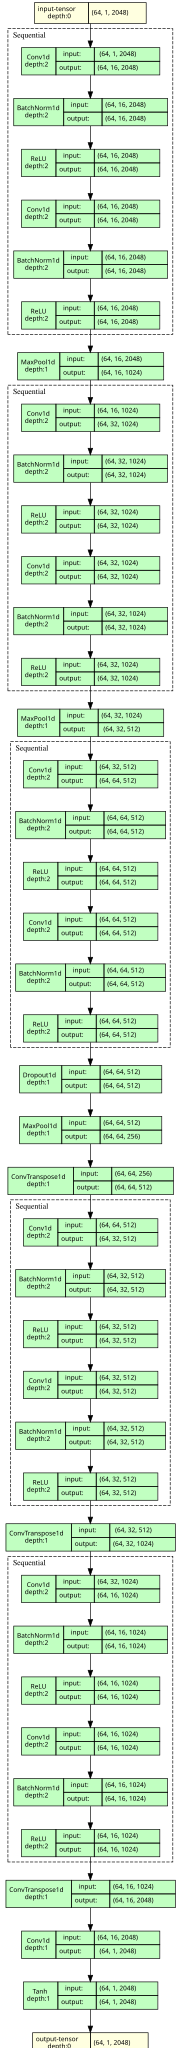

In [ ]:
# from torchview import draw_graph
# import torch

# os.makedirs(VISUALS_DIR, exist_ok=True) # Creates the directory if it doesn't exist

# # model = models_to_test['ResStackCAE']

# # (Batch size, Channels, Width)
# dummy_input = torch.randn(64, 1, 2048)

# # Generate the diagram
# model_graph = draw_graph(
#     model,
#     input_size=dummy_input.shape,
#     expand_nested=True,     # Shows details inside Sequential blocks
#     graph_name='DropOutStackCAE',
#     directory='visuals',    # Saves to a folder named 'visuals'
#     save_graph=True
# )

# model_graph.visual_graph

In [ ]:
# # Render and save the graph as a PNG
# model_graph.visual_graph.render(
#     filename='DropOutStackCAE',
#     directory='visuals',
#     format='png'
# )

'visuals/DropOutStackCAE.png'

In [102]:
from torchview import draw_graph
import torch

os.makedirs(VISUALS_DIR, exist_ok=True) # Creates the directory if it doesn't exist

# model = models_to_test['ResStackCAE']

# (Batch size, Channels, Width)
dummy_input = torch.randn(64, 1, 2048)

# 1. Generate the initial graph
model_graph = draw_graph(model, input_size=dummy_input.shape, expand_nested=True)
gv_graph = model_graph.visual_graph

# 2. Define your color map (Target Layer Name -> Hex Color)
# Note: torchview uses 'fillcolor' for the block interior
color_map = {
    # 'Sequential': '#E5E7E9',      # Light Grey (Container)
    'Sequential': '#000000',
    'encoder': '#E5E7E9',
    'decoder': '#E5E7E9',
    'Conv1d': '#FFCCCC',   # Light Red
    'ConvTranspose1d': '#AED6F1', # Pastel Pink
    'MaxPool1d': '#F0B27A',       # Soft Orange   #CCE5FF',   # Light Blue
    'ReLU': '#D5F5E3',     # Pale Green
    'Dropout': '#EBDEF0',  # Soft Purple
    'Tanh': '#CCE5FF',     # Lavender
    'Input': '#AED6F1',           # Light Blue
    'Output': '#ABEBC6',          # Light Green
    'BatchNorm': '#FCF3CF' # Light Yellow
}
# 3. Apply colors to the Graphviz body
new_body = []
for line in gv_graph.body:
    # Check if the line defines a node and contains one of our keywords
    for layer_type, color in color_map.items():
        if layer_type in line:
            # Inject Graphviz styling into the node definition string
            line = line.replace(']', f' fillcolor="{color}" style=filled]')
            break
    new_body.append(line)

gv_graph.body = new_body

# 4. Save the customized version
gv_graph.render(filename='Colored_ResStackCAE', directory='visuals', format='png')


'visuals/Colored_ResStackCAE.png'

In [ ]:
# Using Torchviz (Standard Computational Graph)
from torchviz import make_dot

# model = models_to_test['ResStackCAE']
x = torch.randn(64, 1, 2048)
y = model(x)

# Generates a DOT graph of the forward pass
make_dot(y, params=dict(model.named_parameters())).render("DropOutStackCAEE_GRAPH", format="png")


'DropOutStackCAEE_GRAPH.png'

In [ ]:
from torchviz import make_dot

# To see how the forward and backward passes are linked, use Torchviz.
# It renders the graph of tensors and their grad_fn (gradient functions),
# which PyTorch uses to execute backpropagation.

# 1. Forward Pass
# model = models_to_test['ResStackCAE']
x = torch.randn(64, 1, 2048)
output = model(x)
loss = criterion(output, x)

# 2. Visualize the graph leading to the loss
# This shows all operations (Conv, ReLU, etc.) that will receive gradients
make_dot(loss, params=dict(model.named_parameters())).render("backprop_graph", format="png")


'backprop_graph.png'

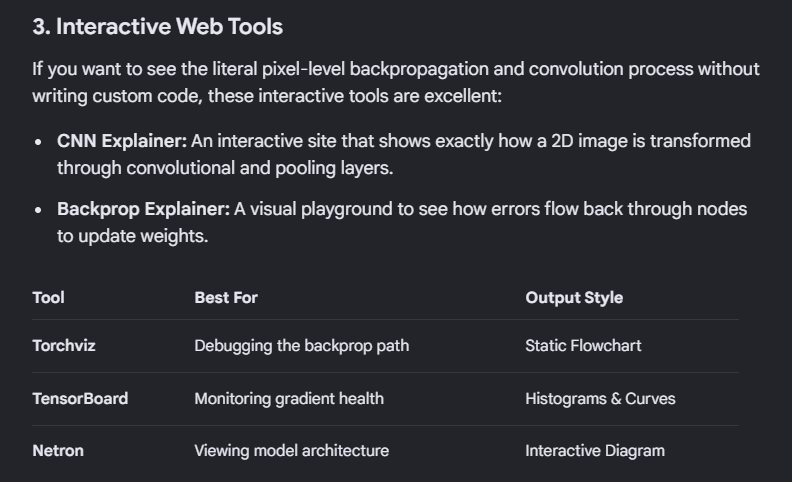